# Credit Scoring Model Development Notebook

## Overview
This comprehensive notebook provides a complete framework for developing credit scoring models. It's designed to be user-friendly for new analysts while maintaining efficiency and best practices.

### Key Features:
1. **Efficient Data Processing**: Uses Polars for fast data manipulation
2. **Automated Diagnostics**: Comprehensive data profiling and quality checks
3. **Interactive Analysis**: Feature selection and bivariate analysis tools
4. **Advanced Modeling**: Logistic Regression and XGBoost implementations
5. **Performance Evaluation**: ROC curves, gains tables, and credit-specific metrics
6. **Score Creation**: PDO methodology for 3-digit credit scores

### Prerequisites:
- Basic understanding of credit risk concepts
- Familiarity with Python and Jupyter notebooks
- Dataset with features and a binary target variable

---

## 0. Install Required Packages

Before running this notebook, ensure all required packages are installed. Run the cell below to install the necessary dependencies.

In [17]:
# Install required packages
# Uncomment and run this cell if packages are not already installed

import subprocess
import sys

def install_package(package):
    """Install a package using pip."""
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"✅ Successfully installed {package}")
    except subprocess.CalledProcessError:
        print(f"❌ Failed to install {package}")

# Core packages
packages_to_install = [
    "polars>=0.20.0",           # Efficient dataframe library
    "scikit-learn>=1.3.0",     # Machine learning library
    "xgboost>=2.0.0",           # Gradient boosting framework
    "matplotlib>=3.7.0",       # Plotting library
    "seaborn>=0.12.0",          # Statistical visualization
    "plotly>=5.15.0",           # Interactive plotting
    "numpy>=1.24.0",            # Numerical computing
    "scipy>=1.10.0",            # Scientific computing
    "ipywidgets>=8.0.0",        # Jupyter widgets for interactivity
]

# Optional packages for advanced features
optional_packages = [
    "imbalanced-learn>=0.11.0", # For handling class imbalance
    "shap>=0.43.0",             # For model explainability
    "optuna>=3.3.0",            # For hyperparameter optimization
]

print("🔧 Installing required packages...")
print("=" * 50)

# Install core packages
for package in packages_to_install:
    install_package(package)

print("\n🔧 Installing optional packages...")
print("=" * 50)

# Install optional packages (continue on failure)
for package in optional_packages:
    install_package(package)

print("\n✅ Package installation completed!")
print("\n💡 If any installation failed, you can install manually using:")
print("   pip install package_name")
print("\n🔄 After installation, restart the kernel to use the new packages.")

🔧 Installing required packages...
✅ Successfully installed polars>=0.20.0
✅ Successfully installed scikit-learn>=1.3.0
✅ Successfully installed xgboost>=2.0.0
✅ Successfully installed matplotlib>=3.7.0
✅ Successfully installed seaborn>=0.12.0
✅ Successfully installed plotly>=5.15.0
✅ Successfully installed numpy>=1.24.0
✅ Successfully installed scipy>=1.10.0
✅ Successfully installed ipywidgets>=8.0.0

🔧 Installing optional packages...
✅ Successfully installed imbalanced-learn>=0.11.0
✅ Successfully installed shap>=0.43.0
✅ Successfully installed optuna>=3.3.0

✅ Package installation completed!

💡 If any installation failed, you can install manually using:
   pip install package_name

🔄 After installation, restart the kernel to use the new packages.


### Alternative Installation Methods

If the above installation doesn't work, you can try these alternative methods:

#### Using pip directly in terminal/command prompt:
```bash
pip install polars scikit-learn xgboost matplotlib seaborn plotly numpy scipy ipywidgets
pip install imbalanced-learn shap optuna  # Optional packages
```

#### Using conda:
```bash
conda install -c conda-forge polars scikit-learn xgboost matplotlib seaborn plotly numpy scipy ipywidgets
conda install -c conda-forge imbalanced-learn shap optuna  # Optional packages
```
---

## 1. Import Required Libraries

First, we'll import all the necessary libraries for our credit scoring analysis.

In [1]:
# Core data processing and analysis
import polars as pl
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Machine learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix, 
                           classification_report, precision_recall_curve)
import xgboost as xgb

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistical analysis
from scipy import stats
from scipy.stats import chi2_contingency, ks_2samp

# Interactive widgets for Jupyter
try:
    from ipywidgets import interact, widgets, interactive
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False
    print("Warning: ipywidgets not available. Some interactive features will be limited.")

# Utility libraries
import json
import pickle
from datetime import datetime
import os

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")
print(f"Polars version: {pl.__version__}")
print(f"XGBoost version: {xgb.__version__}")
print(f"Widgets available: {WIDGETS_AVAILABLE}")

✅ All libraries imported successfully!
Polars version: 1.31.0
XGBoost version: 3.0.2
Widgets available: True


## 2. Analysis Settings and Configuration

Configure all key parameters and thresholds used throughout the analysis. Modify these settings to customize the analysis according to your specific requirements.

In [2]:
# =============================================================================
# CREDIT SCORING MODEL ANALYSIS SETTINGS
# =============================================================================
"""
Comprehensive configuration settings for the credit scoring model development.
Modify these parameters to customize the analysis according to your requirements.
"""

# =============================================================================
# 🎯 GENERAL ANALYSIS SETTINGS
# =============================================================================
ANALYSIS_SETTINGS = {
    # Random seed for reproducibility
    'random_state': 42,
    
    # Data split ratios
    'test_size': 0.3,           # Proportion for test set (0.3 = 30%)
    'validation_size': 0.2,     # Proportion of training set for validation
    
    # Cross-validation settings
    'cv_folds': 5,              # Number of folds for cross-validation
    
    # Display settings
    'max_display_rows': 1000,   # Maximum rows to display in outputs
    'plot_figure_size': (12, 8), # Default figure size for plots
    'plot_dpi': 100,            # Plot resolution
}

# =============================================================================
# 📊 DATA QUALITY AND DIAGNOSTICS THRESHOLDS
# =============================================================================
DATA_QUALITY_SETTINGS = {
    # Missing data thresholds
    'max_missing_rate': 0.50,          # Max missing rate to keep column (50%)
    'missing_threshold_warning': 0.10,  # Warning threshold for missing data (10%)
    
    # Data type detection
    'numeric_unique_threshold': 50,     # Min unique values to consider numeric
    'categorical_max_categories': 100,   # Max categories for categorical variables
    
    # Outlier detection
    'outlier_method': 'iqr',           # 'iqr', 'zscore', or 'isolation_forest'
    'outlier_threshold': 1.5,          # IQR multiplier for outlier detection
    'zscore_threshold': 3.0,           # Z-score threshold for outliers
    
    # Data distribution analysis
    'min_samples_per_bin': 30,         # Minimum samples per bin for analysis
    'max_bins_numeric': 20,            # Maximum bins for numeric variables
}

# =============================================================================
# 🔍 FEATURE SELECTION AND ANALYSIS SETTINGS
# =============================================================================
FEATURE_ANALYSIS_SETTINGS = {
    # Information Value (IV) thresholds
    'iv_thresholds': {
        'excellent': 0.50,      # IV > 0.50: Excellent predictive power
        'strong': 0.30,         # IV 0.30-0.50: Strong predictive power
        'medium': 0.10,         # IV 0.10-0.30: Medium predictive power
        'weak': 0.02,           # IV 0.02-0.10: Weak predictive power
        'minimum': 0.02         # IV < 0.02: No predictive power (exclude)
    },
    
    # Feature selection criteria
    'min_iv_threshold': 0.01,          # Minimum IV to include feature
    'max_features_to_select': 40,      # Maximum number of features to select
    'correlation_threshold': 0.80,      # Max correlation between features
    
    # Bivariate analysis settings
    'bivariate_bins': 10,              # Default number of bins for numeric variables
    'min_bin_size': 30,                # Minimum samples per bin
    'statistical_significance': 0.05,   # P-value threshold for statistical tests
    
    # Feature importance settings
    'importance_method': 'both',        # 'iv', 'correlation', or 'both'
    'top_features_display': 15,        # Number of top features to display
}

# =============================================================================
# 🔧 FEATURE TRANSFORMATION SETTINGS
# =============================================================================
TRANSFORMATION_SETTINGS = {
    # Binning methods
    'default_binning_method': 'equal_frequency',  # 'equal_width', 'equal_frequency', 'optimal'
    'default_bins': 10,                          # Default number of bins
    'min_bin_frequency': 0.05,                   # Minimum frequency per bin (5%)
    
    # Scaling methods
    'default_scaling_method': 'standard',        # 'standard', 'minmax', 'robust'
    
    # Encoding methods
    'categorical_encoding': 'woe',               # 'onehot', 'label', 'woe', 'target'
    'handle_unknown_categories': 'ignore',       # 'error', 'ignore', 'infrequent'
    
    # Missing value handling
    'missing_value_strategy': 'median',          # 'mean', 'median', 'mode', 'constant'
    'missing_value_indicator': True,             # Add missing value indicator columns
}

# =============================================================================
# 🤖 MODEL TRAINING SETTINGS
# =============================================================================
MODEL_SETTINGS = {
    # Logistic Regression settings
    'logistic_regression': {
        'solver': 'liblinear',      # 'liblinear', 'lbfgs', 'saga'
        'max_iter': 1000,           # Maximum iterations
        'C': 1.0,                   # Regularization strength (smaller = more regularization)
        'penalty': 'l2',            # Regularization type ('l1', 'l2', 'elasticnet')
        'class_weight': 'balanced', # Handle class imbalance
    },
    
    # XGBoost settings
    'xgboost': {
        'objective': 'binary:logistic',  # Objective function
        'eval_metric': 'auc',           # Evaluation metric
        'max_depth': 6,                 # Maximum tree depth
        'learning_rate': 0.1,           # Learning rate (eta)
        'n_estimators': 100,            # Number of boosting rounds
        'subsample': 0.8,               # Row sampling rate
        'colsample_bytree': 0.8,        # Column sampling rate
        'random_state': 42,             # Random seed
        'verbosity': 0,                 # Control verbosity
    },
    
    # Hyperparameter tuning settings
    'hyperparameter_tuning': {
        'method': 'random_search',      # 'grid_search', 'random_search', 'optuna'
        'n_trials': 100,                # Number of trials for random search/optuna
        'cv_folds': 3,                  # Cross-validation folds for tuning
        'scoring': 'roc_auc',           # Scoring metric for optimization
        'n_jobs': -1,                   # Parallel jobs (-1 for all cores)
    }
}

# =============================================================================
# 📈 MODEL EVALUATION SETTINGS
# =============================================================================
EVALUATION_SETTINGS = {
    # Performance thresholds
    'min_acceptable_auc': 0.70,         # Minimum acceptable AUC score
    'excellent_auc': 0.85,              # Threshold for excellent model
    'gini_threshold': 0.40,             # Minimum Gini coefficient
    
    # Probability thresholds
    'default_threshold': 0.5,           # Default classification threshold
    'optimal_threshold_method': 'youden',  # 'youden', 'closest_to_corner', 'f1'
    
    # Gains table settings
    'gains_table_deciles': 10,          # Number of deciles for gains table
    'lift_threshold': 1.5,              # Minimum lift for top decile
    
    # Stability testing
    'stability_bins': 10,               # Bins for PSI calculation
    'psi_threshold': 0.2,               # PSI threshold for stability warning
    'max_score_drift': 50,              # Maximum acceptable score drift
}

# =============================================================================
# 💳 CREDIT SCORECARD SETTINGS
# =============================================================================
SCORECARD_SETTINGS = {
    # PDO (Points to Double the Odds) methodology
    'pdo': 20,                          # Points to double the odds
    'base_score': 600,                  # Score at base odds
    'base_odds': 50,                    # Base odds (1:50 = 2% default rate)
    
    # Score range settings
    'min_score': 300,                   # Minimum possible score
    'max_score': 850,                   # Maximum possible score
    'score_precision': 0,               # Decimal places for scores (0 for integers)
    
    # Score distribution analysis
    'score_bins': 20,                   # Bins for score distribution analysis
    'target_score_range': (580, 720),   # Target score range for good customers
    
    # Business rules
    'auto_decline_threshold': 400,       # Auto-decline score threshold
    'manual_review_threshold': 550,      # Manual review score threshold
    'auto_approve_threshold': 700,       # Auto-approve score threshold
}

# =============================================================================
# 📁 FILE AND OUTPUT SETTINGS
# =============================================================================
OUTPUT_SETTINGS = {
    # File paths and naming
    'output_directory': 'credit_scoring_outputs',  # Directory for outputs
    'model_filename_prefix': 'credit_model',       # Prefix for saved models
    'timestamp_format': '%Y%m%d_%H%M%S',          # Timestamp format for files
    
    # Export settings
    'save_model': True,                 # Save trained models
    'save_scaler': True,                # Save feature scalers
    'save_scorecard': True,             # Save scorecard parameters
    'export_format': 'pickle',          # 'pickle', 'joblib', or 'json'
    
    # Reporting settings
    'generate_html_report': True,       # Generate HTML model report
    'include_feature_importance': True,  # Include feature importance plots
    'include_model_diagnostics': True,  # Include diagnostic plots
}

# =============================================================================
# 🔧 TECHNICAL SETTINGS
# =============================================================================
TECHNICAL_SETTINGS = {
    # Memory and performance
    'chunk_size': 10000,               # Chunk size for large dataset processing
    'memory_efficient_mode': False,    # Use memory-efficient processing
    'parallel_processing': True,       # Enable parallel processing where possible
    'n_cores': -1,                     # Number of cores to use (-1 for all)
    
    # Logging and debugging
    'verbose_level': 1,                # Verbosity level (0=silent, 1=normal, 2=detailed)
    'log_progress': True,              # Log progress for long operations
    'debug_mode': False,               # Enable debug output
    
    # Numerical precision
    'float_precision': 'float32',      # Float precision ('float32' or 'float64')
    'convergence_tolerance': 1e-6,     # Convergence tolerance for iterative algorithms
}

# =============================================================================
# ✅ SETTINGS VALIDATION AND SUMMARY
# =============================================================================

def validate_settings():
    """Validate settings for consistency and logical constraints."""
    issues = []
    
    # Validate probability ranges
    if not (0 < ANALYSIS_SETTINGS['test_size'] < 1):
        issues.append("test_size must be between 0 and 1")
    
    if not (0 < DATA_QUALITY_SETTINGS['max_missing_rate'] <= 1):
        issues.append("max_missing_rate must be between 0 and 1")
    
    # Validate IV thresholds
    iv_thresholds = FEATURE_ANALYSIS_SETTINGS['iv_thresholds']
    if not (iv_thresholds['minimum'] < iv_thresholds['weak'] < 
            iv_thresholds['medium'] < iv_thresholds['strong'] < 
            iv_thresholds['excellent']):
        issues.append("IV thresholds must be in ascending order")
    
    # Validate scorecard settings
    if SCORECARD_SETTINGS['min_score'] >= SCORECARD_SETTINGS['max_score']:
        issues.append("min_score must be less than max_score")
    
    if SCORECARD_SETTINGS['pdo'] <= 0:
        issues.append("PDO must be positive")
    
    # Validate model settings
    if MODEL_SETTINGS['xgboost']['max_depth'] <= 0:
        issues.append("XGBoost max_depth must be positive")
    
    if not (0 < MODEL_SETTINGS['xgboost']['learning_rate'] <= 1):
        issues.append("XGBoost learning_rate must be between 0 and 1")
    
    return issues

def print_settings_summary():
    """Print a summary of key settings."""
    print("🔧 CREDIT SCORING MODEL SETTINGS SUMMARY")
    print("=" * 60)
    
    print(f"📊 Data Split: {ANALYSIS_SETTINGS['test_size']*100:.0f}% test, "
          f"{(1-ANALYSIS_SETTINGS['test_size'])*100:.0f}% train")
    print(f"🎯 Cross-validation: {ANALYSIS_SETTINGS['cv_folds']} folds")
    print(f"📉 Minimum IV threshold: {FEATURE_ANALYSIS_SETTINGS['min_iv_threshold']}")
    print(f"🔢 Maximum features: {FEATURE_ANALYSIS_SETTINGS['max_features_to_select']}")
    print(f"📏 Binning method: {TRANSFORMATION_SETTINGS['default_binning_method']}")
    print(f"🤖 Models: Logistic Regression + XGBoost")
    print(f"💳 Score range: {SCORECARD_SETTINGS['min_score']}-{SCORECARD_SETTINGS['max_score']} "
          f"(PDO: {SCORECARD_SETTINGS['pdo']})")
    
    # Validate settings
    validation_issues = validate_settings()
    if validation_issues:
        print(f"\n⚠️  SETTINGS VALIDATION ISSUES:")
        for issue in validation_issues:
            print(f"   • {issue}")
    else:
        print(f"\n✅ All settings validated successfully!")

# Display settings summary
print_settings_summary()

# Store all settings in a single dictionary for easy access
ALL_SETTINGS = {
    'analysis': ANALYSIS_SETTINGS,
    'data_quality': DATA_QUALITY_SETTINGS,
    'feature_analysis': FEATURE_ANALYSIS_SETTINGS,
    'transformation': TRANSFORMATION_SETTINGS,
    'model': MODEL_SETTINGS,
    'evaluation': EVALUATION_SETTINGS,
    'scorecard': SCORECARD_SETTINGS,
    'output': OUTPUT_SETTINGS,
    'technical': TECHNICAL_SETTINGS
}

print(f"\n📝 Settings configuration completed!")
print(f"💡 You can modify any settings above and re-run this cell to update the configuration.")
print(f"🔄 The settings will be used throughout the analysis automatically.")

🔧 CREDIT SCORING MODEL SETTINGS SUMMARY
📊 Data Split: 30% test, 70% train
🎯 Cross-validation: 5 folds
📉 Minimum IV threshold: 0.01
🔢 Maximum features: 40
📏 Binning method: equal_frequency
🤖 Models: Logistic Regression + XGBoost
💳 Score range: 300-850 (PDO: 20)

⚠️  SETTINGS VALIDATION ISSUES:
   • IV thresholds must be in ascending order

📝 Settings configuration completed!
💡 You can modify any settings above and re-run this cell to update the configuration.
🔄 The settings will be used throughout the analysis automatically.


### How Settings Are Used Throughout the Notebook

The settings defined above are automatically used in key functions throughout the notebook:

**🎯 Analysis Settings:**
- `test_size`, `cv_folds`, `random_state` → Used in data splitting and cross-validation
- `max_display_rows` → Controls output display limits

**📊 Data Quality Settings:**
- `max_missing_rate` → Filters columns with excessive missing data
- `outlier_threshold` → IQR multiplier for outlier detection

**🔍 Feature Analysis Settings:**
- `min_iv_threshold` → Minimum Information Value for feature inclusion
- `bivariate_bins` → Number of bins for continuous variables in bivariate analysis
- `correlation_threshold` → Maximum correlation between features to avoid multicollinearity

**🔧 Transformation Settings:**
- `default_binning_method` → Binning approach for continuous variables
- `categorical_encoding` → Encoding method for categorical variables

**🤖 Model Settings:**
- `logistic_regression` & `xgboost` → Model hyperparameters
- `hyperparameter_tuning` → Controls automated tuning process

**💳 Scorecard Settings:**
- `pdo`, `base_score`, `base_odds` → PDO methodology parameters
- Score range and business rules

**Key functions automatically use these settings:**
- `analyze_bivariate_relationship()` uses `bivariate_bins`
- `calculate_woe_iv()` uses `bivariate_bins` and `min_iv_threshold` 
- `train_logistic_regression()` uses `logistic_regression` parameters
- `train_xgboost_model()` uses `xgboost` parameters
- `create_scorecard()` uses `scorecard` parameters

💡 **To customize the analysis:** Simply modify the settings above and re-run this cell!

In [3]:
# Configuration parameters - Updated to use comprehensive settings
CONFIG = {
    'random_state': ALL_SETTINGS['analysis']['random_state'],
    'test_size': ALL_SETTINGS['analysis']['test_size'],
    'cv_folds': ALL_SETTINGS['analysis']['cv_folds'],
    'max_display_rows': ALL_SETTINGS['analysis']['max_display_rows'],
    'pdo': ALL_SETTINGS['scorecard']['pdo'],
    'base_score': ALL_SETTINGS['scorecard']['base_score'],
    'base_odds': ALL_SETTINGS['scorecard']['base_odds']
}

def load_data(file_path, file_type='csv', **kwargs):
    """
    Load data using Polars with automatic type inference and error handling.
    
    Parameters:
    -----------
    file_path : str
        Path to the data file
    file_type : str
        Type of file ('csv', 'parquet', 'excel')
    **kwargs : dict
        Additional parameters for the Polars read function
    
    Returns:
    --------
    pl.DataFrame
        Loaded data as Polars DataFrame
    """
    try:
        file_path = Path(file_path)
        
        if not file_path.exists():
            raise FileNotFoundError(f"File not found: {file_path}")
        
        if file_type.lower() == 'csv':
            df = pl.read_csv(file_path, **kwargs)
        elif file_type.lower() == 'parquet':
            df = pl.read_parquet(file_path, **kwargs)
        elif file_type.lower() in ['excel', 'xlsx', 'xls']:
            df = pl.read_excel(file_path, **kwargs)
        else:
            raise ValueError(f"Unsupported file type: {file_type}")
        
        print(f"✅ Data loaded successfully!")
        print(f"   Shape: {df.shape}")
        print(f"   Memory usage: {df.estimated_size('mb'):.2f} MB")
        
        return df
    
    except Exception as e:
        print(f"❌ Error loading data: {str(e)}")
        return None

def display_data_info(df):
    """Display comprehensive information about the dataset."""
    if df is None:
        print("No data to display.")
        return
    
    print("📊 DATASET OVERVIEW")
    print("=" * 50)
    print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"Memory usage: {df.estimated_size('mb'):.2f} MB")
    print(f"Column types: {dict(df.schema)}")
    
    # Display first few rows
    print("\n🔍 FIRST 5 ROWS")
    print("=" * 50)
    print(df.head())
    
    # Display basic statistics
    print("\n📈 BASIC STATISTICS")
    print("=" * 50)
    numeric_cols = [col for col, dtype in df.schema.items() if dtype in [pl.Int32, pl.Int64, pl.Float32, pl.Float64]]
    if numeric_cols:
        print(df.select(numeric_cols).describe())
    else:
        print("No numeric columns found.")

# Global variable to store our dataset
df_main = None

print("✅ Data import functions ready!")
print("\n📝 To load your data, use:")
print("   df_main = load_data('path/to/your/file.csv')")
print("   display_data_info(df_main)")

✅ Data import functions ready!

📝 To load your data, use:
   df_main = load_data('path/to/your/file.csv')
   display_data_info(df_main)


In [4]:
# 📁 LOAD YOUR DATA HERE
# Uncomment and modify the path below to load your dataset

# df_main = load_data('path/to/your/data.csv')
# display_data_info(df_main)

# Example: Loading a CSV file with custom parameters
# df_main = load_data('credit_data.csv', separator=',', has_header=True)

# Example: Loading an Excel file
# df_main = load_data('credit_data.xlsx', sheet_name='Sheet1')

# For demonstration purposes, create a sample dataset if no data is loaded
if df_main is None:
    print("📋 Creating sample dataset for demonstration...")
    
    # Generate sample credit data
    np.random.seed(CONFIG['random_state'])
    n_samples = 5000
    
    sample_data = {
        'customer_id': range(1, n_samples + 1),
        'age': np.random.normal(35, 12, n_samples).astype(int),
        'income': np.random.lognormal(10, 0.5, n_samples).astype(int),
        'debt_to_income': np.random.beta(2, 5, n_samples),
        'credit_history_length': np.random.exponential(8, n_samples).astype(int),
        'num_credit_accounts': np.random.poisson(3, n_samples),
        'credit_utilization': np.random.beta(2, 3, n_samples),
        'num_late_payments': np.random.poisson(1, n_samples),
        'employment_length': np.random.exponential(5, n_samples).astype(int),
        'loan_amount': np.random.lognormal(9, 0.3, n_samples).astype(int),
    }
    
    # Create target variable with realistic relationships
    risk_score = (
        0.3 * (sample_data['debt_to_income'] > 0.4) +
        0.2 * (sample_data['credit_utilization'] > 0.8) +
        0.2 * (sample_data['num_late_payments'] > 2) +
        0.1 * (sample_data['age'] < 25) +
        0.1 * (sample_data['employment_length'] < 2) +
        0.1 * np.random.random(n_samples)
    )
    
    sample_data['default'] = (risk_score > np.percentile(risk_score, 85)).astype(int)
    
    df_main = pl.DataFrame(sample_data)
    print("✅ Sample dataset created successfully!")
    display_data_info(df_main)

📋 Creating sample dataset for demonstration...
✅ Sample dataset created successfully!
📊 DATASET OVERVIEW
Shape: 5,000 rows × 11 columns
Memory usage: 0.38 MB
Column types: {'customer_id': Int64, 'age': Int64, 'income': Int64, 'debt_to_income': Float64, 'credit_history_length': Int64, 'num_credit_accounts': Int32, 'credit_utilization': Float64, 'num_late_payments': Int32, 'employment_length': Int64, 'loan_amount': Int64, 'default': Int64}

🔍 FIRST 5 ROWS
shape: (5, 11)
┌─────────────┬─────┬────────┬─────────────┬───┬─────────────┬─────────────┬─────────────┬─────────┐
│ customer_id ┆ age ┆ income ┆ debt_to_inc ┆ … ┆ num_late_pa ┆ employment_ ┆ loan_amount ┆ default │
│ ---         ┆ --- ┆ ---    ┆ ome         ┆   ┆ yments      ┆ length      ┆ ---         ┆ ---     │
│ i64         ┆ i64 ┆ i64    ┆ ---         ┆   ┆ ---         ┆ ---         ┆ i64         ┆ i64     │
│             ┆     ┆        ┆ f64         ┆   ┆ i32         ┆ i64         ┆             ┆         │
╞═════════════╪═════╪═

## 3. Column Diagnostics and Data Profiling

Perform comprehensive analysis of each column including data quality checks, statistical summaries, and missing value analysis.

🔍 Running comprehensive column diagnostics...

📊 COLUMN DIAGNOSTICS SUMMARY
shape: (11, 16)
┌───────────┬───────────┬───────────┬───────────┬───┬──────────┬───────────┬───────────┬───────────┐
│ column    ┆ data_type ┆ total_cou ┆ null_coun ┆ … ┆ skewness ┆ outlier_c ┆ outlier_p ┆ data_qual │
│ ---       ┆ ---       ┆ nt        ┆ t         ┆   ┆ ---      ┆ ount      ┆ ercentage ┆ ity       │
│ str       ┆ str       ┆ ---       ┆ ---       ┆   ┆ f64      ┆ ---       ┆ ---       ┆ ---       │
│           ┆           ┆ i64       ┆ i64       ┆   ┆          ┆ i64       ┆ f64       ┆ str       │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪══════════╪═══════════╪═══════════╪═══════════╡
│ customer_ ┆ Int64     ┆ 5000      ┆ 0         ┆ … ┆ 0.0      ┆ 0         ┆ 0.0       ┆ Good      │
│ id        ┆           ┆           ┆           ┆   ┆          ┆           ┆           ┆           │
│ age       ┆ Int64     ┆ 5000      ┆ 0         ┆ … ┆ -0.011   ┆ 66        ┆ 1.32      ┆ Good      │

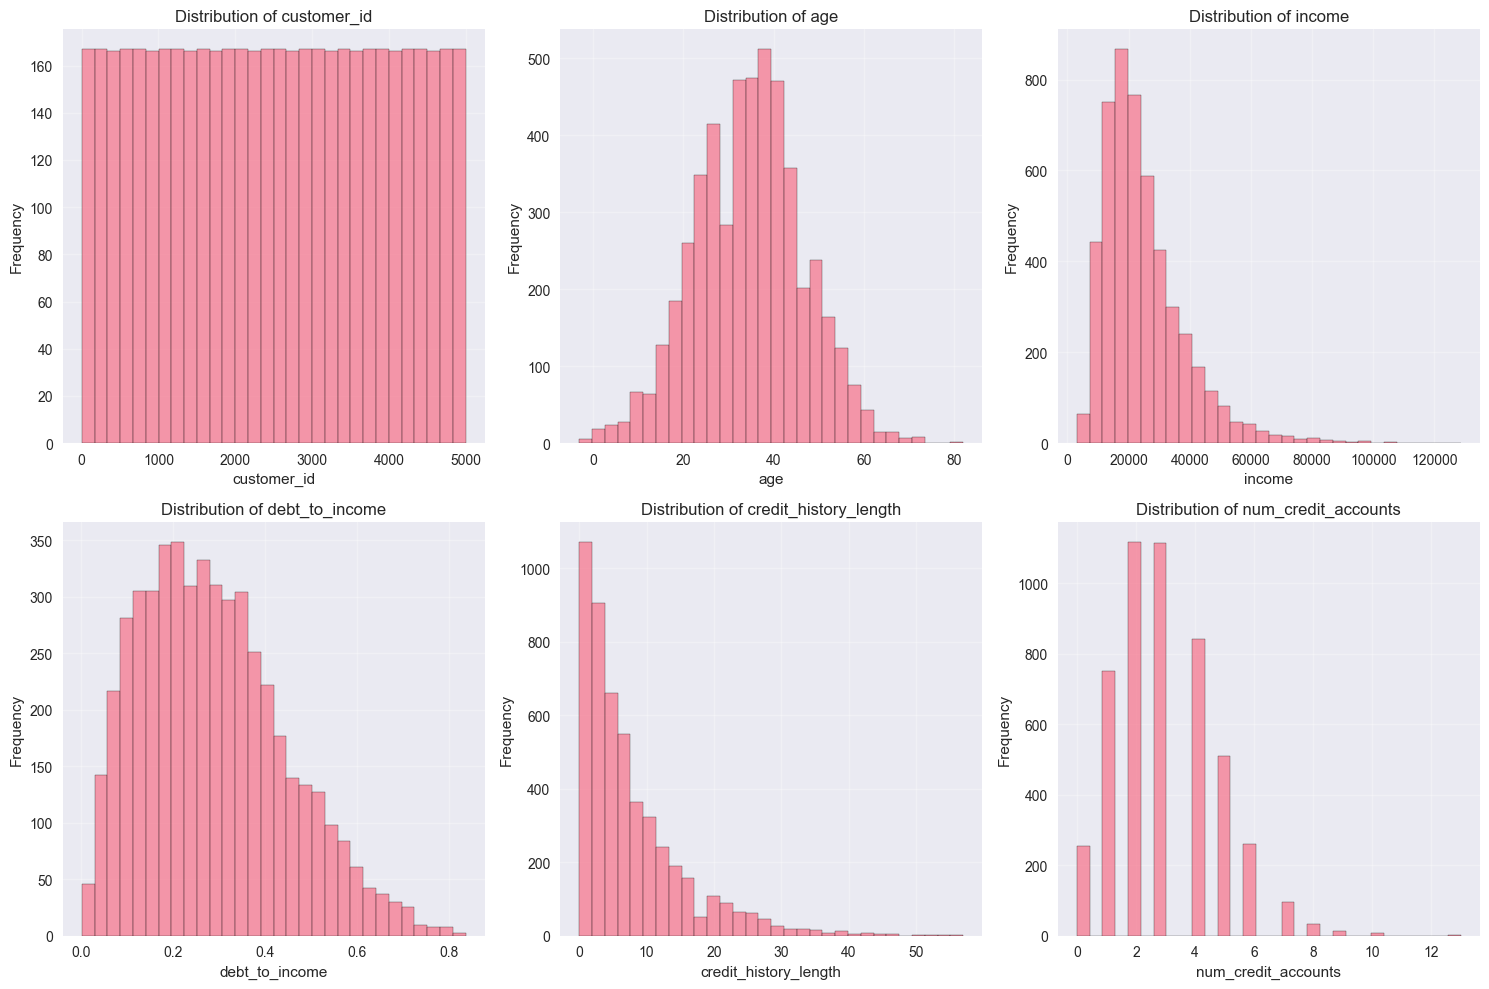

In [5]:
def perform_column_diagnostics(df):
    """
    Perform comprehensive diagnostics on each column.
    
    Parameters:
    -----------
    df : pl.DataFrame
        Input dataframe for analysis
    
    Returns:
    --------
    pl.DataFrame
        Diagnostic summary for each column
    """
    if df is None:
        print("No data available for diagnostics.")
        return None
    
    diagnostics = []
    
    for col in df.columns:
        col_data = df.select(col).to_series()
        
        # Basic information
        dtype = str(df.schema[col])
        total_count = len(col_data)
        null_count = col_data.null_count()
        null_percentage = (null_count / total_count) * 100
        unique_count = col_data.n_unique()
        unique_percentage = (unique_count / total_count) * 100
        
        # Type-specific analysis
        if dtype in ['Int32', 'Int64', 'Float32', 'Float64']:
            # Numeric column analysis
            non_null_data = col_data.drop_nulls()
            if len(non_null_data) > 0:
                mean_val = non_null_data.mean()
                median_val = non_null_data.median()
                std_val = non_null_data.std()
                min_val = non_null_data.min()
                max_val = non_null_data.max()
                skewness = stats.skew(non_null_data.to_numpy()) if len(non_null_data) > 3 else None
                
                # Outlier detection (IQR method)
                q1 = non_null_data.quantile(0.25)
                q3 = non_null_data.quantile(0.75)
                iqr = q3 - q1
                outlier_count = ((non_null_data < (q1 - 1.5 * iqr)) | 
                               (non_null_data > (q3 + 1.5 * iqr))).sum()
                outlier_percentage = (outlier_count / len(non_null_data)) * 100
            else:
                mean_val = median_val = std_val = min_val = max_val = skewness = None
                outlier_count = outlier_percentage = 0
                
            data_quality = "Good" if null_percentage < 5 and outlier_percentage < 5 else \
                          "Moderate" if null_percentage < 20 and outlier_percentage < 10 else "Poor"
                          
        else:
            # Categorical column analysis
            mean_val = median_val = std_val = min_val = max_val = skewness = None
            outlier_count = outlier_percentage = 0
            
            # Most frequent value
            if len(col_data.drop_nulls()) > 0:
                mode_info = col_data.value_counts().head(1)
                if len(mode_info) > 0:
                    mode_val = mode_info.select(col).to_series()[0]
                    mode_count = mode_info.select('count').to_series()[0]
                    mode_percentage = (mode_count / total_count) * 100
                else:
                    mode_val = mode_count = mode_percentage = None
            else:
                mode_val = mode_count = mode_percentage = None
                
            data_quality = "Good" if null_percentage < 5 and unique_percentage > 1 else \
                          "Moderate" if null_percentage < 20 else "Poor"
        
        diagnostics.append({
            'column': col,
            'data_type': dtype,
            'total_count': total_count,
            'null_count': null_count,
            'null_percentage': round(null_percentage, 2),
            'unique_count': unique_count,
            'unique_percentage': round(unique_percentage, 2),
            'mean': round(mean_val, 4) if mean_val is not None else None,
            'median': round(median_val, 4) if median_val is not None else None,
            'std': round(std_val, 4) if std_val is not None else None,
            'min': min_val,
            'max': max_val,
            'skewness': round(skewness, 4) if skewness is not None else None,
            'outlier_count': outlier_count,
            'outlier_percentage': round(outlier_percentage, 2) if outlier_percentage is not None else None,
            'data_quality': data_quality
        })
    
    return pl.DataFrame(diagnostics)

def visualize_column_distributions(df, max_cols=6):
    """
    Create distribution plots for numeric columns.
    
    Parameters:
    -----------
    df : pl.DataFrame
        Input dataframe
    max_cols : int
        Maximum number of columns to plot
    """
    if df is None:
        print("No data available for visualization.")
        return
    
    numeric_cols = [col for col, dtype in df.schema.items() 
                   if dtype in [pl.Int32, pl.Int64, pl.Float32, pl.Float64]]
    
    if not numeric_cols:
        print("No numeric columns found for distribution plots.")
        return
    
    # Limit number of columns to plot
    cols_to_plot = numeric_cols[:max_cols]
    
    # Calculate subplot dimensions
    n_cols = min(3, len(cols_to_plot))
    n_rows = (len(cols_to_plot) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes
    else:
        axes = axes.flatten()
    
    for i, col in enumerate(cols_to_plot):
        data = df.select(col).to_series().drop_nulls().to_numpy()
        
        axes[i].hist(data, bins=30, alpha=0.7, edgecolor='black')
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')
        axes[i].grid(True, alpha=0.3)
    
    # Hide empty subplots
    for i in range(len(cols_to_plot), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()

def check_data_quality_issues(df):
    """
    Identify potential data quality issues.
    
    Parameters:
    -----------
    df : pl.DataFrame
        Input dataframe
    
    Returns:
    --------
    dict
        Dictionary of identified issues
    """
    if df is None:
        return {}
    
    issues = {
        'high_missing': [],
        'low_variance': [],
        'high_cardinality': [],
        'potential_duplicates': [],
        'extreme_outliers': []
    }
    
    total_rows = df.shape[0]
    
    for col in df.columns:
        col_data = df.select(col).to_series()
        
        # High missing values (>20%)
        null_pct = (col_data.null_count() / total_rows) * 100
        if null_pct > 20:
            issues['high_missing'].append((col, null_pct))
        
        # Low variance (too many same values)
        unique_pct = (col_data.n_unique() / total_rows) * 100
        if unique_pct < 1 and col_data.n_unique() > 1:
            issues['low_variance'].append((col, unique_pct))
        
        # High cardinality for categorical variables
        if df.schema[col] == pl.Utf8 and unique_pct > 50:
            issues['high_cardinality'].append((col, unique_pct))
    
    # Check for potential duplicate rows
    if df.shape[0] != df.unique().shape[0]:
        duplicate_count = df.shape[0] - df.unique().shape[0]
        issues['potential_duplicates'] = duplicate_count
    
    return issues

# Run comprehensive diagnostics
print("🔍 Running comprehensive column diagnostics...")
diagnostics_df = perform_column_diagnostics(df_main)

if diagnostics_df is not None:
    print("\n📊 COLUMN DIAGNOSTICS SUMMARY")
    print("=" * 70)
    print(diagnostics_df)
    
    print("\n🚨 DATA QUALITY ISSUES")
    print("=" * 70)
    issues = check_data_quality_issues(df_main)
    
    if any(issues.values()):
        for issue_type, issue_list in issues.items():
            if issue_list:
                print(f"\n{issue_type.replace('_', ' ').title()}:")
                if isinstance(issue_list, list):
                    for item in issue_list:
                        if isinstance(item, tuple):
                            print(f"  - {item[0]}: {item[1]:.2f}%")
                        else:
                            print(f"  - {item}")
                else:
                    print(f"  - Found {issue_list} potential duplicate rows")
    else:
        print("✅ No major data quality issues detected!")
    
    print("\n📈 DISTRIBUTION VISUALIZATION")
    print("=" * 70)
    visualize_column_distributions(df_main)

## 4. Feature and Target Selection Interface

Select which columns will serve as features and which as the target variable for modeling.

In [6]:
def display_column_selection_guide(df):
    """Display guidance for selecting features and target variables."""
    if df is None:
        print("No data available.")
        return
    
    print("🎯 COLUMN SELECTION GUIDE")
    print("=" * 50)
    
    # Identify potential target columns (binary)
    potential_targets = []
    potential_features = []
    id_columns = []
    
    for col in df.columns:
        col_data = df.select(col).to_series().drop_nulls()
        unique_vals = col_data.n_unique()
        
        # Potential ID columns (high uniqueness)
        if col_data.n_unique() / len(col_data) > 0.9:
            id_columns.append(col)
        # Potential binary target (exactly 2 unique values)
        elif unique_vals == 2:
            potential_targets.append(col)
        # Potential features
        else:
            potential_features.append(col)
    
    print(f"🆔 Potential ID columns ({len(id_columns)}): {id_columns}")
    print(f"🎯 Potential target columns ({len(potential_targets)}): {potential_targets}")
    print(f"📊 Potential feature columns ({len(potential_features)}): {potential_features[:10]}{'...' if len(potential_features) > 10 else ''}")
    
    return {
        'id_columns': id_columns,
        'potential_targets': potential_targets,
        'potential_features': potential_features
    }

def select_features_and_target(df, feature_cols=None, target_col=None, id_cols=None):
    """
    Manual selection of features and target variables.
    
    Parameters:
    -----------
    df : pl.DataFrame
        Input dataframe
    feature_cols : list
        List of feature column names
    target_col : str
        Target column name
    id_cols : list
        List of ID column names to exclude
    
    Returns:
    --------
    dict
        Dictionary with selected columns
    """
    if df is None:
        print("No data available.")
        return None
    
    selection = {}
    
    # If not provided, use interactive selection or defaults
    if target_col is None:
        # Try to auto-detect binary target
        suggestions = display_column_selection_guide(df)
        if suggestions['potential_targets']:
            print(f"\n💡 Suggested target column: {suggestions['potential_targets'][0]}")
            target_col = suggestions['potential_targets'][0]
        else:
            print("\n⚠️  No binary target column detected. Please specify manually.")
            return None
    
    if feature_cols is None:
        # Auto-select features (exclude ID and target columns)
        id_cols = id_cols or suggestions.get('id_columns', [])
        all_cols = set(df.columns)
        excluded_cols = set([target_col] + id_cols)
        feature_cols = list(all_cols - excluded_cols)
    
    selection = {
        'target': target_col,
        'features': feature_cols,
        'id_columns': id_cols or [],
        'all_columns': df.columns
    }
    
    print(f"\n✅ SELECTION SUMMARY")
    print(f"   Target: {target_col}")
    print(f"   Features: {len(feature_cols)} columns")
    print(f"   ID columns: {len(id_cols or [])} columns")
    
    return selection

def validate_selection(df, selection):
    """Validate the feature and target selection."""
    if df is None or selection is None:
        return False
    
    issues = []
    
    # Check if target column exists and is binary
    target_col = selection['target']
    if target_col not in df.columns:
        issues.append(f"Target column '{target_col}' not found in data")
    else:
        target_unique = df.select(target_col).to_series().drop_nulls().n_unique()
        if target_unique != 2:
            issues.append(f"Target column '{target_col}' has {target_unique} unique values (expected 2)")
    
    # Check feature columns
    missing_features = [col for col in selection['features'] if col not in df.columns]
    if missing_features:
        issues.append(f"Feature columns not found: {missing_features}")
    
    if issues:
        print("❌ VALIDATION ISSUES:")
        for issue in issues:
            print(f"   - {issue}")
        return False
    else:
        print("✅ Selection validation passed!")
        return True

# Display column selection guide
column_suggestions = display_column_selection_guide(df_main)

# Example manual selection (modify as needed)
print("\n🔧 MANUAL SELECTION")
print("=" * 50)
print("Modify the values below to select your features and target:")

# Auto-select based on our sample data structure
if df_main is not None:
    # Automatically select for the sample dataset
    SELECTED_COLUMNS = select_features_and_target(
        df_main,
        feature_cols=['age', 'income', 'debt_to_income', 'credit_history_length', 
                     'num_credit_accounts', 'credit_utilization', 'num_late_payments', 
                     'employment_length'],
        target_col='default',
        id_cols=['customer_id']
    )
    
    # Validate selection
    if SELECTED_COLUMNS:
        is_valid = validate_selection(df_main, SELECTED_COLUMNS)
        if is_valid:
            print(f"\n📋 Ready to proceed with:")
            print(f"   - Target: {SELECTED_COLUMNS['target']}")
            print(f"   - Features: {len(SELECTED_COLUMNS['features'])} variables")
else:
    SELECTED_COLUMNS = None

🎯 COLUMN SELECTION GUIDE
🆔 Potential ID columns (4): ['customer_id', 'income', 'debt_to_income', 'credit_utilization']
🎯 Potential target columns (1): ['default']
📊 Potential feature columns (6): ['age', 'credit_history_length', 'num_credit_accounts', 'num_late_payments', 'employment_length', 'loan_amount']

🔧 MANUAL SELECTION
Modify the values below to select your features and target:

✅ SELECTION SUMMARY
   Target: default
   Features: 8 columns
   ID columns: 1 columns
✅ Selection validation passed!

📋 Ready to proceed with:
   - Target: default
   - Features: 8 variables


## 5. Target Variable Analysis and Selection

Analyze target variable distribution and characteristics to ensure it's suitable for modeling.

🎯 ANALYZING TARGET VARIABLE: default
Total observations: 5,000
Missing values: 0 (0.0%)
Unique values: [0, 1]
Event rate: 15.0%
Class balance: Well Balanced
Positive cases: 750
Negative cases: 4,250

Value counts:
shape: (2, 2)
┌─────────┬───────┐
│ default ┆ count │
│ ---     ┆ ---   │
│ i64     ┆ u32   │
╞═════════╪═══════╡
│ 0       ┆ 4250  │
│ 1       ┆ 750   │
└─────────┴───────┘

📊 VISUALIZATIONS


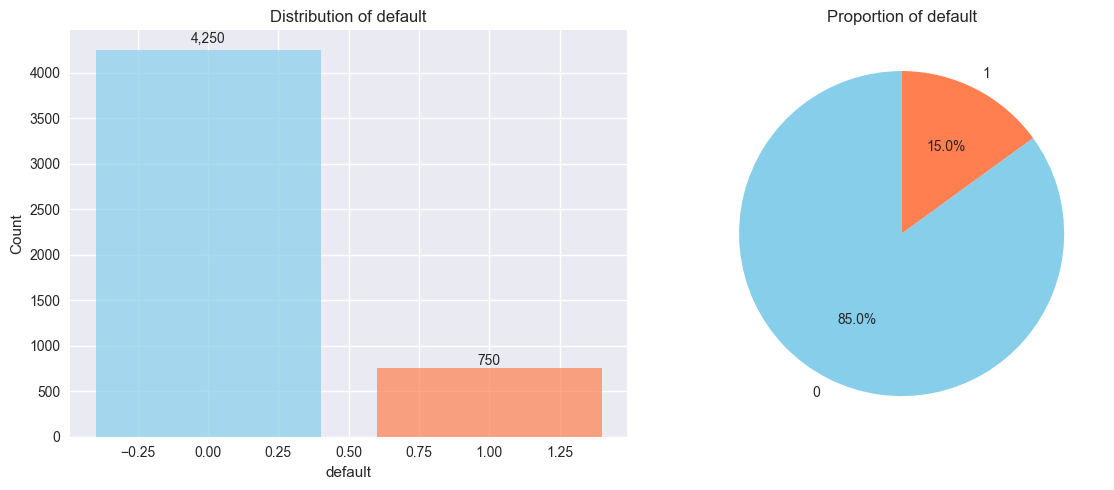


💡 RECOMMENDATIONS
🎯 TARGET VARIABLE SUITABILITY ASSESSMENT
✅ No missing values in target
✅ Good class balance for modeling
✅ Sufficient samples in both classes

🚀 OVERALL: Target variable is suitable for modeling!


In [7]:
def analyze_target_variable(df, target_col):
    """
    Comprehensive analysis of the target variable.
    
    Parameters:
    -----------
    df : pl.DataFrame
        Input dataframe
    target_col : str
        Name of target column
    
    Returns:
    --------
    dict
        Target analysis results
    """
    if df is None or target_col not in df.columns:
        print("Target column not found or no data available.")
        return None
    
    target_data = df.select(target_col).to_series()
    
    # Basic statistics
    total_count = len(target_data)
    null_count = target_data.null_count()
    non_null_data = target_data.drop_nulls()
    
    if len(non_null_data) == 0:
        print("Target column contains only null values.")
        return None
    
    # Value counts
    value_counts = target_data.value_counts().sort(target_col)
    
    # Calculate key metrics
    unique_values = sorted(non_null_data.unique().to_list())
    
    if len(unique_values) != 2:
        print(f"⚠️  Warning: Target has {len(unique_values)} unique values. Expected 2 for binary classification.")
    
    # Assume binary classification with 0/1 or False/True
    if len(unique_values) == 2:
        # Identify positive class (usually 1, True, or higher value)
        positive_class = max(unique_values)
        negative_class = min(unique_values)
        
        positive_count = (non_null_data == positive_class).sum()
        negative_count = (non_null_data == negative_class).sum()
        
        event_rate = positive_count / len(non_null_data)
        balance_ratio = positive_count / negative_count if negative_count > 0 else float('inf')
        
        # Classification of balance
        if 0.1 <= event_rate <= 1:
            balance_status = "Well Balanced"
        elif 0.01 <= event_rate < 0.4:
            balance_status = "Moderately Imbalanced"
        else:
            balance_status = "Highly Imbalanced"
    else:
        positive_class = negative_class = None
        positive_count = negative_count = None
        event_rate = balance_ratio = None
        balance_status = "Not Binary"
    
    analysis = {
        'total_count': total_count,
        'null_count': null_count,
        'null_percentage': (null_count / total_count) * 100,
        'unique_values': unique_values,
        'value_counts': value_counts,
        'positive_class': positive_class,
        'negative_class': negative_class,
        'positive_count': positive_count,
        'negative_count': negative_count,
        'event_rate': event_rate,
        'balance_ratio': balance_ratio,
        'balance_status': balance_status
    }
    
    return analysis

def visualize_target_distribution(df, target_col):
    """Create visualizations for target variable distribution."""
    if df is None or target_col not in df.columns:
        return
    
    target_data = df.select(target_col).to_series().drop_nulls()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Bar plot
    value_counts = target_data.value_counts().sort(target_col)
    values = value_counts.select(target_col).to_series().to_list()
    counts = value_counts.select('count').to_series().to_list()
    
    bars = ax1.bar(values, counts, alpha=0.7, color=['skyblue', 'coral'])
    ax1.set_title(f'Distribution of {target_col}')
    ax1.set_xlabel(target_col)
    ax1.set_ylabel('Count')
    
    # Add count labels on bars
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'{count:,}', ha='center', va='bottom')
    
    # Pie chart
    ax2.pie(counts, labels=values, autopct='%1.1f%%', startangle=90,
            colors=['skyblue', 'coral'])
    ax2.set_title(f'Proportion of {target_col}')
    
    plt.tight_layout()
    plt.show()

def recommend_target_suitability(analysis):
    """Provide recommendations on target variable suitability."""
    if analysis is None:
        return
    
    print("🎯 TARGET VARIABLE SUITABILITY ASSESSMENT")
    print("=" * 60)
    
    recommendations = []
    
    # Check for binary classification
    if len(analysis['unique_values']) != 2:
        recommendations.append("❌ Not suitable: Target should have exactly 2 unique values for binary classification")
        return recommendations
    
    # Check missing values
    if analysis['null_percentage'] > 5:
        recommendations.append(f"⚠️  High missing values: {analysis['null_percentage']:.1f}% nulls detected")
    elif analysis['null_percentage'] > 0:
        recommendations.append(f"⚠️  Some missing values: {analysis['null_percentage']:.1f}% nulls detected")
    else:
        recommendations.append("✅ No missing values in target")
    
    # Check class balance
    if analysis['balance_status'] == "Well Balanced":
        recommendations.append("✅ Good class balance for modeling")
    elif analysis['balance_status'] == "Moderately Imbalanced":
        recommendations.append("⚠️  Moderate class imbalance - consider sampling techniques")
    else:
        recommendations.append("❌ Severe class imbalance - will need special handling")
    
    # Check sample size
    min_class_size = min(analysis['positive_count'], analysis['negative_count'])
    if min_class_size < 100:
        recommendations.append("❌ Very small minority class - may not be sufficient for modeling")
    elif min_class_size < 500:
        recommendations.append("⚠️  Small minority class - consider data collection or sampling")
    else:
        recommendations.append("✅ Sufficient samples in both classes")
    
    # Overall recommendation
    critical_issues = sum(1 for rec in recommendations if rec.startswith("❌"))
    if critical_issues == 0:
        recommendations.append("\n🚀 OVERALL: Target variable is suitable for modeling!")
    else:
        recommendations.append(f"\n🔧 OVERALL: Address {critical_issues} critical issue(s) before modeling")
    
    for rec in recommendations:
        print(rec)

# Analyze target variable
if SELECTED_COLUMNS and df_main is not None:
    target_col = SELECTED_COLUMNS['target']
    
    print(f"🎯 ANALYZING TARGET VARIABLE: {target_col}")
    print("=" * 60)
    
    target_analysis = analyze_target_variable(df_main, target_col)
    
    if target_analysis:
        print(f"Total observations: {target_analysis['total_count']:,}")
        print(f"Missing values: {target_analysis['null_count']:,} ({target_analysis['null_percentage']:.1f}%)")
        print(f"Unique values: {target_analysis['unique_values']}")
        
        if target_analysis['event_rate'] is not None:
            print(f"Event rate: {target_analysis['event_rate']:.1%}")
            print(f"Class balance: {target_analysis['balance_status']}")
            print(f"Positive cases: {target_analysis['positive_count']:,}")
            print(f"Negative cases: {target_analysis['negative_count']:,}")
        
        print(f"\nValue counts:")
        print(target_analysis['value_counts'])
        
        print(f"\n📊 VISUALIZATIONS")
        print("=" * 60)
        visualize_target_distribution(df_main, target_col)
        
        print(f"\n💡 RECOMMENDATIONS")
        print("=" * 60)
        recommend_target_suitability(target_analysis)
        
        # Store for later use
        TARGET_ANALYSIS = target_analysis
else:
    print("⚠️  No target variable selected or no data available.")
    TARGET_ANALYSIS = None

## 6. Bivariate Analysis and Visualization

Analyze relationships between features and the target variable with interactive visualization options.

🔗 CORRELATION ANALYSIS
Top correlations with target:
shape: (8, 3)
┌───────────────────────┬─────────────┬─────────────────┐
│ feature               ┆ correlation ┆ abs_correlation │
│ ---                   ┆ ---         ┆ ---             │
│ str                   ┆ f64         ┆ f64             │
╞═══════════════════════╪═════════════╪═════════════════╡
│ debt_to_income        ┆ 0.54714     ┆ 0.54714         │
│ num_late_payments     ┆ 0.125114    ┆ 0.125114        │
│ age                   ┆ -0.123407   ┆ 0.123407        │
│ employment_length     ┆ -0.095385   ┆ 0.095385        │
│ credit_utilization    ┆ 0.037802    ┆ 0.037802        │
│ credit_history_length ┆ 0.027557    ┆ 0.027557        │
│ income                ┆ -0.00404    ┆ 0.00404         │
│ num_credit_accounts   ┆ -0.00193    ┆ 0.00193         │
└───────────────────────┴─────────────┴─────────────────┘

📊 BIVARIATE ANALYSIS FOR ALL FEATURES
Analyzing 8 features against target: default

🔍 FEATURE 1/8: age


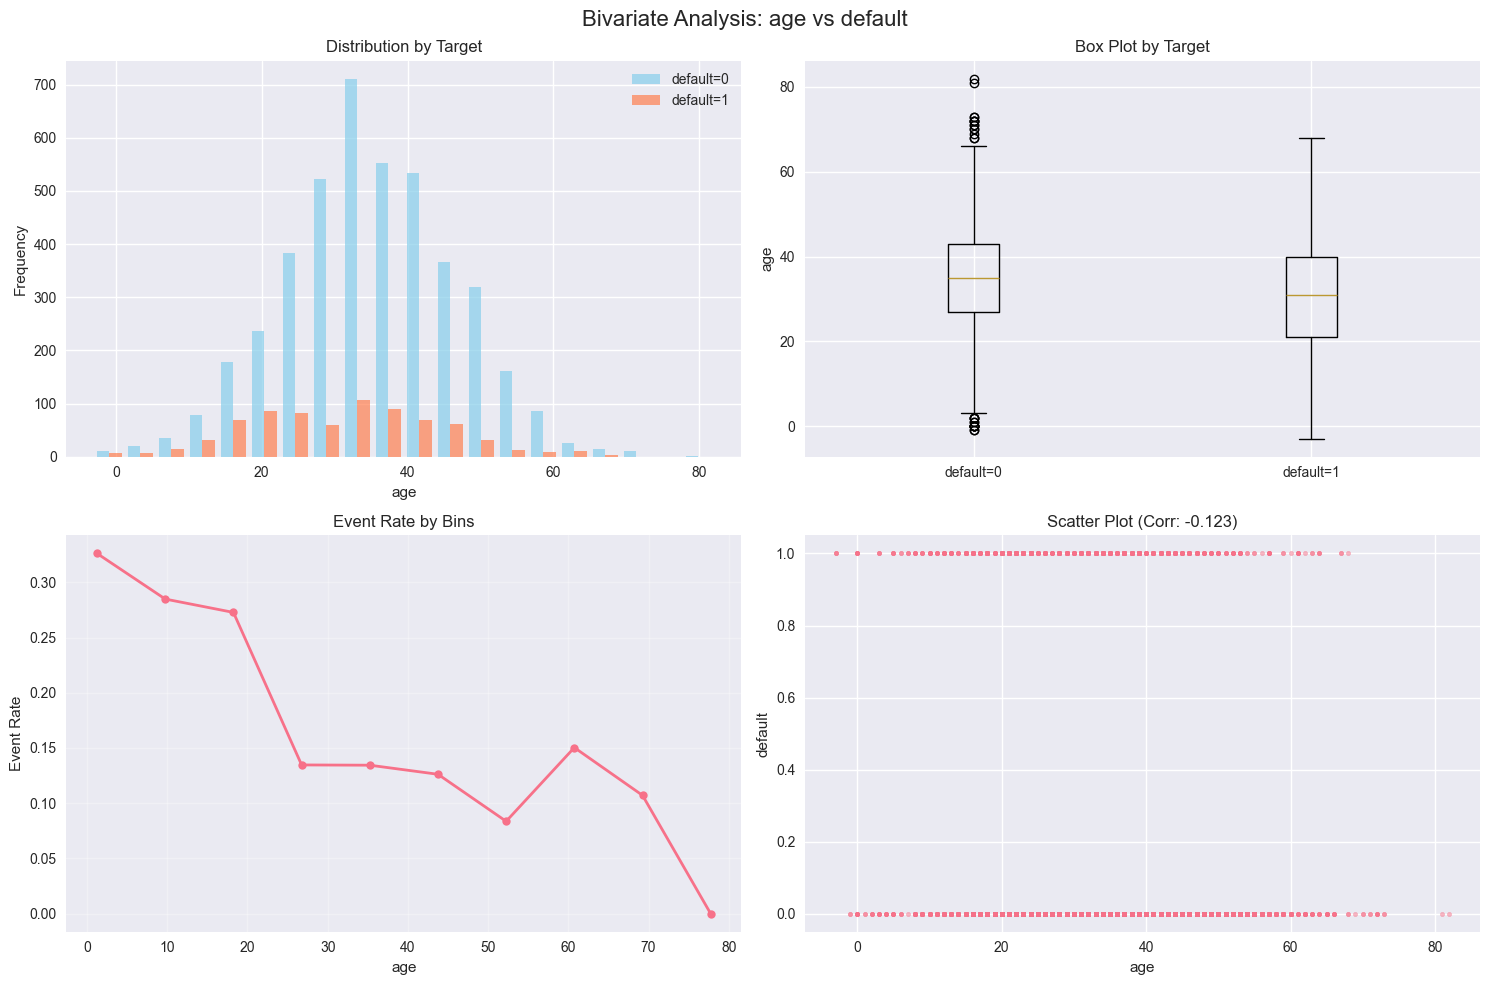


📊 STATISTICAL SUMMARY
Feature: age (Type: Numeric)
Total records: 5,000
Correlation with target: -0.1234
KS Test p-value: 0.0000

────────────────────────────────────────────────────────────────────────────────


🔍 FEATURE 2/8: income


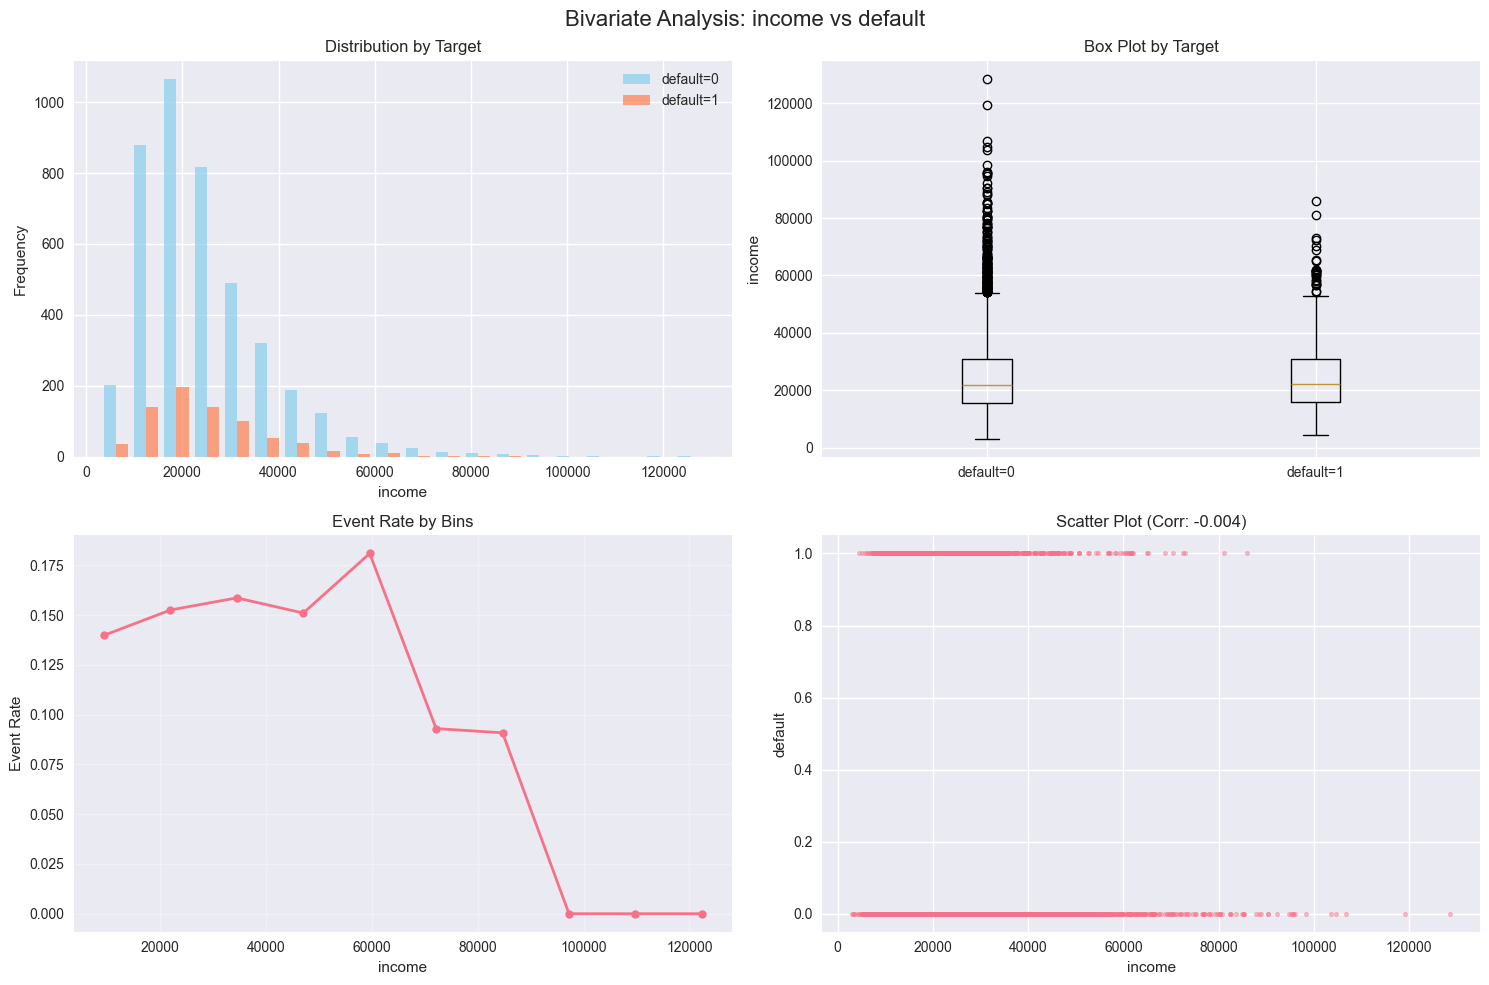


📊 STATISTICAL SUMMARY
Feature: income (Type: Numeric)
Total records: 5,000
Correlation with target: -0.0040
KS Test p-value: 0.5791

────────────────────────────────────────────────────────────────────────────────


🔍 FEATURE 3/8: debt_to_income


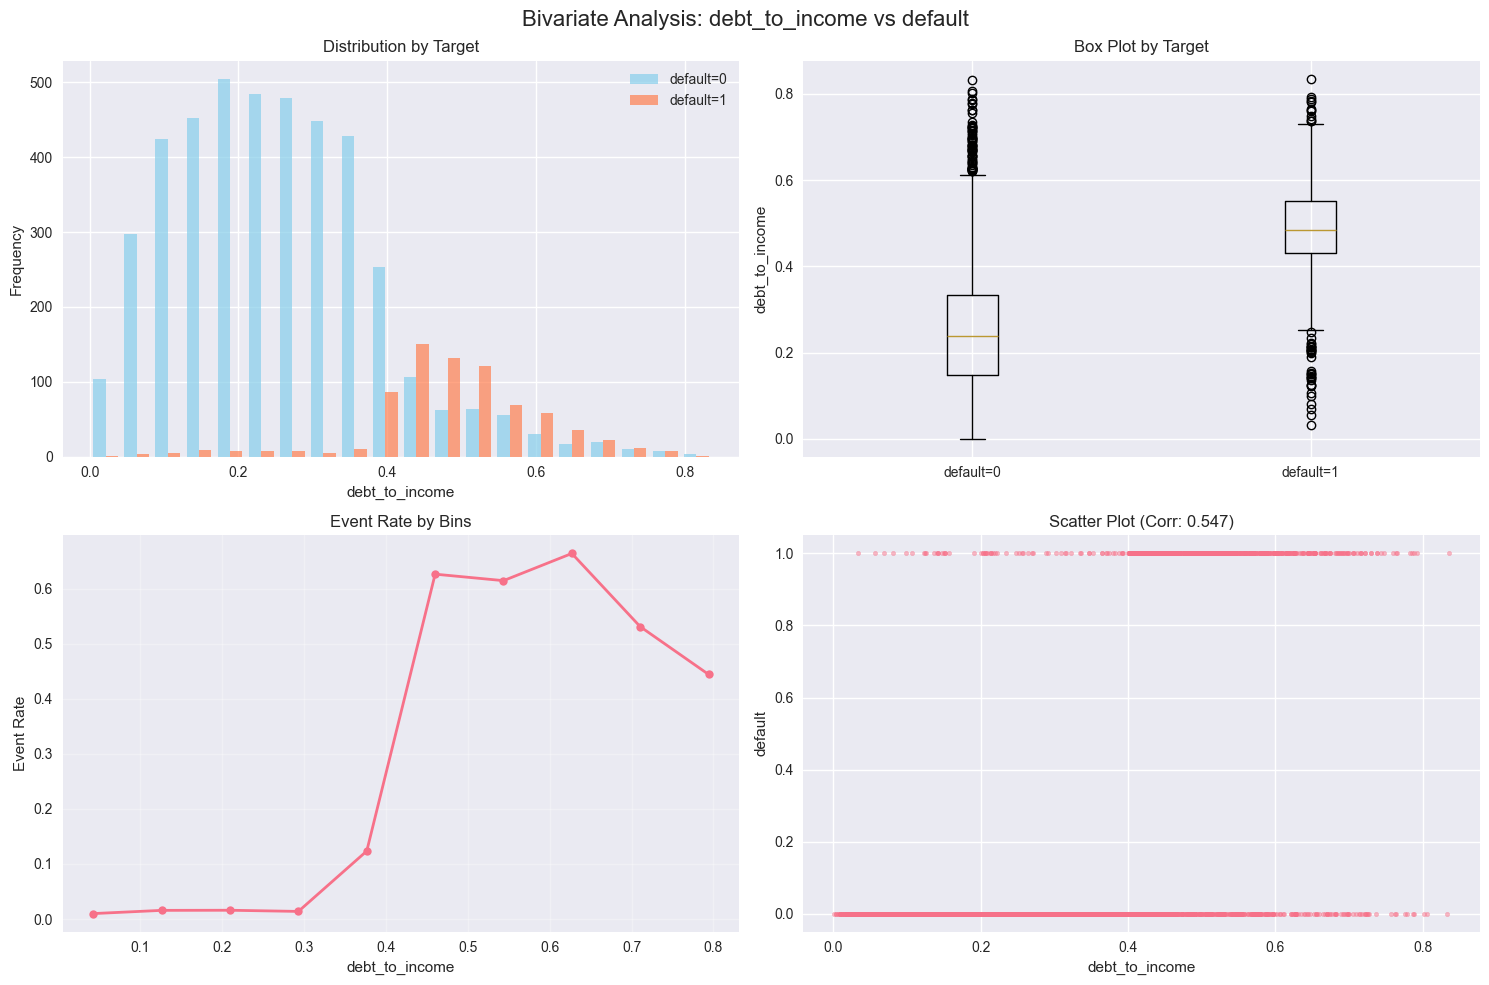


📊 STATISTICAL SUMMARY
Feature: debt_to_income (Type: Numeric)
Total records: 5,000
Correlation with target: 0.5471
KS Test p-value: 0.0000

────────────────────────────────────────────────────────────────────────────────


🔍 FEATURE 4/8: credit_history_length


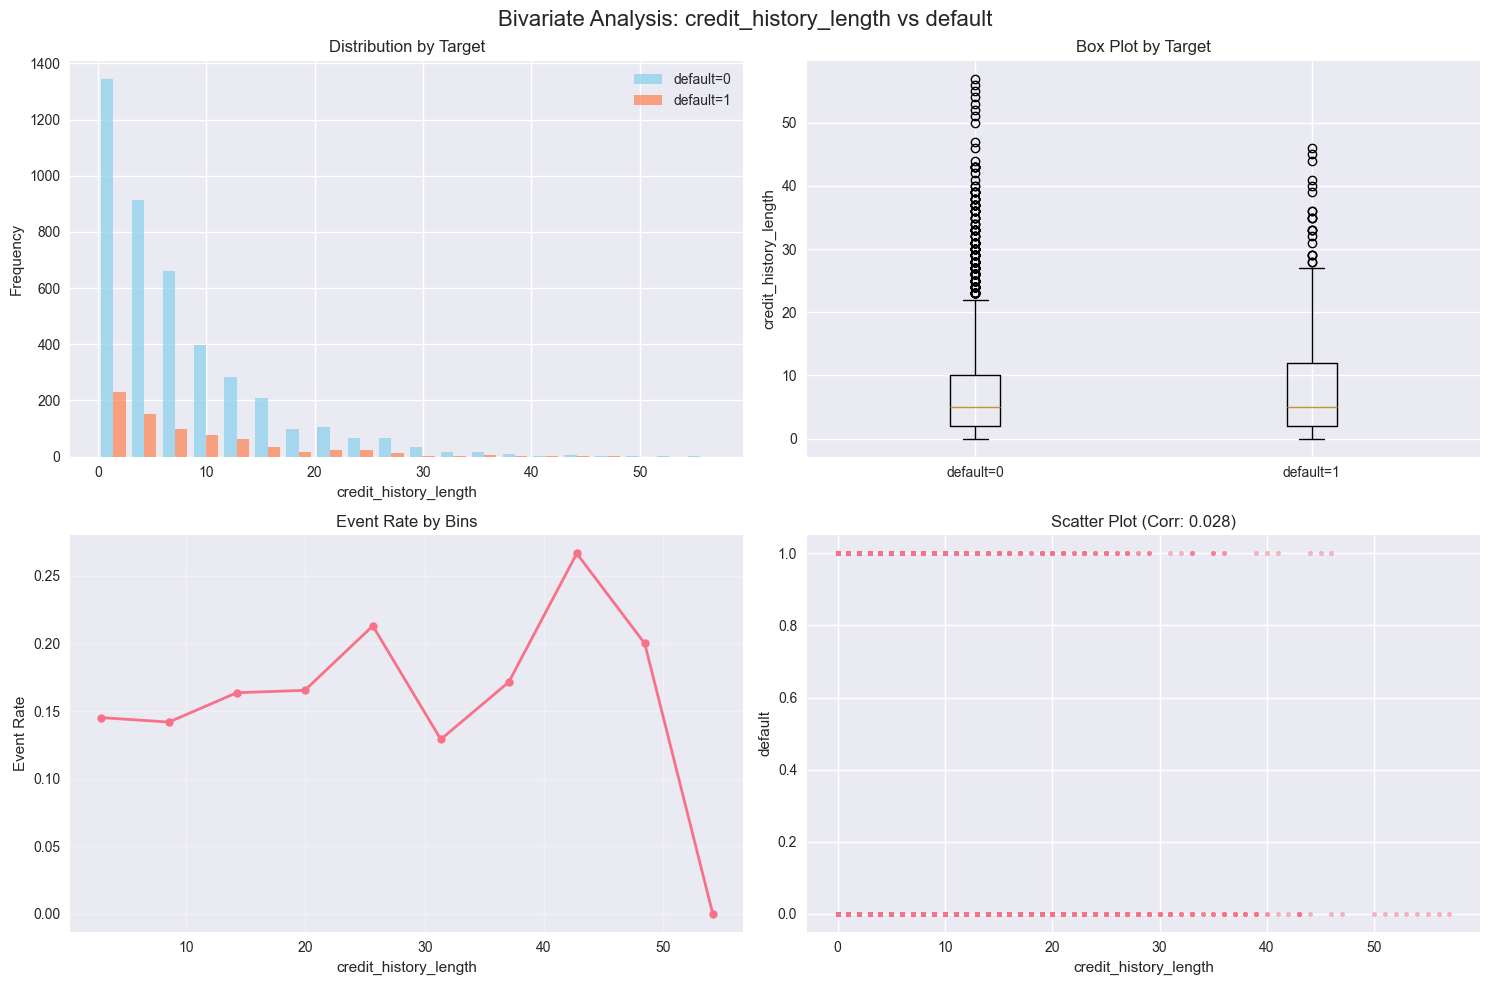


📊 STATISTICAL SUMMARY
Feature: credit_history_length (Type: Numeric)
Total records: 5,000
Correlation with target: 0.0276
KS Test p-value: 0.1253

────────────────────────────────────────────────────────────────────────────────


🔍 FEATURE 5/8: num_credit_accounts


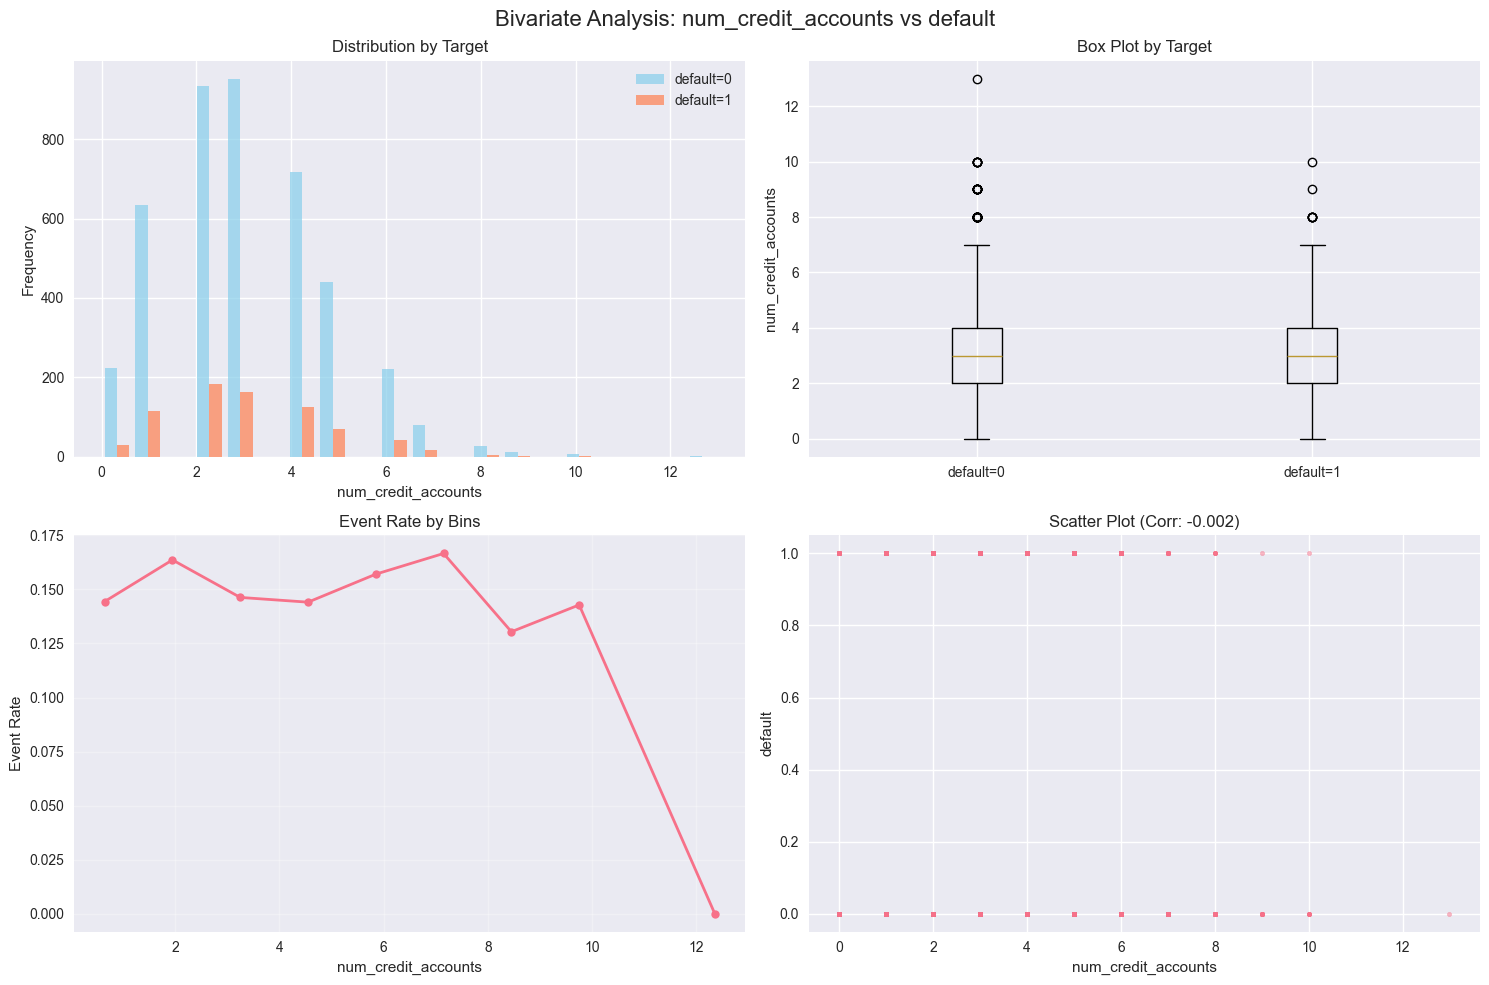


📊 STATISTICAL SUMMARY
Feature: num_credit_accounts (Type: Numeric)
Total records: 5,000
Correlation with target: -0.0019
KS Test p-value: 0.9980

────────────────────────────────────────────────────────────────────────────────


🔍 FEATURE 6/8: credit_utilization


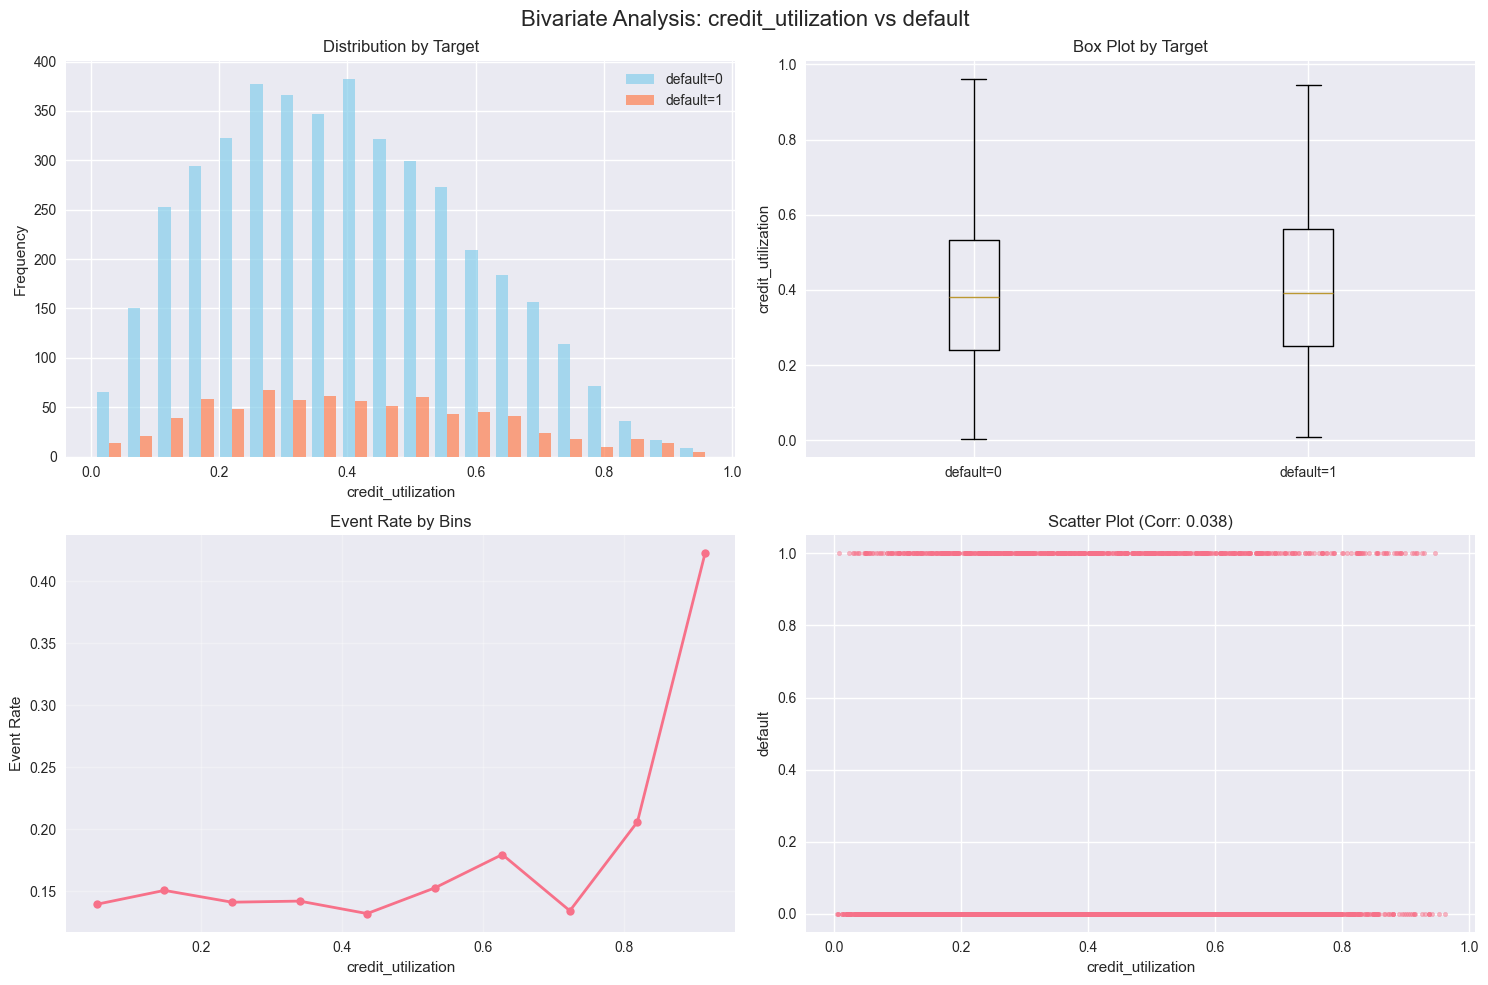


📊 STATISTICAL SUMMARY
Feature: credit_utilization (Type: Numeric)
Total records: 5,000
Correlation with target: 0.0378
KS Test p-value: 0.0524

────────────────────────────────────────────────────────────────────────────────


🔍 FEATURE 7/8: num_late_payments


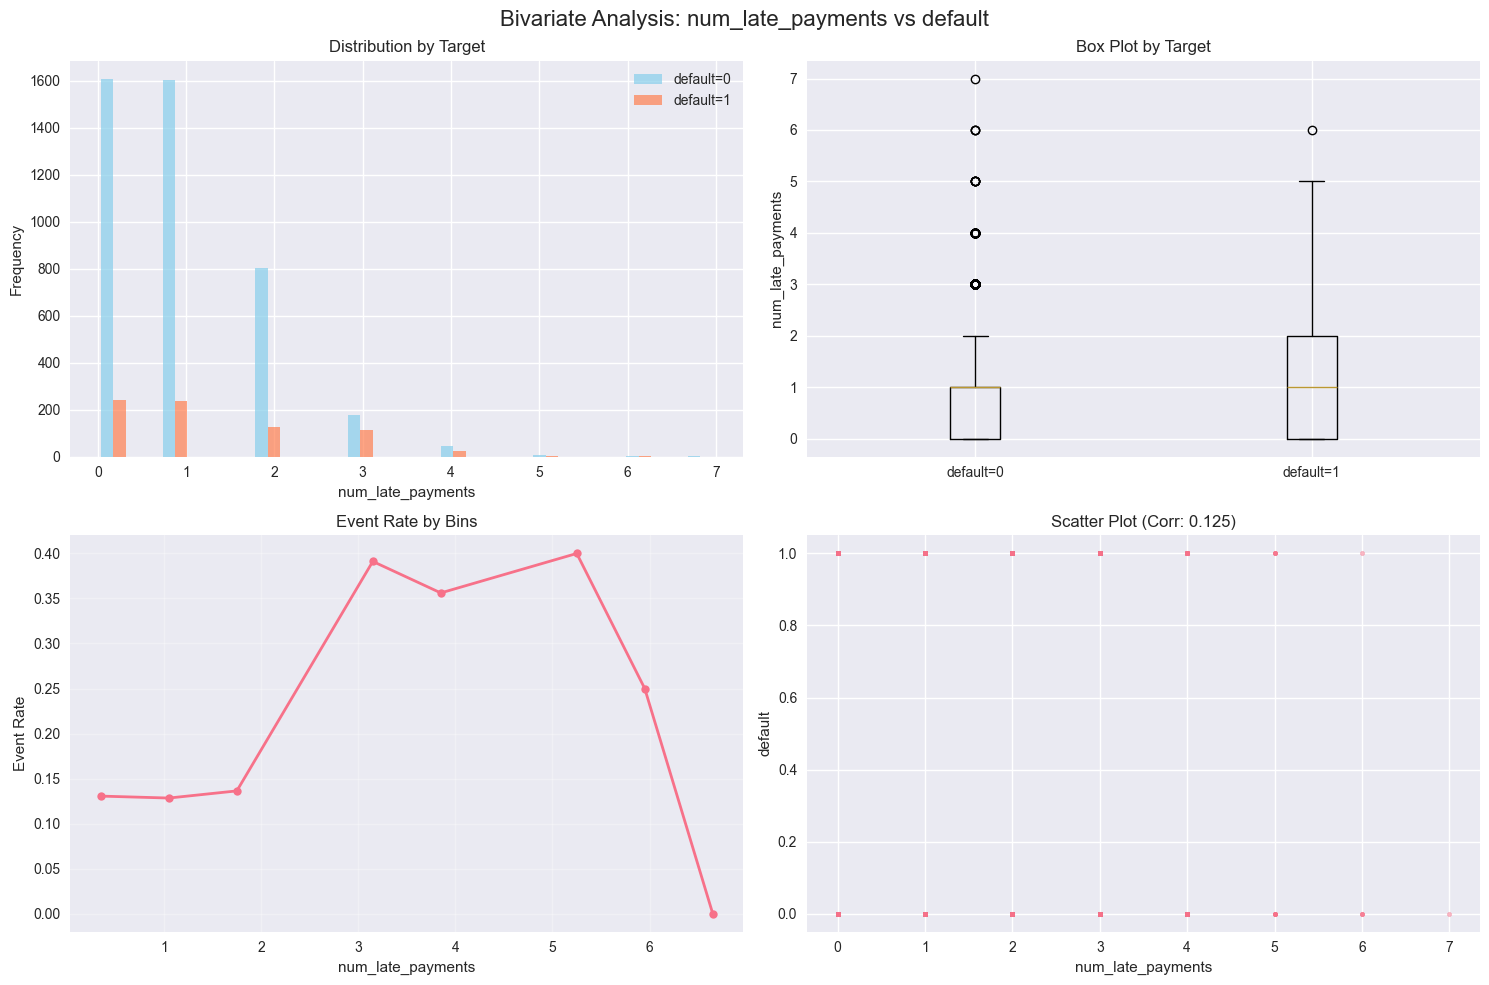


📊 STATISTICAL SUMMARY
Feature: num_late_payments (Type: Numeric)
Total records: 5,000
Correlation with target: 0.1251
KS Test p-value: 0.0000

────────────────────────────────────────────────────────────────────────────────


🔍 FEATURE 8/8: employment_length


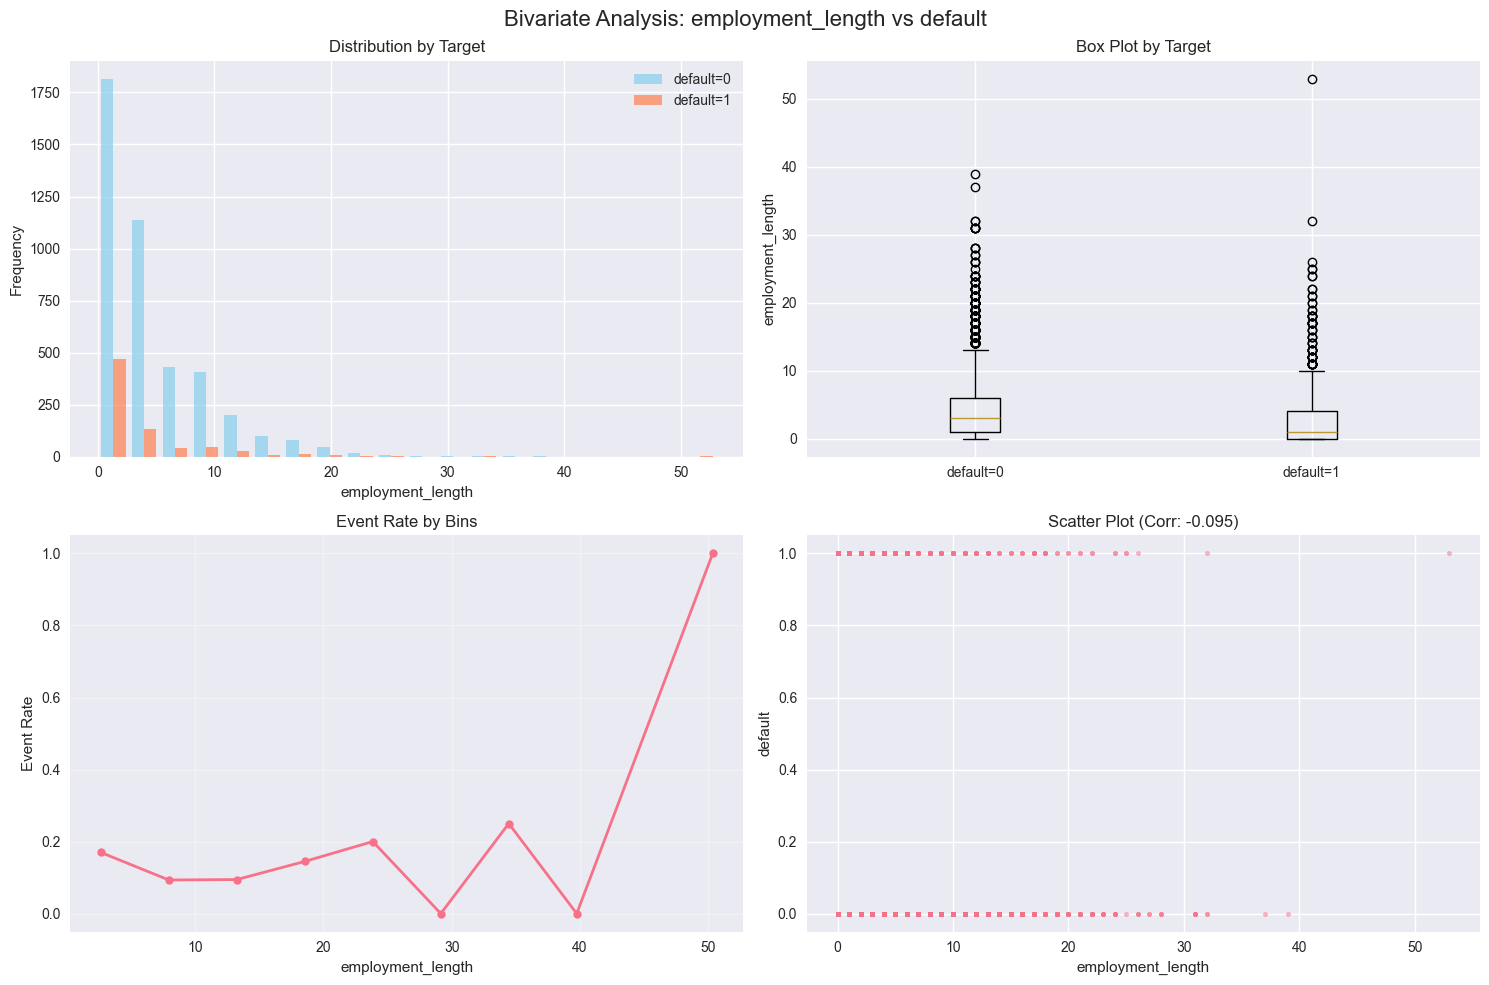


📊 STATISTICAL SUMMARY
Feature: employment_length (Type: Numeric)
Total records: 5,000
Correlation with target: -0.0954
KS Test p-value: 0.0000

✅ BIVARIATE ANALYSIS COMPLETE
Analyzed 8 features successfully!


In [8]:
def calculate_correlation_with_target(df, feature_cols, target_col):
    """
    Calculate correlations between features and target variable.
    
    Parameters:
    -----------
    df : pl.DataFrame
        Input dataframe
    feature_cols : list
        List of feature columns
    target_col : str
        Target column name
    
    Returns:
    --------
    pl.DataFrame
        Correlation results sorted by absolute correlation
    """
    if df is None:
        return None
    
    correlations = []
    
    # Get numeric columns only
    numeric_features = []
    for col in feature_cols:
        if col in df.columns and df.schema[col] in [pl.Int32, pl.Int64, pl.Float32, pl.Float64]:
            numeric_features.append(col)
    
    if not numeric_features:
        print("No numeric features found for correlation analysis.")
        return None
    
    # Calculate correlations
    target_data = df.select(target_col).to_series().drop_nulls().to_numpy()
    
    for feature in numeric_features:
        feature_data = df.select(feature).to_series().drop_nulls().to_numpy()
        
        # Ensure same length (handle missing values)
        common_indices = ~(pl.Series(df.select(feature).to_series().is_null()) | 
                          pl.Series(df.select(target_col).to_series().is_null()))
        
        if common_indices.sum() < 10:  # Need minimum samples
            corr = np.nan
        else:
            common_df = df.filter(common_indices)
            feature_vals = common_df.select(feature).to_series().to_numpy()
            target_vals = common_df.select(target_col).to_series().to_numpy()
            
            corr = np.corrcoef(feature_vals, target_vals)[0, 1]
        
        correlations.append({
            'feature': feature,
            'correlation': corr,
            'abs_correlation': abs(corr) if not np.isnan(corr) else 0
        })
    
    corr_df = pl.DataFrame(correlations).sort('abs_correlation', descending=True)
    return corr_df

def analyze_bivariate_relationship(df, feature_col, target_col, bins=None):
    """
    Analyze relationship between a feature and target variable.
    
    Parameters:
    -----------
    df : pl.DataFrame
        Input dataframe
    feature_col : str
        Feature column name
    target_col : str
        Target column name
    bins : int, optional
        Number of bins for numeric variables (uses settings default if None)
    
    Returns:
    --------
    dict
        Analysis results
    """
    if bins is None:
        bins = ALL_SETTINGS['feature_analysis']['bivariate_bins']
    if df is None or feature_col not in df.columns or target_col not in df.columns:
        return None
    
    # Filter out rows where either column is null
    analysis_df = df.filter(
        pl.col(feature_col).is_not_null() & pl.col(target_col).is_not_null()
    )
    
    if analysis_df.shape[0] == 0:
        return None
    
    feature_dtype = df.schema[feature_col]
    is_numeric = feature_dtype in [pl.Int32, pl.Int64, pl.Float32, pl.Float64]
    
    results = {
        'feature': feature_col,
        'target': target_col,
        'is_numeric': is_numeric,
        'total_records': analysis_df.shape[0]
    }
    
    if is_numeric:
        # Numeric feature analysis
        feature_data = analysis_df.select(feature_col).to_series()
        
        # Create bins
        min_val = feature_data.min()
        max_val = feature_data.max()
        bin_edges = np.linspace(min_val, max_val, bins + 1)
        
        # Assign bins
        binned_data = []
        for i in range(len(bin_edges) - 1):
            bin_start = bin_edges[i]
            bin_end = bin_edges[i + 1]
            
            if i == len(bin_edges) - 2:  # Last bin includes the maximum
                mask = (feature_data >= bin_start) & (feature_data <= bin_end)
            else:
                mask = (feature_data >= bin_start) & (feature_data < bin_end)
            
            bin_df = analysis_df.filter(mask)
            if bin_df.shape[0] > 0:
                bin_target = bin_df.select(target_col).to_series()
                event_rate = bin_target.mean()
                
                binned_data.append({
                    'bin_range': f'[{bin_start:.2f}, {bin_end:.2f}]',
                    'bin_start': bin_start,
                    'bin_end': bin_end,
                    'count': bin_df.shape[0],
                    'events': bin_target.sum(),
                    'event_rate': event_rate
                })
        
        results['binned_analysis'] = binned_data
        
        # Statistical tests
        target_data = analysis_df.select(target_col).to_series().to_numpy()
        feature_vals = analysis_df.select(feature_col).to_series().to_numpy()
        
        # Correlation
        correlation = np.corrcoef(feature_vals, target_data)[0, 1]
        results['correlation'] = correlation
        
        # KS test for different distributions
        positive_vals = feature_vals[target_data == 1]
        negative_vals = feature_vals[target_data == 0]
        
        if len(positive_vals) > 0 and len(negative_vals) > 0:
            ks_stat, ks_pvalue = ks_2samp(positive_vals, negative_vals)
            results['ks_statistic'] = ks_stat
            results['ks_pvalue'] = ks_pvalue
    
    else:
        # Categorical feature analysis
        crosstab_data = []
        
        unique_vals = analysis_df.select(feature_col).to_series().unique().to_list()
        
        for val in unique_vals:
            val_df = analysis_df.filter(pl.col(feature_col) == val)
            if val_df.shape[0] > 0:
                val_target = val_df.select(target_col).to_series()
                event_rate = val_target.mean()
                
                crosstab_data.append({
                    'category': str(val),
                    'count': val_df.shape[0],
                    'events': val_target.sum(),
                    'event_rate': event_rate
                })
        
        results['categorical_analysis'] = crosstab_data
        
        # Chi-square test
        try:
            crosstab = analysis_df.select([feature_col, target_col]).to_pandas().crosstab(
                analysis_df.select(feature_col).to_series().to_list(),
                analysis_df.select(target_col).to_series().to_list()
            )
            chi2, p_value, dof, expected = chi2_contingency(crosstab)
            results['chi2_statistic'] = chi2
            results['chi2_pvalue'] = p_value
        except:
            results['chi2_statistic'] = np.nan
            results['chi2_pvalue'] = np.nan
    
    return results

def visualize_bivariate_relationship(df, feature_col, target_col, bins=None):
    """Create visualizations for bivariate relationship."""
    if bins is None:
        bins = ALL_SETTINGS['feature_analysis']['bivariate_bins']
    if df is None:
        return
    
    analysis = analyze_bivariate_relationship(df, feature_col, target_col, bins)
    if analysis is None:
        print(f"Cannot analyze relationship between {feature_col} and {target_col}")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Bivariate Analysis: {feature_col} vs {target_col}', fontsize=16)
    
    # Filter data for plotting
    plot_df = df.filter(
        pl.col(feature_col).is_not_null() & pl.col(target_col).is_not_null()
    )
    
    if analysis['is_numeric']:
        # Numeric feature plots
        feature_data = plot_df.select(feature_col).to_series().to_numpy()
        target_data = plot_df.select(target_col).to_series().to_numpy()
        
        # Distribution by target
        pos_data = feature_data[target_data == 1]
        neg_data = feature_data[target_data == 0]
        
        axes[0, 0].hist([neg_data, pos_data], bins=20, alpha=0.7, 
                       label=[f'{target_col}=0', f'{target_col}=1'], color=['skyblue', 'coral'])
        axes[0, 0].set_title('Distribution by Target')
        axes[0, 0].set_xlabel(feature_col)
        axes[0, 0].set_ylabel('Frequency')
        axes[0, 0].legend()
        
        # Box plot
        data_for_box = [neg_data, pos_data]
        axes[0, 1].boxplot(data_for_box, labels=[f'{target_col}=0', f'{target_col}=1'])
        axes[0, 1].set_title('Box Plot by Target')
        axes[0, 1].set_ylabel(feature_col)
        
        # Event rate by bins
        if 'binned_analysis' in analysis:
            bin_centers = [(item['bin_start'] + item['bin_end']) / 2 for item in analysis['binned_analysis']]
            event_rates = [item['event_rate'] for item in analysis['binned_analysis']]
            
            axes[1, 0].plot(bin_centers, event_rates, marker='o', linewidth=2, markersize=6)
            axes[1, 0].set_title('Event Rate by Bins')
            axes[1, 0].set_xlabel(feature_col)
            axes[1, 0].set_ylabel('Event Rate')
            axes[1, 0].grid(True, alpha=0.3)
        
        # Scatter plot
        axes[1, 1].scatter(feature_data, target_data, alpha=0.5, s=10)
        axes[1, 1].set_title(f'Scatter Plot (Corr: {analysis.get("correlation", 0):.3f})')
        axes[1, 1].set_xlabel(feature_col)
        axes[1, 1].set_ylabel(target_col)
        
    else:
        # Categorical feature plots
        if 'categorical_analysis' in analysis:
            categories = [item['category'] for item in analysis['categorical_analysis']]
            counts = [item['count'] for item in analysis['categorical_analysis']]
            event_rates = [item['event_rate'] for item in analysis['categorical_analysis']]
            events = [item['events'] for item in analysis['categorical_analysis']]
            
            # Count by category
            axes[0, 0].bar(categories, counts, alpha=0.7, color='skyblue')
            axes[0, 0].set_title('Count by Category')
            axes[0, 0].set_xlabel(feature_col)
            axes[0, 0].set_ylabel('Count')
            axes[0, 0].tick_params(axis='x', rotation=45)
            
            # Event rate by category
            axes[0, 1].bar(categories, event_rates, alpha=0.7, color='coral')
            axes[0, 1].set_title('Event Rate by Category')
            axes[0, 1].set_xlabel(feature_col)
            axes[0, 1].set_ylabel('Event Rate')
            axes[0, 1].tick_params(axis='x', rotation=45)
            
            # Stacked bar chart
            non_events = [count - event for count, event in zip(counts, events)]
            axes[1, 0].bar(categories, non_events, label=f'{target_col}=0', color='skyblue')
            axes[1, 0].bar(categories, events, bottom=non_events, label=f'{target_col}=1', color='coral')
            axes[1, 0].set_title('Stacked Bar Chart')
            axes[1, 0].set_xlabel(feature_col)
            axes[1, 0].set_ylabel('Count')
            axes[1, 0].legend()
            axes[1, 0].tick_params(axis='x', rotation=45)
            
            # Hide the fourth subplot for categorical
            axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistical summary
    print(f"\n📊 STATISTICAL SUMMARY")
    print(f"Feature: {feature_col} (Type: {'Numeric' if analysis['is_numeric'] else 'Categorical'})")
    print(f"Total records: {analysis['total_records']:,}")
    
    if analysis['is_numeric']:
        print(f"Correlation with target: {analysis.get('correlation', 'N/A'):.4f}")
        print(f"KS Test p-value: {analysis.get('ks_pvalue', 'N/A'):.4f}")
    else:
        print(f"Chi-square p-value: {analysis.get('chi2_pvalue', 'N/A'):.4f}")

# Run correlation analysis and show all features analysis
if SELECTED_COLUMNS and df_main is not None:
    feature_cols = SELECTED_COLUMNS['features']
    target_col = SELECTED_COLUMNS['target']
    
    print("🔗 CORRELATION ANALYSIS")
    print("=" * 50)
    
    correlation_results = calculate_correlation_with_target(df_main, feature_cols, target_col)
    if correlation_results is not None:
        print("Top correlations with target:")
        print(correlation_results.head(10))
    
    print(f"\n📊 BIVARIATE ANALYSIS FOR ALL FEATURES")
    print("=" * 60)
    print(f"Analyzing {len(feature_cols)} features against target: {target_col}")
    print("=" * 60)
    
    # Analyze each feature automatically
    for i, feature in enumerate(feature_cols, 1):
        print(f"\n🔍 FEATURE {i}/{len(feature_cols)}: {feature}")
        print("=" * 50)
        visualize_bivariate_relationship(df_main, feature, target_col)
        
        # Add separator between features for clarity
        if i < len(feature_cols):
            print("\n" + "─" * 80 + "\n")
    
    print(f"\n✅ BIVARIATE ANALYSIS COMPLETE")
    print(f"Analyzed {len(feature_cols)} features successfully!")
    
else:
    print("⚠️  No features or target selected for bivariate analysis.")

## 7. Feature Transformation Pipeline

Apply transformations to features including binning, scaling, and encoding with preview capabilities.

In [9]:
class FeatureTransformer:
    """
    Comprehensive feature transformation pipeline for credit scoring.
    """
    
    def __init__(self):
        self.transformations = {}
        self.scalers = {}
        self.encoders = {}
        
    def add_binning_transformation(self, column, method='equal_width', n_bins=10, 
                                  custom_bins=None, labels=None):
        """
        Add binning transformation for a numeric column.
        
        Parameters:
        -----------
        column : str
            Column name to transform
        method : str
            'equal_width', 'equal_frequency', or 'custom'
        n_bins : int
            Number of bins (for equal_width and equal_frequency)
        custom_bins : list
            Custom bin edges (for custom method)
        labels : list
            Custom labels for bins
        """
        self.transformations[column] = {
            'type': 'binning',
            'method': method,
            'n_bins': n_bins,
            'custom_bins': custom_bins,
            'labels': labels
        }
    
    def add_scaling_transformation(self, column, method='standard'):
        """
        Add scaling transformation for a numeric column.
        
        Parameters:
        -----------
        column : str
            Column name to transform
        method : str
            'standard', 'minmax', or 'robust'
        """
        self.transformations[column] = {
            'type': 'scaling',
            'method': method
        }
    
    def add_encoding_transformation(self, column, method='label', 
                                   handle_unknown='error', categories=None):
        """
        Add encoding transformation for a categorical column.
        
        Parameters:
        -----------
        column : str
            Column name to transform
        method : str
            'label', 'onehot', or 'target'
        handle_unknown : str
            How to handle unknown categories
        categories : list
            Predefined categories for encoding
        """
        self.transformations[column] = {
            'type': 'encoding',
            'method': method,
            'handle_unknown': handle_unknown,
            'categories': categories
        }
    
    def fit_transform(self, df, target_col=None):
        """
        Fit transformations and transform the dataframe.
        
        Parameters:
        -----------
        df : pl.DataFrame
            Input dataframe
        target_col : str
            Target column name (needed for target encoding)
        
        Returns:
        --------
        pl.DataFrame
            Transformed dataframe
        """
        df_transformed = df.clone()
        
        for column, config in self.transformations.items():
            if column not in df.columns:
                print(f"Warning: Column '{column}' not found in dataframe")
                continue
            
            print(f"Transforming {column} using {config['type']}...")
            
            if config['type'] == 'binning':
                df_transformed = self._apply_binning(df_transformed, column, config)
            elif config['type'] == 'scaling':
                df_transformed = self._apply_scaling(df_transformed, column, config)
            elif config['type'] == 'encoding':
                df_transformed = self._apply_encoding(df_transformed, column, config, target_col)
        
        return df_transformed
    
    def _apply_binning(self, df, column, config):
        """Apply binning transformation."""
        data = df.select(column).to_series().drop_nulls()
        
        if config['method'] == 'equal_width':
            bin_edges = np.linspace(data.min(), data.max(), config['n_bins'] + 1)
        elif config['method'] == 'equal_frequency':
            bin_edges = np.percentile(data.to_numpy(), 
                                    np.linspace(0, 100, config['n_bins'] + 1))
        elif config['method'] == 'custom':
            bin_edges = config['custom_bins']
        else:
            raise ValueError(f"Unknown binning method: {config['method']}")
        
        # Create bin labels
        if config['labels']:
            labels = config['labels']
        else:
            labels = [f'Bin_{i+1}' for i in range(len(bin_edges) - 1)]
        
        # Apply binning using Polars
        binned_col = f"{column}_binned"
        
        # Create conditions for binning
        conditions = []
        for i in range(len(bin_edges) - 1):
            if i == 0:
                condition = pl.col(column) <= bin_edges[i + 1]
            elif i == len(bin_edges) - 2:
                condition = pl.col(column) > bin_edges[i]
            else:
                condition = (pl.col(column) > bin_edges[i]) & (pl.col(column) <= bin_edges[i + 1])
            conditions.append((condition, labels[i]))
        
        # Apply conditions
        expr = pl.when(conditions[0][0]).then(pl.lit(conditions[0][1]))
        for condition, label in conditions[1:]:
            expr = expr.when(condition).then(pl.lit(label))
        
        df = df.with_columns(expr.alias(binned_col))
        
        # Store bin edges for later use
        self.transformations[column]['bin_edges'] = bin_edges
        self.transformations[column]['labels'] = labels
        
        return df
    
    def _apply_scaling(self, df, column, config):
        """Apply scaling transformation."""
        from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
        
        data = df.select(column).to_series().to_numpy().reshape(-1, 1)
        
        if config['method'] == 'standard':
            scaler = StandardScaler()
        elif config['method'] == 'minmax':
            scaler = MinMaxScaler()
        elif config['method'] == 'robust':
            scaler = RobustScaler()
        else:
            raise ValueError(f"Unknown scaling method: {config['method']}")
        
        # Fit and transform
        scaled_data = scaler.fit_transform(data).flatten()
        self.scalers[column] = scaler
        
        # Create new column
        scaled_col = f"{column}_scaled"
        df = df.with_columns(pl.Series(scaled_data).alias(scaled_col))
        
        return df
    
    def _apply_encoding(self, df, column, config, target_col):
        """Apply encoding transformation."""
        if config['method'] == 'label':
            # Label encoding
            unique_vals = df.select(column).to_series().unique().to_list()
            label_map = {val: i for i, val in enumerate(sorted(unique_vals))}
            
            encoded_col = f"{column}_encoded"
            df = df.with_columns(
                pl.col(column).map_elements(
                    lambda x: label_map.get(x, -1), return_dtype=pl.Int32
                ).alias(encoded_col)
            )
            
            self.encoders[column] = {'type': 'label', 'mapping': label_map}
            
        elif config['method'] == 'target':
            # Target encoding (mean of target for each category)
            if target_col is None:
                raise ValueError("Target column required for target encoding")
            
            # Calculate mean target for each category
            target_means = df.group_by(column).agg(pl.col(target_col).mean().alias('target_mean'))
            
            # Apply encoding
            encoded_col = f"{column}_target_encoded"
            df = df.join(target_means, on=column, how='left')
            df = df.rename({'target_mean': encoded_col})
            
            # Store mapping
            mapping_dict = dict(zip(
                target_means.select(column).to_series().to_list(),
                target_means.select('target_mean').to_series().to_list()
            ))
            self.encoders[column] = {'type': 'target', 'mapping': mapping_dict}
        
        return df
    
    def preview_transformation(self, df, column, config_type, **kwargs):
        """
        Preview the effect of a transformation without applying it permanently.
        
        Parameters:
        -----------
        df : pl.DataFrame
            Input dataframe
        column : str
            Column to transform
        config_type : str
            Type of transformation ('binning', 'scaling', 'encoding')
        **kwargs : dict
            Configuration parameters for the transformation
        
        Returns:
        --------
        dict
            Preview results including before/after statistics
        """
        if column not in df.columns:
            return None
        
        original_data = df.select(column).to_series()
        
        # Create temporary transformer
        temp_transformer = FeatureTransformer()
        
        if config_type == 'binning':
            temp_transformer.add_binning_transformation(column, **kwargs)
        elif config_type == 'scaling':
            temp_transformer.add_scaling_transformation(column, **kwargs)
        elif config_type == 'encoding':
            temp_transformer.add_encoding_transformation(column, **kwargs)
        
        # Apply transformation
        temp_df = temp_transformer.fit_transform(df)
        
        # Find the transformed column
        new_cols = [col for col in temp_df.columns if col not in df.columns]
        if new_cols:
            transformed_col = new_cols[0]
            transformed_data = temp_df.select(transformed_col).to_series()
        else:
            transformed_data = temp_df.select(column).to_series()
        
        # Create preview
        preview = {
            'original_column': column,
            'transformed_column': new_cols[0] if new_cols else column,
            'original_unique_count': original_data.n_unique(),
            'transformed_unique_count': transformed_data.n_unique(),
            'original_nulls': original_data.null_count(),
            'transformed_nulls': transformed_data.null_count(),
            'sample_values': {
                'original': original_data.head(10).to_list(),
                'transformed': transformed_data.head(10).to_list()
            }
        }
        
        return preview

def create_transformation_interface():
    """Create interface for configuring transformations."""
    print("🔧 FEATURE TRANSFORMATION INTERFACE")
    print("=" * 50)
    print("Use the FeatureTransformer class to configure transformations:")
    print()
    print("Example usage:")
    print("transformer = FeatureTransformer()")
    print("transformer.add_binning_transformation('age', method='equal_width', n_bins=5)")
    print("transformer.add_scaling_transformation('income', method='standard')")
    print("transformer.add_encoding_transformation('category_col', method='label')")
    print("df_transformed = transformer.fit_transform(df_main, target_col)")
    print()
    print("Available transformations:")
    print("- Binning: 'equal_width', 'equal_frequency', 'custom'")
    print("- Scaling: 'standard', 'minmax', 'robust'")
    print("- Encoding: 'label', 'target'")

# Initialize transformer and demonstrate usage
if SELECTED_COLUMNS and df_main is not None:
    
    create_transformation_interface()
    
    # Example transformations for demonstration
    print(f"\n📋 DEMONSTRATION WITH SAMPLE DATA")
    print("=" * 50)
    
    transformer = FeatureTransformer()
    
    # Add some example transformations
    feature_cols = SELECTED_COLUMNS['features']
    
    # Example: Bin age into groups
    if 'age' in feature_cols:
        print("Adding age binning transformation...")
        transformer.add_binning_transformation('age', method='equal_width', n_bins=5)
        
        # Preview the transformation
        preview = transformer.preview_transformation(
            df_main, 'age', 'binning', method='equal_width', n_bins=5
        )
        if preview:
            print(f"Preview - Age binning:")
            print(f"  Original unique values: {preview['original_unique_count']}")
            print(f"  Transformed unique values: {preview['transformed_unique_count']}")
            print(f"  Sample original: {preview['sample_values']['original'][:5]}")
            print(f"  Sample transformed: {preview['sample_values']['transformed'][:5]}")
    
    # Example: Scale income
    if 'income' in feature_cols:
        print(f"\nAdding income scaling transformation...")
        transformer.add_scaling_transformation('income', method='standard')
    
    # Apply transformations
    print(f"\n🚀 APPLYING TRANSFORMATIONS")
    print("=" * 50)
    
    df_transformed = transformer.fit_transform(df_main, SELECTED_COLUMNS['target'])
    
    print(f"Original columns: {len(df_main.columns)}")
    print(f"Transformed columns: {len(df_transformed.columns)}")
    print(f"New columns: {[col for col in df_transformed.columns if col not in df_main.columns]}")
    
    # Store for later use
    TRANSFORMER = transformer
    DF_TRANSFORMED = df_transformed
    
else:
    create_transformation_interface()
    TRANSFORMER = None
    DF_TRANSFORMED = None

🔧 FEATURE TRANSFORMATION INTERFACE
Use the FeatureTransformer class to configure transformations:

Example usage:
transformer = FeatureTransformer()
transformer.add_binning_transformation('age', method='equal_width', n_bins=5)
transformer.add_scaling_transformation('income', method='standard')
transformer.add_encoding_transformation('category_col', method='label')
df_transformed = transformer.fit_transform(df_main, target_col)

Available transformations:
- Binning: 'equal_width', 'equal_frequency', 'custom'
- Scaling: 'standard', 'minmax', 'robust'
- Encoding: 'label', 'target'

📋 DEMONSTRATION WITH SAMPLE DATA
Adding age binning transformation...
Transforming age using binning...
Preview - Age binning:
  Original unique values: 78
  Transformed unique values: 5
  Sample original: [40, 33, 42, 53, 32]
  Sample transformed: ['Bin_3', 'Bin_3', 'Bin_3', 'Bin_4', 'Bin_3']

Adding income scaling transformation...

🚀 APPLYING TRANSFORMATIONS
Transforming age using binning...
Transforming inc

## 8. Information Value Calculation and Feature Selection

Calculate Information Value (IV) for feature selection based on predictive power.

🔍 INFORMATION VALUE ANALYSIS
📊 Calculating Information Value for all features...
   1/8: age
   2/8: income
   3/8: debt_to_income
   4/8: credit_history_length
   5/8: num_credit_accounts
   6/8: credit_utilization
   7/8: num_late_payments
   8/8: employment_length

📋 IV RESULTS SUMMARY
shape: (8, 6)
┌───────────────────┬───────────────────┬──────────────────┬───────────────┬──────────┬────────────┐
│ feature           ┆ information_value ┆ iv_interpretatio ┆ total_records ┆ bad_rate ┆ is_numeric │
│ ---               ┆ ---               ┆ n                ┆ ---           ┆ ---      ┆ ---        │
│ str               ┆ f64               ┆ ---              ┆ i64           ┆ f64      ┆ bool       │
│                   ┆                   ┆ str              ┆               ┆          ┆            │
╞═══════════════════╪═══════════════════╪══════════════════╪═══════════════╪══════════╪════════════╡
│ debt_to_income    ┆ 3.339281          ┆ Suspicious - Too ┆ 5000          ┆ 0.15     ┆ tr

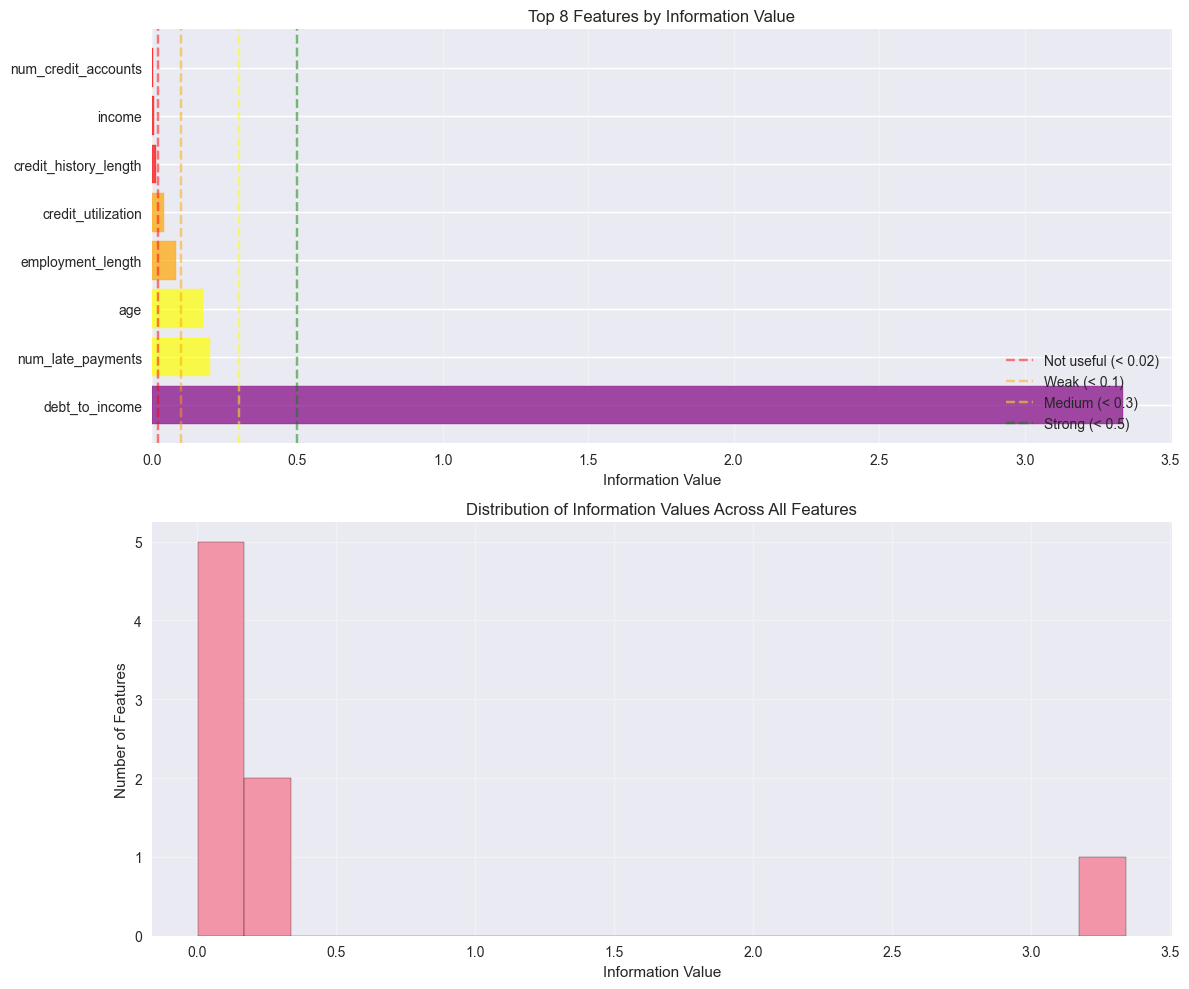

🎯 FEATURE SELECTION BY INFORMATION VALUE
   Minimum IV threshold: 0.01
   Maximum features: 50
   Selected features: 6

Selected features for modeling:
   1. debt_to_income (IV: 3.3393)
   2. num_late_payments (IV: 0.1995)
   3. age (IV: 0.1753)
   4. employment_length (IV: 0.0823)
   5. credit_utilization (IV: 0.0430)
   6. credit_history_length (IV: 0.0142)

🔍 DETAILED WoE ANALYSIS FOR ALL FEATURES

FEATURE 1 of 6: debt_to_income
📊 WEIGHT OF EVIDENCE ANALYSIS: debt_to_income
Information Value: 3.3393
Interpretation: Suspicious - Too good to be true
Total Records: 5,000
Overall Bad Rate: 15.0%

Detailed Bin Analysis:
shape: (10, 7)
┌──────────────┬────────┬───────┬───────┬──────────┬─────────┬─────────────────┐
│ Bin          ┆ Total  ┆ Goods ┆ Bads  ┆ Bad_Rate ┆ WoE     ┆ IV_Contribution │
│ ---          ┆ ---    ┆ ---   ┆ ---   ┆ ---      ┆ ---     ┆ ---             │
│ str          ┆ f64    ┆ f64   ┆ f64   ┆ str      ┆ str     ┆ str             │
╞══════════════╪════════╪═══════╪══

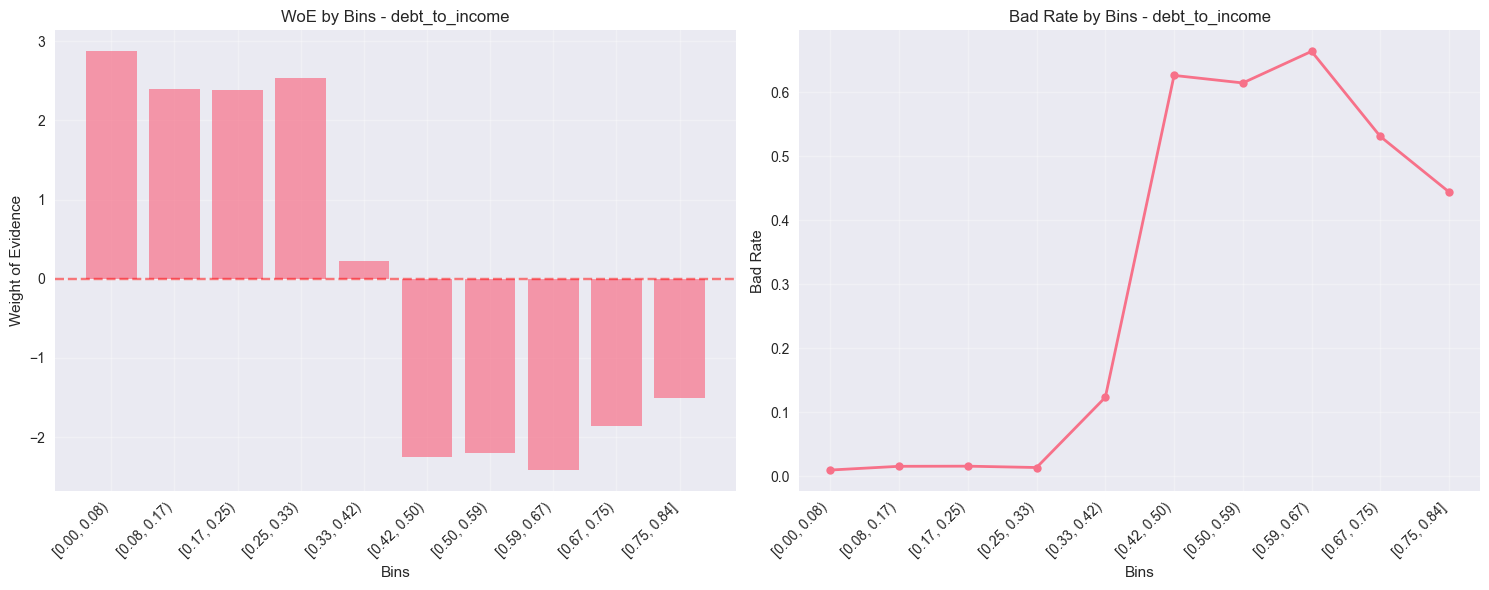


--------------------------------------------------------------------------------


FEATURE 2 of 6: num_late_payments
📊 WEIGHT OF EVIDENCE ANALYSIS: num_late_payments
Information Value: 0.1995
Interpretation: Medium predictive power
Total Records: 5,000
Overall Bad Rate: 15.0%

Detailed Bin Analysis:
shape: (8, 7)
┌──────────────┬────────┬────────┬───────┬──────────┬─────────┬─────────────────┐
│ Bin          ┆ Total  ┆ Goods  ┆ Bads  ┆ Bad_Rate ┆ WoE     ┆ IV_Contribution │
│ ---          ┆ ---    ┆ ---    ┆ ---   ┆ ---      ┆ ---     ┆ ---             │
│ str          ┆ f64    ┆ f64    ┆ f64   ┆ str      ┆ str     ┆ str             │
╞══════════════╪════════╪════════╪═══════╪══════════╪═════════╪═════════════════╡
│ [0.00, 0.70) ┆ 1847.0 ┆ 1606.0 ┆ 241.0 ┆ 13.0%    ┆ 0.1621  ┆ 0.0092          │
│ [0.70, 1.40) ┆ 1839.0 ┆ 1603.0 ┆ 236.0 ┆ 12.8%    ┆ 0.1812  ┆ 0.0113          │
│ [1.40, 2.10) ┆ 932.0  ┆ 805.0  ┆ 127.0 ┆ 13.6%    ┆ 0.1121  ┆ 0.0022          │
│ [2.80, 3.50) ┆ 294.0  ┆ 17

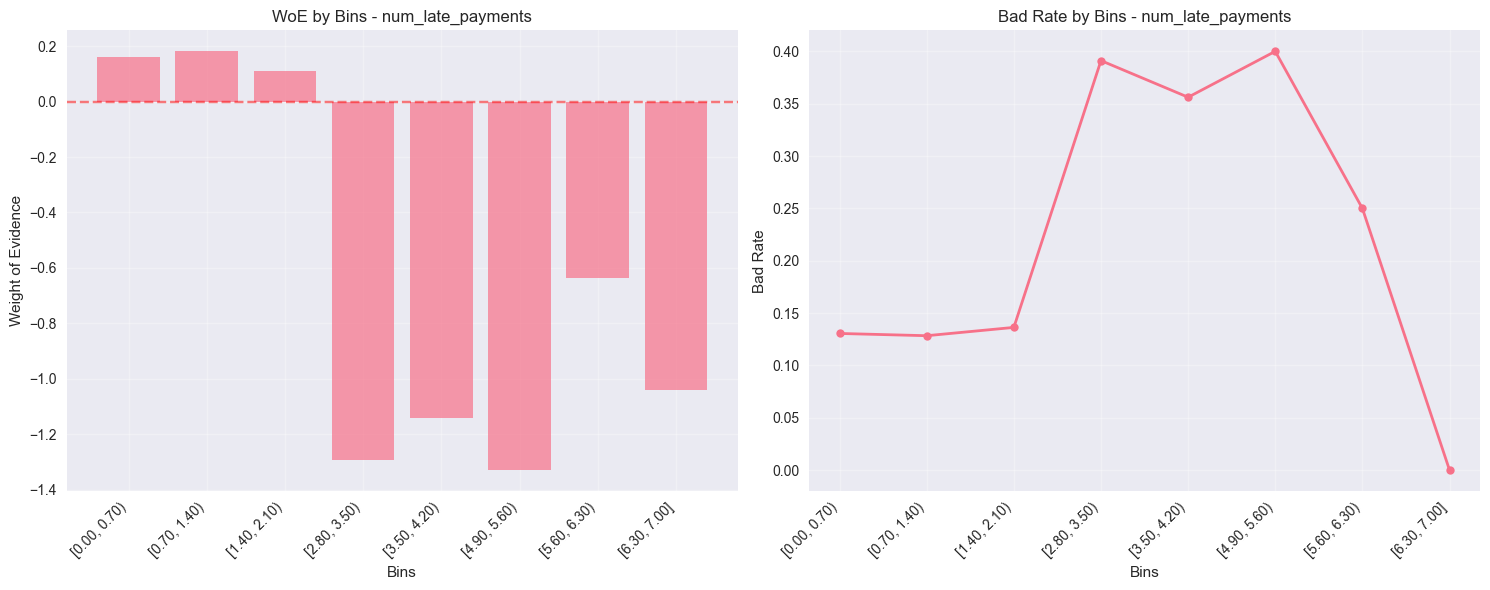


--------------------------------------------------------------------------------


FEATURE 3 of 6: age
📊 WEIGHT OF EVIDENCE ANALYSIS: age
Information Value: 0.1753
Interpretation: Medium predictive power
Total Records: 5,000
Overall Bad Rate: 15.0%

Detailed Bin Analysis:
shape: (10, 7)
┌────────────────┬────────┬────────┬───────┬──────────┬─────────┬─────────────────┐
│ Bin            ┆ Total  ┆ Goods  ┆ Bads  ┆ Bad_Rate ┆ WoE     ┆ IV_Contribution │
│ ---            ┆ ---    ┆ ---    ┆ ---   ┆ ---      ┆ ---     ┆ ---             │
│ str            ┆ f64    ┆ f64    ┆ f64   ┆ str      ┆ str     ┆ str             │
╞════════════════╪════════╪════════╪═══════╪══════════╪═════════╪═════════════════╡
│ [-3.00, 5.50)  ┆ 46.0   ┆ 31.0   ┆ 15.0  ┆ 32.6%    ┆ -1.0087 ┆ 0.0128          │
│ [5.50, 14.00)  ┆ 158.0  ┆ 113.0  ┆ 45.0  ┆ 28.5%    ┆ -0.8139 ┆ 0.0272          │
│ [14.00, 22.50) ┆ 572.0  ┆ 416.0  ┆ 156.0 ┆ 27.3%    ┆ -0.7538 ┆ 0.0830          │
│ [22.50, 31.00) ┆ 1047.0 ┆ 906.0  ┆ 14

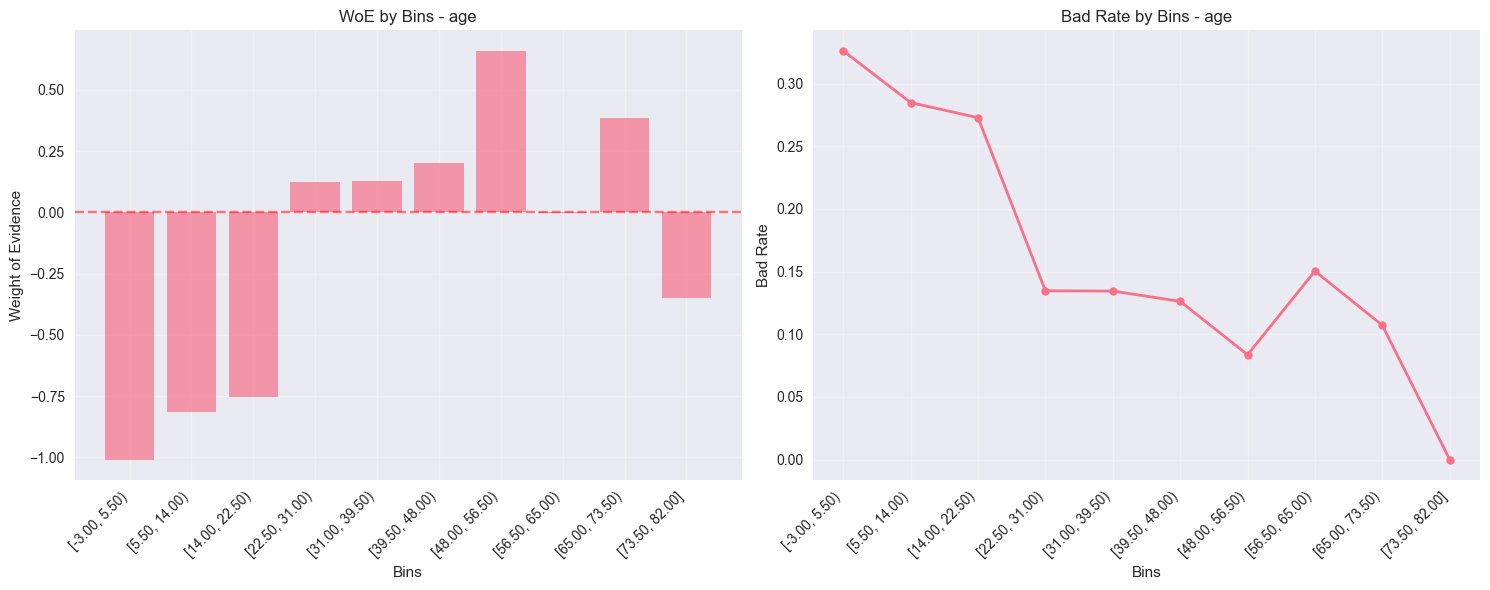


--------------------------------------------------------------------------------


FEATURE 4 of 6: employment_length
📊 WEIGHT OF EVIDENCE ANALYSIS: employment_length
Information Value: 0.0823
Interpretation: Weak predictive power
Total Records: 5,000
Overall Bad Rate: 15.0%

Detailed Bin Analysis:
shape: (9, 7)
┌────────────────┬────────┬────────┬───────┬──────────┬─────────┬─────────────────┐
│ Bin            ┆ Total  ┆ Goods  ┆ Bads  ┆ Bad_Rate ┆ WoE     ┆ IV_Contribution │
│ ---            ┆ ---    ┆ ---    ┆ ---   ┆ ---      ┆ ---     ┆ ---             │
│ str            ┆ f64    ┆ f64    ┆ f64   ┆ str      ┆ str     ┆ str             │
╞════════════════╪════════╪════════╪═══════╪══════════╪═════════╪═════════════════╡
│ [0.00, 5.30)   ┆ 3554.0 ┆ 2951.0 ┆ 603.0 ┆ 17.0%    ┆ -0.1466 ┆ 0.0161          │
│ [5.30, 10.60)  ┆ 922.0  ┆ 836.0  ┆ 86.0  ┆ 9.3%     ┆ 0.5397  ┆ 0.0443          │
│ [10.60, 15.90) ┆ 328.0  ┆ 297.0  ┆ 31.0  ┆ 9.5%     ┆ 0.5251  ┆ 0.0150          │
│ [15.90, 21.2

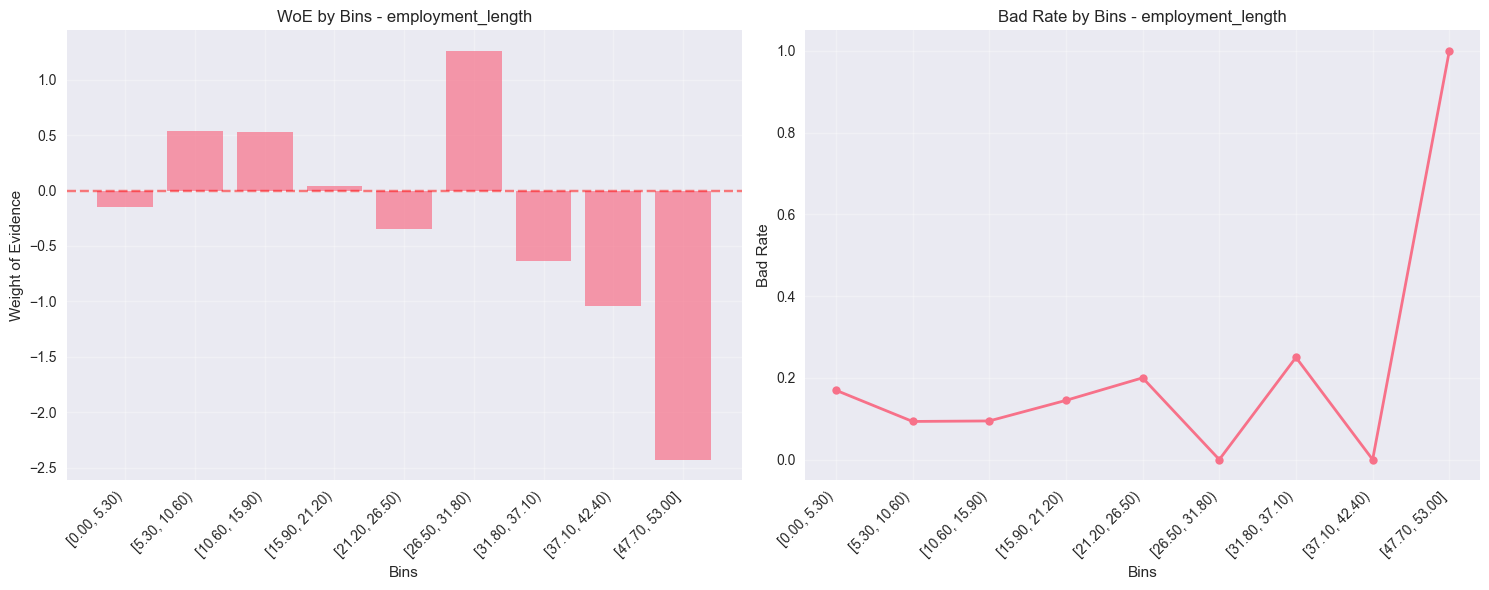


--------------------------------------------------------------------------------


FEATURE 5 of 6: credit_utilization
📊 WEIGHT OF EVIDENCE ANALYSIS: credit_utilization
Information Value: 0.0430
Interpretation: Weak predictive power
Total Records: 5,000
Overall Bad Rate: 15.0%

Detailed Bin Analysis:
shape: (10, 7)
┌──────────────┬───────┬───────┬───────┬──────────┬─────────┬─────────────────┐
│ Bin          ┆ Total ┆ Goods ┆ Bads  ┆ Bad_Rate ┆ WoE     ┆ IV_Contribution │
│ ---          ┆ ---   ┆ ---   ┆ ---   ┆ ---      ┆ ---     ┆ ---             │
│ str          ┆ f64   ┆ f64   ┆ f64   ┆ str      ┆ str     ┆ str             │
╞══════════════╪═══════╪═══════╪═══════╪══════════╪═════════╪═════════════════╡
│ [0.00, 0.10) ┆ 251.0 ┆ 216.0 ┆ 35.0  ┆ 13.9%    ┆ 0.0853  ┆ 0.0004          │
│ [0.10, 0.20) ┆ 644.0 ┆ 547.0 ┆ 97.0  ┆ 15.1%    ┆ -0.0049 ┆ 0.0000          │
│ [0.20, 0.29) ┆ 815.0 ┆ 700.0 ┆ 115.0 ┆ 14.1%    ┆ 0.0715  ┆ 0.0008          │
│ [0.29, 0.39) ┆ 831.0 ┆ 713.0 ┆ 118.0 ┆ 14

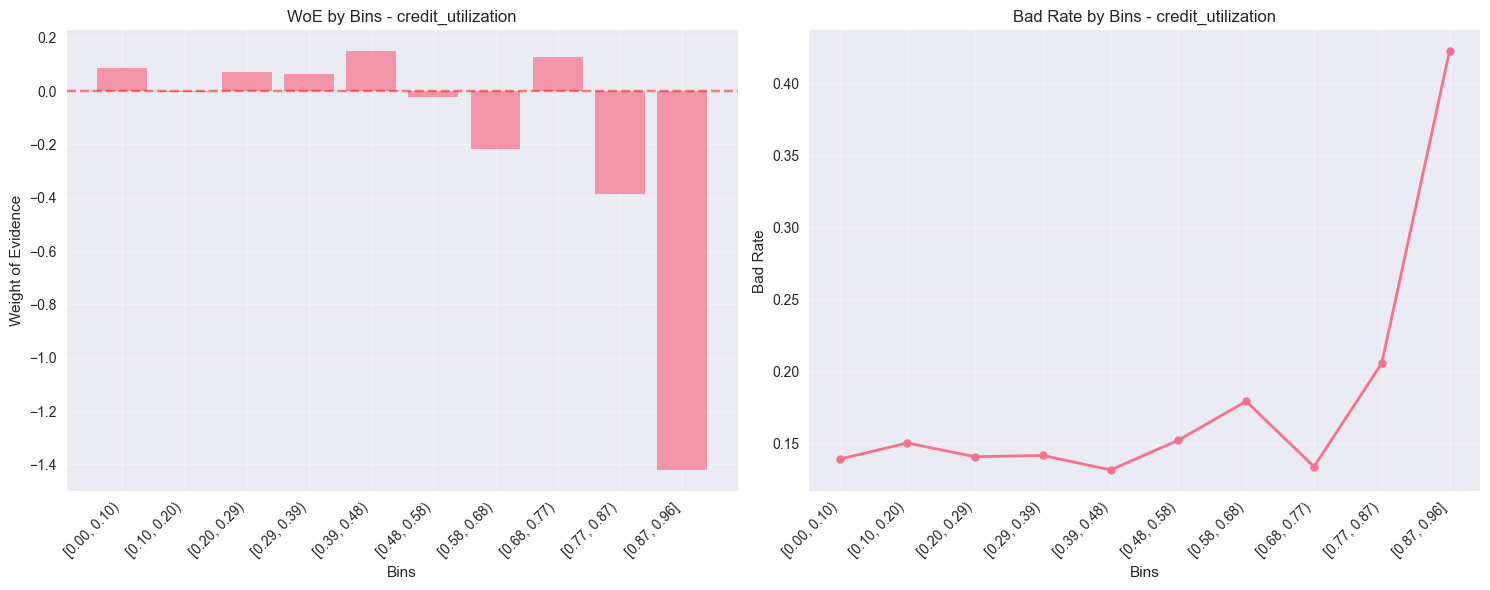


--------------------------------------------------------------------------------


FEATURE 6 of 6: credit_history_length
📊 WEIGHT OF EVIDENCE ANALYSIS: credit_history_length
Information Value: 0.0142
Interpretation: Not useful for prediction
Total Records: 5,000
Overall Bad Rate: 15.0%

Detailed Bin Analysis:
shape: (10, 7)
┌────────────────┬────────┬────────┬───────┬──────────┬─────────┬─────────────────┐
│ Bin            ┆ Total  ┆ Goods  ┆ Bads  ┆ Bad_Rate ┆ WoE     ┆ IV_Contribution │
│ ---            ┆ ---    ┆ ---    ┆ ---   ┆ ---      ┆ ---     ┆ ---             │
│ str            ┆ f64    ┆ f64    ┆ f64   ┆ str      ┆ str     ┆ str             │
╞════════════════╪════════╪════════╪═══════╪══════════╪═════════╪═════════════════╡
│ [0.00, 5.70)   ┆ 2639.0 ┆ 2256.0 ┆ 383.0 ┆ 14.5%    ┆ 0.0387  ┆ 0.0008          │
│ [5.70, 11.40)  ┆ 1234.0 ┆ 1059.0 ┆ 175.0 ┆ 14.2%    ┆ 0.0657  ┆ 0.0010          │
│ [11.40, 17.10) ┆ 587.0  ┆ 491.0  ┆ 96.0  ┆ 16.4%    ┆ -0.1025 ┆ 0.0013          │
│

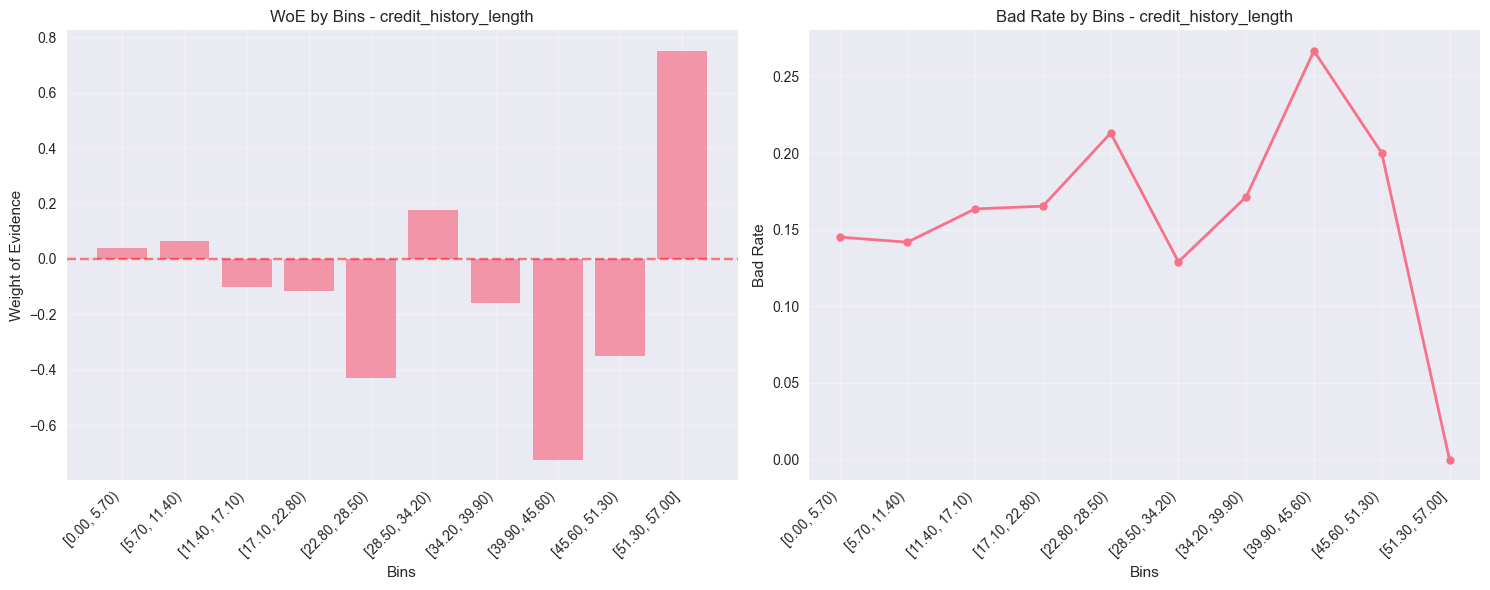

In [ ]:
def calculate_woe_iv(df, feature_col, target_col, bins=None):
    """
    Calculate Weight of Evidence (WoE) and Information Value (IV) for a feature.
    
    Parameters:
    -----------
    df : pl.DataFrame
        Input dataframe
    feature_col : str
        Feature column name
    target_col : str
        Target column name
    bins : int, optional
        Number of bins for continuous variables (uses settings default if None)
    
    Returns:
    --------
    dict
        Dictionary containing WoE, IV calculations and bin analysis
    """
    if bins is None:
        bins = ALL_SETTINGS['feature_analysis']['bivariate_bins']
    if df is None or feature_col not in df.columns or target_col not in df.columns:
        return None
    
    # Remove rows with nulls
    clean_df = df.filter(
        pl.col(feature_col).is_not_null() & pl.col(target_col).is_not_null()
    )
    
    if clean_df.shape[0] == 0:
        return None
    
    # Determine if feature is numeric or categorical
    feature_dtype = df.schema[feature_col]
    is_numeric = feature_dtype in [pl.Int32, pl.Int64, pl.Float32, pl.Float64]
    
    # Create bins for analysis
    if is_numeric:
        # For numeric variables, create bins
        feature_data = clean_df.select(feature_col).to_series()
        min_val = feature_data.min()
        max_val = feature_data.max()
        
        if min_val == max_val:
            # Constant feature
            bin_edges = [min_val, max_val]
            bins = 1
        else:
            bin_edges = np.linspace(min_val, max_val, bins + 1)
        
        # Assign bins
        bin_labels = []
        bin_analysis = []
        
        for i in range(len(bin_edges) - 1):
            bin_start = bin_edges[i]
            bin_end = bin_edges[i + 1]
            
            if i == len(bin_edges) - 2:  # Last bin includes the maximum
                mask = (feature_data >= bin_start) & (feature_data <= bin_end)
                bin_label = f'[{bin_start:.2f}, {bin_end:.2f}]'
            else:
                mask = (feature_data >= bin_start) & (feature_data < bin_end)
                bin_label = f'[{bin_start:.2f}, {bin_end:.2f})'
            
            bin_df = clean_df.filter(mask)
            
            if bin_df.shape[0] > 0:
                target_data = bin_df.select(target_col).to_series()
                goods = (target_data == 0).sum()  # Non-events
                bads = (target_data == 1).sum()   # Events
                total = goods + bads
                
                bin_analysis.append({
                    'bin': bin_label,
                    'bin_start': bin_start,
                    'bin_end': bin_end,
                    'total': total,
                    'goods': goods,
                    'bads': bads,
                    'good_rate': goods / total if total > 0 else 0,
                    'bad_rate': bads / total if total > 0 else 0
                })
    
    else:
        # For categorical variables, use unique values as bins
        unique_values = clean_df.select(feature_col).to_series().unique().to_list()
        bin_analysis = []
        
        for value in sorted(unique_values):
            bin_df = clean_df.filter(pl.col(feature_col) == value)
            target_data = bin_df.select(target_col).to_series()
            
            goods = (target_data == 0).sum()
            bads = (target_data == 1).sum()
            total = goods + bads
            
            bin_analysis.append({
                'bin': str(value),
                'total': total,
                'goods': goods,
                'bads': bads,
                'good_rate': goods / total if total > 0 else 0,
                'bad_rate': bads / total if total > 0 else 0
            })
    
    # Calculate overall statistics
    total_goods = sum(bin['goods'] for bin in bin_analysis)
    total_bads = sum(bin['bads'] for bin in bin_analysis)
    overall_good_rate = total_goods / (total_goods + total_bads)
    overall_bad_rate = total_bads / (total_goods + total_bads)
    
    # Calculate WoE and IV for each bin
    iv_total = 0
    
    for bin_data in bin_analysis:
        if bin_data['goods'] == 0:
            bin_data['goods'] = 0.5  # Smoothing for zero goods
        if bin_data['bads'] == 0:
            bin_data['bads'] = 0.5   # Smoothing for zero bads
        
        # Distribution of goods and bads
        dist_good = bin_data['goods'] / total_goods
        dist_bad = bin_data['bads'] / total_bads
        
        # Weight of Evidence
        if dist_good > 0 and dist_bad > 0:
            woe = np.log(dist_good / dist_bad)
        else:
            woe = 0
        
        # Information Value contribution
        iv_contribution = (dist_good - dist_bad) * woe
        iv_total += iv_contribution
        
        # Store calculations
        bin_data['dist_good'] = dist_good
        bin_data['dist_bad'] = dist_bad
        bin_data['woe'] = woe
        bin_data['iv_contribution'] = iv_contribution
    
    # Interpret IV
    if iv_total < 0.02:
        iv_interpretation = "Not useful for prediction"
    elif iv_total < 0.1:
        iv_interpretation = "Weak predictive power"
    elif iv_total < 0.3:
        iv_interpretation = "Medium predictive power"
    elif iv_total < 0.5:
        iv_interpretation = "Strong predictive power"
    else:
        iv_interpretation = "Suspicious - Too good to be true"
    
    return {
        'feature': feature_col,
        'is_numeric': is_numeric,
        'total_records': clean_df.shape[0],
        'total_goods': total_goods,
        'total_bads': total_bads,
        'overall_bad_rate': overall_bad_rate,
        'information_value': iv_total,
        'iv_interpretation': iv_interpretation,
        'bin_analysis': bin_analysis
    }

def calculate_iv_for_all_features(df, feature_cols, target_col, bins=10):
    """
    Calculate IV for all features and rank them.
    
    Parameters:
    -----------
    df : pl.DataFrame
        Input dataframe
    feature_cols : list
        List of feature columns
    target_col : str
        Target column name
    bins : int
        Number of bins for continuous variables
    
    Returns:
    --------
    pl.DataFrame
        DataFrame with IV results sorted by IV value
    """
    if df is None:
        return None
    
    iv_results = []
    
    print("📊 Calculating Information Value for all features...")
    
    for i, feature in enumerate(feature_cols, 1):
        print(f"  {i:2d}/{len(feature_cols)}: {feature}")
        
        iv_result = calculate_woe_iv(df, feature, target_col, bins)
        
        if iv_result:
            iv_results.append({
                'feature': feature,
                'information_value': iv_result['information_value'],
                'iv_interpretation': iv_result['iv_interpretation'],
                'total_records': iv_result['total_records'],
                'bad_rate': iv_result['overall_bad_rate'],
                'is_numeric': iv_result['is_numeric']
            })
        else:
            iv_results.append({
                'feature': feature,
                'information_value': 0,
                'iv_interpretation': 'Calculation failed',
                'total_records': 0,
                'bad_rate': 0,
                'is_numeric': False
            })
    
    # Convert to DataFrame and sort by IV
    iv_df = pl.DataFrame(iv_results).sort('information_value', descending=True)
    
    return iv_df

def visualize_iv_results(iv_df, top_n=None):
    """Create visualizations for IV results."""
    if iv_df is None or iv_df.shape[0] == 0:
        return
    
    # Use settings for top_n if not provided
    if top_n is None:
        top_n = ALL_SETTINGS['feature_analysis']['top_features_display']
    
    # Take top N features
    top_features = iv_df.head(top_n)
    
    # Create bar plot with settings-based figure size
    fig_size = ALL_SETTINGS['analysis']['plot_figure_size']
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=fig_size)
    
    # IV bar plot
    features = top_features.select('feature').to_series().to_list()
    iv_values = top_features.select('information_value').to_series().to_list()
    
    bars = ax1.barh(features, iv_values, alpha=0.7)
    ax1.set_xlabel('Information Value')
    ax1.set_title(f'Top {len(features)} Features by Information Value')
    ax1.grid(True, axis='x', alpha=0.3)
    
    # Color bars based on IV interpretation using settings
    iv_thresholds = ALL_SETTINGS['feature_analysis']['iv_thresholds']
    colors = []
    for iv in iv_values:
        if iv < iv_thresholds['minimum']:
            colors.append('red')
        elif iv < iv_thresholds['weak']:
            colors.append('orange')
        elif iv < iv_thresholds['medium']:
            colors.append('yellow')
        elif iv < iv_thresholds['strong']:
            colors.append('green')
        else:
            colors.append('purple')
    
    for bar, color in zip(bars, colors):
        bar.set_color(color)
    
    # Add IV interpretation legend using settings
    ax1.axvline(x=iv_thresholds['minimum'], color='red', linestyle='--', alpha=0.5, 
                label=f'Not useful (< {iv_thresholds["minimum"]})')
    ax1.axvline(x=iv_thresholds['weak'], color='orange', linestyle='--', alpha=0.5, 
                label=f'Weak (< {iv_thresholds["weak"]})')
    ax1.axvline(x=iv_thresholds['medium'], color='yellow', linestyle='--', alpha=0.5, 
                label=f'Medium (< {iv_thresholds["medium"]})')
    ax1.axvline(x=iv_thresholds['strong'], color='green', linestyle='--', alpha=0.5, 
                label=f'Strong (< {iv_thresholds["strong"]})')
    ax1.legend(loc='lower right')
    
    # Distribution of IV values
    all_iv_values = iv_df.select('information_value').to_series().to_list()
    ax2.hist(all_iv_values, bins=20, alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Information Value')
    ax2.set_ylabel('Number of Features')
    ax2.set_title('Distribution of Information Values Across All Features')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def select_features_by_iv(iv_df, min_iv=None, max_features=None):
    """
    Select features based on IV threshold.
    
    Parameters:
    -----------
    iv_df : pl.DataFrame
        IV results dataframe
    min_iv : float, optional
        Minimum IV threshold (uses settings if None)
    max_features : int, optional
        Maximum number of features to select (uses settings if None)
    
    Returns:
    --------
    list
        Selected feature names
    """
    if iv_df is None:
        return []
    
    # Use settings if parameters not provided
    if min_iv is None:
        min_iv = ALL_SETTINGS['feature_analysis']['min_iv_threshold']
    if max_features is None:
        max_features = ALL_SETTINGS['feature_analysis']['max_features_to_select']
    
    # Filter by minimum IV
    selected_df = iv_df.filter(pl.col('information_value') >= min_iv)
    
    # Limit number of features if specified
    if max_features and selected_df.shape[0] > max_features:
        selected_df = selected_df.head(max_features)
    
    selected_features = selected_df.select('feature').to_series().to_list()
    
    print(f"🎯 FEATURE SELECTION BY INFORMATION VALUE")
    print(f"   Minimum IV threshold: {min_iv}")
    print(f"   Maximum features: {max_features or 'No limit'}")
    print(f"   Selected features: {len(selected_features)}")
    
    return selected_features

def display_woe_analysis(df, feature_col, target_col, bins=10):
    """Display detailed WoE analysis for a specific feature."""
    woe_result = calculate_woe_iv(df, feature_col, target_col, bins)
    
    if woe_result is None:
        print(f"Could not calculate WoE for {feature_col}")
        return
    
    print(f"📊 WEIGHT OF EVIDENCE ANALYSIS: {feature_col}")
    print("=" * 60)
    print(f"Information Value: {woe_result['information_value']:.4f}")
    print(f"Interpretation: {woe_result['iv_interpretation']}")
    print(f"Total Records: {woe_result['total_records']:,}")
    print(f"Overall Bad Rate: {woe_result['overall_bad_rate']:.1%}")
    
    # Create detailed bin analysis table
    bin_data = []
    for bin_info in woe_result['bin_analysis']:
        bin_data.append([
            bin_info['bin'],
            bin_info['total'],
            bin_info['goods'],
            bin_info['bads'],
            f"{bin_info['bad_rate']:.1%}",
            f"{bin_info['woe']:.4f}",
            f"{bin_info['iv_contribution']:.4f}"
        ])
    
    bin_df = pl.DataFrame({
        'Bin': [row[0] for row in bin_data],
        'Total': [float(row[1]) for row in bin_data],
        'Goods': [float(row[2]) for row in bin_data],
        'Bads': [float(row[3]) for row in bin_data],
        'Bad_Rate': [row[4] for row in bin_data],
        'WoE': [row[5] for row in bin_data],
        'IV_Contribution': [row[6] for row in bin_data]
    })
    
    print(f"\nDetailed Bin Analysis:")
    print(bin_df)
    
    # Create WoE visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    bins = [bin_info['bin'] for bin_info in woe_result['bin_analysis']]
    woe_values = [bin_info['woe'] for bin_info in woe_result['bin_analysis']]
    bad_rates = [bin_info['bad_rate'] for bin_info in woe_result['bin_analysis']]
    
    # WoE plot
    ax1.bar(range(len(bins)), woe_values, alpha=0.7)
    ax1.set_xlabel('Bins')
    ax1.set_ylabel('Weight of Evidence')
    ax1.set_title(f'WoE by Bins - {feature_col}')
    ax1.set_xticks(range(len(bins)))
    ax1.set_xticklabels(bins, rotation=45, ha='right')
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    
    # Bad rate plot
    ax2.plot(range(len(bins)), bad_rates, marker='o', linewidth=2, markersize=6)
    ax2.set_xlabel('Bins')
    ax2.set_ylabel('Bad Rate')
    ax2.set_title(f'Bad Rate by Bins - {feature_col}')
    ax2.set_xticks(range(len(bins)))
    ax2.set_xticklabels(bins, rotation=45, ha='right')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Calculate IV for all features
if SELECTED_COLUMNS and df_main is not None:
    feature_cols = SELECTED_COLUMNS['features']
    target_col = SELECTED_COLUMNS['target']
    
    print("🔍 INFORMATION VALUE ANALYSIS")
    print("=" * 60)
    
    # Calculate IV for all features
    iv_results = calculate_iv_for_all_features(df_main, feature_cols, target_col)
    
    if iv_results is not None:
        print(f"\n📋 IV RESULTS SUMMARY")
        print("=" * 60)
        print(iv_results)
        
        # Visualize results
        print(f"\n📊 IV VISUALIZATIONS")
        print("=" * 60)
        visualize_iv_results(iv_results)
        
        # Select features based on IV using settings
        selected_features_iv = select_features_by_iv(iv_results)
        
        print(f"\nSelected features for modeling:")
        for i, feature in enumerate(selected_features_iv, 1):
            iv_value = iv_results.filter(pl.col('feature') == feature).select('information_value').to_series()[0]
            print(f"  {i:2d}. {feature} (IV: {iv_value:.4f})")
        
        # Store results for later use
        IV_RESULTS = iv_results
        SELECTED_FEATURES_IV = selected_features_iv
        
        # Show detailed analysis for all selected features
        if selected_features_iv:
            print(f"\n🔍 DETAILED WoE ANALYSIS FOR ALL FEATURES")
            print("=" * 60)
            
            # Display WOE analysis for each feature
            for i, feature in enumerate(selected_features_iv, 1):
                print(f"\n{'='*80}")
                print(f"FEATURE {i} of {len(selected_features_iv)}: {feature}")
                print(f"{'='*80}")
                display_woe_analysis(df_main, feature, target_col)
                
                # Add spacing between features (except for the last one)
                if i < len(selected_features_iv):
                    print("\n" + "-"*80 + "\n")
    
else:
    print("⚠️  No features selected for IV analysis.")
    IV_RESULTS = None
    SELECTED_FEATURES_IV = []

## 9. Model Training and Testing Setup

Prepare data for modeling including train/test split and preprocessing.

In [ ]:
def prepare_modeling_data(df, feature_cols, target_col, test_size=None, random_state=None):
    """
    Prepare data for modeling with train/test split.
    
    Parameters:
    -----------
    df : pl.DataFrame
        Input dataframe
    feature_cols : list
        List of feature columns to use
    target_col : str
        Target column name
    test_size : float, optional
        Proportion of data for testing (uses settings if None)
    random_state : int, optional
        Random seed for reproducibility (uses settings if None)
    
    Returns:
    --------
    dict
        Dictionary containing train/test splits and metadata
    """
    # Use settings if parameters not provided
    if test_size is None:
        test_size = ALL_SETTINGS['analysis']['test_size']
    if random_state is None:
        random_state = ALL_SETTINGS['analysis']['random_state']
        
    if df is None:
        return None
    
    # Select relevant columns and remove nulls
    modeling_cols = feature_cols + [target_col]
    clean_df = df.select(modeling_cols).filter(
        pl.all_horizontal([pl.col(col).is_not_null() for col in modeling_cols])
    )
    
    if clean_df.shape[0] == 0:
        print("❌ No clean records available for modeling after removing nulls.")
        return None
    
    print(f"📊 DATA PREPARATION SUMMARY")
    print(f"   Original records: {df.shape[0]:,}")
    print(f"   Clean records: {clean_df.shape[0]:,}")
    print(f"   Features: {len(feature_cols)}")
    print(f"   Target: {target_col}")
    
    # Convert to numpy arrays for sklearn
    X = clean_df.select(feature_cols).to_numpy()
    y = clean_df.select(target_col).to_series().to_numpy()
    
    # Check class distribution
    unique, counts = np.unique(y, return_counts=True)
    class_distribution = dict(zip(unique, counts))
    minority_class_pct = min(counts) / sum(counts) * 100
    
    print(f"   Class distribution: {class_distribution}")
    print(f"   Minority class: {minority_class_pct:.1f}%")
    
    # Train/test split with stratification
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    # Create feature names mapping
    feature_names = feature_cols
    
    # Prepare metadata
    metadata = {
        'feature_names': feature_names,
        'target_name': target_col,
        'n_features': len(feature_cols),
        'train_size': len(X_train),
        'test_size': len(X_test),
        'class_distribution': class_distribution,
        'minority_class_pct': minority_class_pct,
        'test_ratio': test_size,
        'random_state': random_state
    }
    
    modeling_data = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'metadata': metadata,
        'clean_df': clean_df
    }
    
    print(f"   Train set: {len(X_train):,} records")
    print(f"   Test set: {len(X_test):,} records")
    
    return modeling_data

def handle_class_imbalance(X_train, y_train, method='none', random_state=42):
    """
    Handle class imbalance using various techniques.
    
    Parameters:
    -----------
    X_train : np.array
        Training features
    y_train : np.array
        Training target
    method : str
        'none', 'oversample', 'undersample', 'smote'
    random_state : int
        Random seed
    
    Returns:
    --------
    tuple
        Resampled (X_train, y_train)
    """
    if method == 'none':
        return X_train, y_train
    
    try:
        if method == 'oversample':
            from imblearn.over_sampling import RandomOverSampler
            sampler = RandomOverSampler(random_state=random_state)
        elif method == 'undersample':
            from imblearn.under_sampling import RandomUnderSampler
            sampler = RandomUnderSampler(random_state=random_state)
        elif method == 'smote':
            from imblearn.over_sampling import SMOTE
            sampler = SMOTE(random_state=random_state)
        else:
            print(f"Unknown sampling method: {method}")
            return X_train, y_train
        
        X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
        
        print(f"📊 RESAMPLING RESULTS ({method})")
        print(f"   Original: {len(y_train):,} records")
        print(f"   Resampled: {len(y_resampled):,} records")
        
        original_dist = np.bincount(y_train)
        resampled_dist = np.bincount(y_resampled)
        print(f"   Original distribution: {dict(enumerate(original_dist))}")
        print(f"   Resampled distribution: {dict(enumerate(resampled_dist))}")
        
        return X_resampled, y_resampled
        
    except ImportError:
        print("⚠️  imbalanced-learn not available. Install with: pip install imbalanced-learn")
        return X_train, y_train
    except Exception as e:
        print(f"❌ Error in resampling: {str(e)}")
        return X_train, y_train

# Prepare modeling data
if SELECTED_FEATURES_IV and df_main is not None and SELECTED_COLUMNS is not None:
    target_col = SELECTED_COLUMNS['target']
    
    print("🔧 PREPARING DATA FOR MODELING")
    print("=" * 60)
    
    # Use IV-selected features for modeling with settings
    modeling_data = prepare_modeling_data(
        df_main, 
        SELECTED_FEATURES_IV, 
        target_col
    )
    
    if modeling_data:
        # Check if we need to handle class imbalance
        minority_pct = modeling_data['metadata']['minority_class_pct']
        
        if minority_pct < 10:
            print(f"\n⚠️  Severe class imbalance detected ({minority_pct:.1f}% minority class)")
            print("Consider using sampling techniques for better model performance.")
            
            # Example of handling imbalance (uncomment to use)
            # X_train_balanced, y_train_balanced = handle_class_imbalance(
            #     modeling_data['X_train'], 
            #     modeling_data['y_train'], 
            #     method='oversample'
            # )
            # modeling_data['X_train_balanced'] = X_train_balanced
            # modeling_data['y_train_balanced'] = y_train_balanced
        
        print(f"\n✅ Data preparation completed successfully!")
        print(f"   Ready for model training with {modeling_data['metadata']['n_features']} features")
        
        # Store for model training
        MODELING_DATA = modeling_data
    else:
        MODELING_DATA = None
        
else:
    print("⚠️  No features selected or data not available for modeling preparation.")
    MODELING_DATA = None

🔧 PREPARING DATA FOR MODELING
📊 DATA PREPARATION SUMMARY
   Original records: 5,000
   Clean records: 5,000
   Features: 6
   Target: default
   Class distribution: {np.int64(0): np.int64(4250), np.int64(1): np.int64(750)}
   Minority class: 15.0%
   Train set: 3,500 records
   Test set: 1,500 records

✅ Data preparation completed successfully!
   Ready for model training with 6 features


## 10. Logistic Regression Model

Train and evaluate a logistic regression model with hyperparameter tuning.

In [ ]:
def train_logistic_regression(X_train, y_train, X_test, y_test, feature_names, 
                            hyperparameter_tuning=None, random_state=None):
    """
    Train logistic regression model with optional hyperparameter tuning.
    
    Parameters:
    -----------
    X_train, y_train : np.array
        Training data
    X_test, y_test : np.array
        Test data
    feature_names : list
        Names of features
    hyperparameter_tuning : bool, optional
        Whether to perform hyperparameter tuning (uses settings if None)
    random_state : int, optional
        Random seed (uses settings if None)
    
    Returns:
    --------
    dict
        Dictionary containing model, predictions, and evaluation metrics
    """
    from sklearn.model_selection import GridSearchCV
    from sklearn.metrics import classification_report, roc_auc_score
    
    # Use settings if parameters not provided
    if hyperparameter_tuning is None:
        hyperparameter_tuning = (ALL_SETTINGS['model']['hyperparameter_tuning']['method'] != 'none')
    if random_state is None:
        random_state = ALL_SETTINGS['analysis']['random_state']
    
    print("🎯 TRAINING LOGISTIC REGRESSION MODEL")
    print("=" * 60)
    
    # Scale features for logistic regression using settings
    scaling_method = ALL_SETTINGS['transformation']['default_scaling_method']
    if scaling_method == 'standard':
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
    elif scaling_method == 'minmax':
        from sklearn.preprocessing import MinMaxScaler
        scaler = MinMaxScaler()
    elif scaling_method == 'robust':
        from sklearn.preprocessing import RobustScaler
        scaler = RobustScaler()
    else:
        scaler = StandardScaler()  # fallback
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    if hyperparameter_tuning:
        print("🔍 Performing hyperparameter tuning...")
        
        # Use hyperparameter tuning settings
        hp_settings = ALL_SETTINGS['model']['hyperparameter_tuning']
        
        # Define parameter grid
        param_grid = {
            'C': [0.001, 0.01, 0.1, 1, 10, 100],
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear'],
            'class_weight': [None, 'balanced']
        }
        
        # Grid search with cross-validation using settings
        lr_base = LogisticRegression(
            random_state=random_state, 
            max_iter=ALL_SETTINGS['model']['logistic_regression']['max_iter']
        )
        grid_search = GridSearchCV(
            lr_base, param_grid, 
            cv=hp_settings['cv_folds'], 
            scoring=hp_settings['scoring'], 
            n_jobs=hp_settings['n_jobs'], 
            verbose=0
        )
        
        grid_search.fit(X_train_scaled, y_train)
        best_model = grid_search.best_estimator_
        
        print(f"   Best parameters: {grid_search.best_params_}")
        print(f"   Best CV AUC: {grid_search.best_score_:.4f}")
        
    else:
        print("🎯 Training with settings parameters...")
        
        # Use logistic regression settings
        lr_settings = ALL_SETTINGS['model']['logistic_regression']
        
        best_model = LogisticRegression(
            random_state=random_state, 
            max_iter=lr_settings['max_iter'],
            C=lr_settings['C'],
            penalty=lr_settings['penalty'],
            solver=lr_settings['solver'],
            class_weight=lr_settings['class_weight']
        )
        best_model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_train_pred = best_model.predict(X_train_scaled)
    y_test_pred = best_model.predict(X_test_scaled)
    
    y_train_pred_proba = best_model.predict_proba(X_train_scaled)[:, 1]
    y_test_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    train_auc = roc_auc_score(y_train, y_train_pred_proba)
    test_auc = roc_auc_score(y_test, y_test_pred_proba)
    
    print(f"\n📊 MODEL PERFORMANCE")
    print(f"   Training AUC: {train_auc:.4f}")
    print(f"   Test AUC: {test_auc:.4f}")
    print(f"   Overfitting: {train_auc - test_auc:.4f}")
    
    # Feature importance (coefficients)
    coefficients = best_model.coef_[0]
    feature_importance = pl.DataFrame({
        'feature': feature_names,
        'coefficient': coefficients,
        'abs_coefficient': np.abs(coefficients)
    }).sort('abs_coefficient', descending=True)
    
    print(f"\n🔍 TOP 10 FEATURE COEFFICIENTS")
    print(feature_importance.head(10))
    
    # Classification report
    print(f"\n📋 CLASSIFICATION REPORT (Test Set)")
    print(classification_report(y_test, y_test_pred))
    
    return {
        'model': best_model,
        'scaler': scaler,
        'feature_names': feature_names,
        'predictions': {
            'y_train_pred': y_train_pred,
            'y_test_pred': y_test_pred,
            'y_train_pred_proba': y_train_pred_proba,
            'y_test_pred_proba': y_test_pred_proba
        },
        'metrics': {
            'train_auc': train_auc,
            'test_auc': test_auc,
            'overfitting': train_auc - test_auc
        },
        'feature_importance': feature_importance,
        'hyperparameter_tuning': hyperparameter_tuning,
        'best_params': grid_search.best_params_ if hyperparameter_tuning else None
    }

# Train Logistic Regression model
if MODELING_DATA is not None:
    print("🚀 STARTING LOGISTIC REGRESSION TRAINING")
    print("=" * 60)
    
    lr_results = train_logistic_regression(
        MODELING_DATA['X_train'],
        MODELING_DATA['y_train'],
        MODELING_DATA['X_test'],
        MODELING_DATA['y_test'],
        MODELING_DATA['metadata']['feature_names']
    )
    
    # Store results
    LOGISTIC_REGRESSION_RESULTS = lr_results
    
    print(f"\n✅ Logistic Regression training completed!")
    
else:
    print("⚠️  No modeling data available for Logistic Regression training.")
    LOGISTIC_REGRESSION_RESULTS = None

🚀 STARTING LOGISTIC REGRESSION TRAINING
🎯 TRAINING LOGISTIC REGRESSION MODEL
🔍 Performing hyperparameter tuning...
   Best parameters: {'C': 0.01, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'}
   Best CV AUC: 0.9308

📊 MODEL PERFORMANCE
   Training AUC: 0.9315
   Test AUC: 0.9371
   Overfitting: -0.0057

🔍 TOP 10 FEATURE COEFFICIENTS
shape: (6, 3)
┌───────────────────────┬─────────────┬─────────────────┐
│ feature               ┆ coefficient ┆ abs_coefficient │
│ ---                   ┆ ---         ┆ ---             │
│ str                   ┆ f64         ┆ f64             │
╞═══════════════════════╪═════════════╪═════════════════╡
│ debt_to_income        ┆ 1.084009    ┆ 1.084009        │
│ age                   ┆ -0.282657   ┆ 0.282657        │
│ num_late_payments     ┆ 0.269957    ┆ 0.269957        │
│ employment_length     ┆ -0.25825    ┆ 0.25825         │
│ credit_utilization    ┆ 0.084964    ┆ 0.084964        │
│ credit_history_length ┆ 0.016306    ┆ 0.016306      

## 11. XGBoost Model

Train and evaluate an XGBoost model with hyperparameter optimization.

In [ ]:
def train_xgboost_model(X_train, y_train, X_test, y_test, feature_names,
                       hyperparameter_tuning=None, random_state=None):
    """
    Train XGBoost model with optional hyperparameter tuning.
    
    Parameters:
    -----------
    X_train, y_train : np.array
        Training data
    X_test, y_test : np.array
        Test data  
    feature_names : list
        Names of features
    hyperparameter_tuning : bool, optional
        Whether to perform hyperparameter tuning (uses settings if None)
    random_state : int, optional
        Random seed (uses settings if None)
        
    Returns:
    --------
    dict
        Dictionary containing model, predictions, and evaluation metrics
    """
    from sklearn.model_selection import GridSearchCV
    from sklearn.metrics import classification_report, roc_auc_score
    
    # Use settings if parameters not provided
    if hyperparameter_tuning is None:
        hyperparameter_tuning = (ALL_SETTINGS['model']['hyperparameter_tuning']['method'] != 'none')
    if random_state is None:
        random_state = ALL_SETTINGS['analysis']['random_state']
    
    print("🚀 TRAINING XGBOOST MODEL")
    print("=" * 60)
    
    if hyperparameter_tuning:
        print("🔍 Performing hyperparameter tuning...")
        
        # Use hyperparameter tuning settings
        hp_settings = ALL_SETTINGS['model']['hyperparameter_tuning']
        
        # Define parameter grid (smaller for faster execution)
        param_grid = {
            'max_depth': [3, 4, 6],
            'learning_rate': [0.01, 0.1, 0.2],
            'n_estimators': [100, 200],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0],
            'scale_pos_weight': [1, len(y_train[y_train==0])/len(y_train[y_train==1])]
        }
        
        # Grid search with cross-validation using settings
        xgb_base = xgb.XGBClassifier(
            random_state=random_state,
            eval_metric='logloss',
            use_label_encoder=False
        )
        
        grid_search = GridSearchCV(
            xgb_base, param_grid, 
            cv=hp_settings['cv_folds'], 
            scoring=hp_settings['scoring'],
            n_jobs=hp_settings['n_jobs'], 
            verbose=0
        )
        
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        
        print(f"   Best parameters: {grid_search.best_params_}")
        print(f"   Best CV AUC: {grid_search.best_score_:.4f}")
        
    else:
        print("🎯 Training with settings parameters...")
        
        # Use XGBoost settings
        xgb_settings = ALL_SETTINGS['model']['xgboost']
        
        # Calculate scale_pos_weight for class imbalance
        scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
        
        best_model = xgb.XGBClassifier(
            random_state=random_state,
            eval_metric=xgb_settings['eval_metric'],
            use_label_encoder=False,
            scale_pos_weight=scale_pos_weight,
            max_depth=xgb_settings['max_depth'],
            learning_rate=xgb_settings['learning_rate'],
            n_estimators=xgb_settings['n_estimators'],
            subsample=xgb_settings['subsample'],
            colsample_bytree=xgb_settings['colsample_bytree'],
            verbosity=xgb_settings['verbosity']
        )
        best_model.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)
    
    y_train_pred_proba = best_model.predict_proba(X_train)[:, 1]
    y_test_pred_proba = best_model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    train_auc = roc_auc_score(y_train, y_train_pred_proba)
    test_auc = roc_auc_score(y_test, y_test_pred_proba)
    
    print(f"\n📊 MODEL PERFORMANCE")
    print(f"   Training AUC: {train_auc:.4f}")
    print(f"   Test AUC: {test_auc:.4f}")
    print(f"   Overfitting: {train_auc - test_auc:.4f}")
    
    # Feature importance
    feature_importance = pl.DataFrame({
        'feature': feature_names,
        'importance': best_model.feature_importances_
    }).sort('importance', descending=True)
    
    print(f"\n🔍 TOP 10 FEATURE IMPORTANCES")
    print(feature_importance.head(10))
    
    # Classification report
    print(f"\n📋 CLASSIFICATION REPORT (Test Set)")
    print(classification_report(y_test, y_test_pred))
    
    return {
        'model': best_model,
        'feature_names': feature_names,
        'predictions': {
            'y_train_pred': y_train_pred,
            'y_test_pred': y_test_pred,
            'y_train_pred_proba': y_train_pred_proba,
            'y_test_pred_proba': y_test_pred_proba
        },
        'metrics': {
            'train_auc': train_auc,
            'test_auc': test_auc,
            'overfitting': train_auc - test_auc
        },
        'feature_importance': feature_importance,
        'hyperparameter_tuning': hyperparameter_tuning,
        'best_params': grid_search.best_params_ if hyperparameter_tuning else None
    }

# Train XGBoost model
if MODELING_DATA is not None:
    print("🚀 STARTING XGBOOST TRAINING")
    print("=" * 60)
    
    xgb_results = train_xgboost_model(
        MODELING_DATA['X_train'],
        MODELING_DATA['y_train'],
        MODELING_DATA['X_test'],
        MODELING_DATA['y_test'],
        MODELING_DATA['metadata']['feature_names'],
        hyperparameter_tuning=True,  # Set to False for faster execution
        random_state=CONFIG['random_state']
    )
    
    # Store results
    XGBOOST_RESULTS = xgb_results
    
    print(f"\n✅ XGBoost training completed!")
    
else:
    print("⚠️  No modeling data available for XGBoost training.")
    XGBOOST_RESULTS = None

🚀 STARTING XGBOOST TRAINING
🚀 TRAINING XGBOOST MODEL
🔍 Performing hyperparameter tuning...
   Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 100, 'scale_pos_weight': 5.666666666666667, 'subsample': 1.0}
   Best CV AUC: 0.9870

📊 MODEL PERFORMANCE
   Training AUC: 1.0000
   Test AUC: 0.9877
   Overfitting: 0.0123

🔍 TOP 10 FEATURE IMPORTANCES
shape: (6, 2)
┌───────────────────────┬────────────┐
│ feature               ┆ importance │
│ ---                   ┆ ---        │
│ str                   ┆ f32        │
╞═══════════════════════╪════════════╡
│ debt_to_income        ┆ 0.448995   │
│ num_late_payments     ┆ 0.285617   │
│ employment_length     ┆ 0.095534   │
│ age                   ┆ 0.078844   │
│ credit_utilization    ┆ 0.055789   │
│ credit_history_length ┆ 0.035222   │
└───────────────────────┴────────────┘

📋 CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

           0       0.97      0.97

## 12. Model Performance Evaluation

Compare model performance using ROC curves, AUC scores, and other classification metrics.

📊 MODEL COMPARISON - Test Set


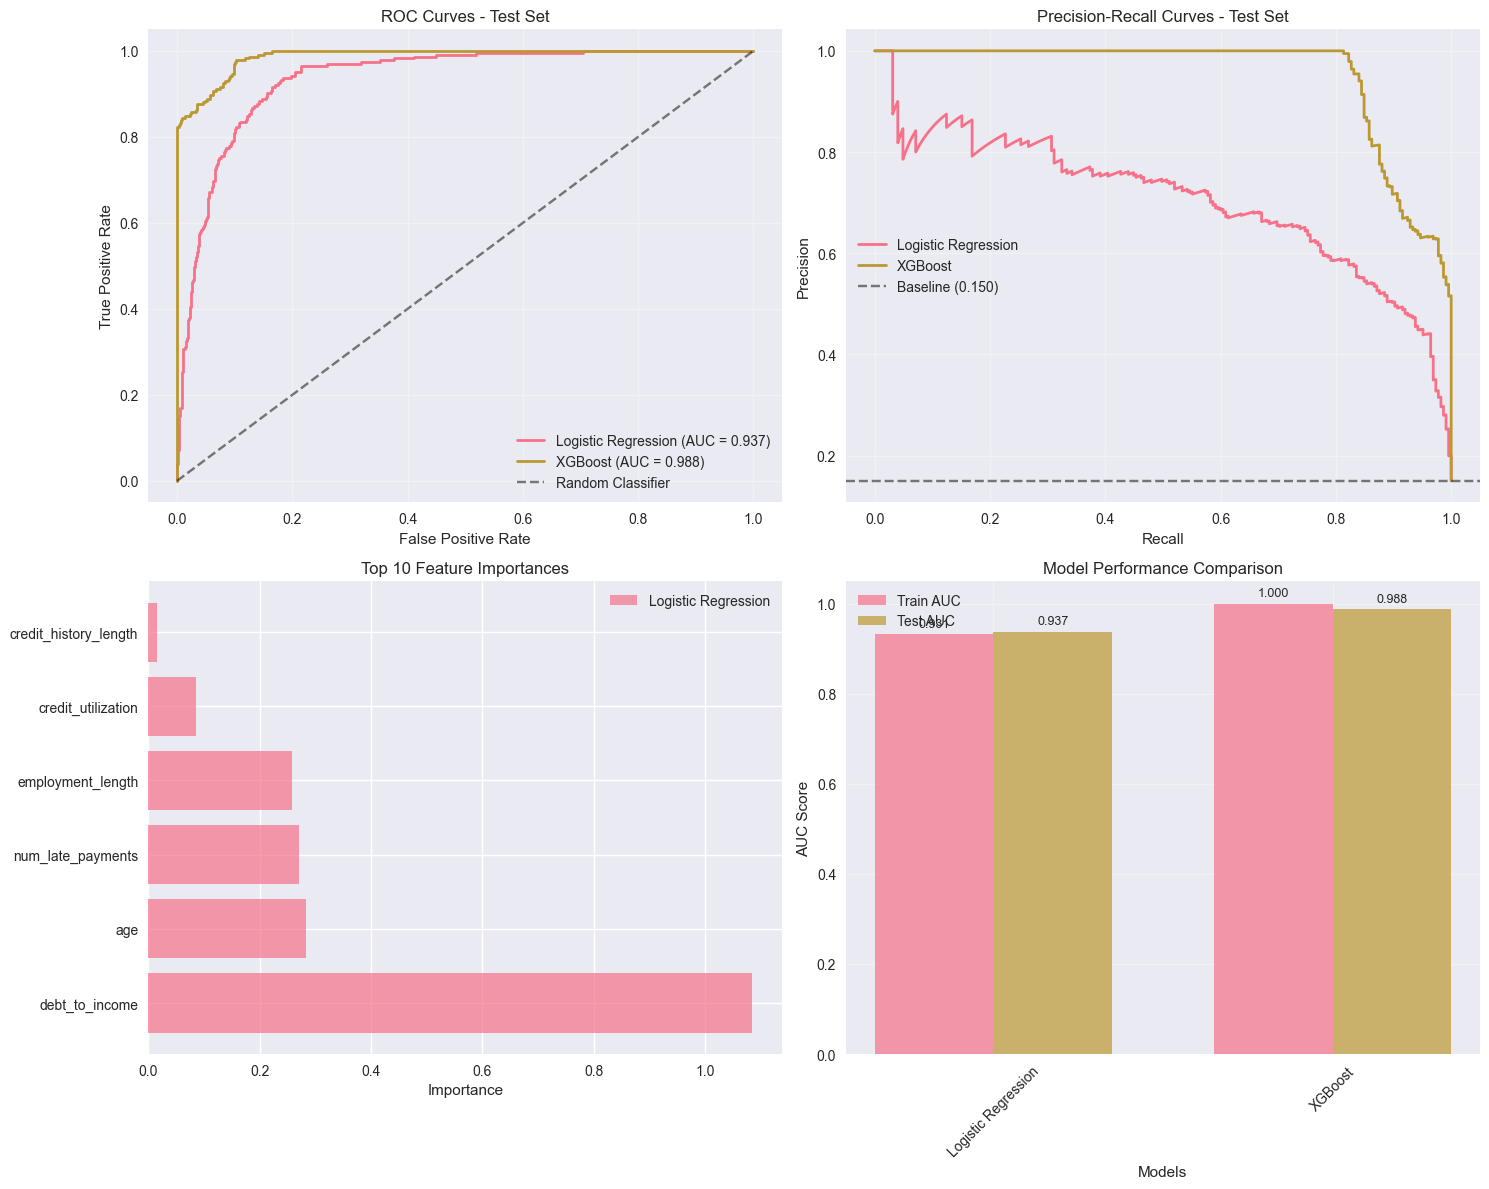


📋 DETAILED METRICS COMPARISON
shape: (2, 4)
┌─────────────────────┬──────────┬───────────┬─────────────┐
│ Model               ┆ Test_AUC ┆ Train_AUC ┆ Overfitting │
│ ---                 ┆ ---      ┆ ---       ┆ ---         │
│ str                 ┆ f64      ┆ f64       ┆ f64         │
╞═════════════════════╪══════════╪═══════════╪═════════════╡
│ Logistic Regression ┆ 0.937133 ┆ 0.93147   ┆ -0.005663   │
│ XGBoost             ┆ 0.987716 ┆ 1.0       ┆ 0.012284    │
└─────────────────────┴──────────┴───────────┴─────────────┘

🏆 BEST MODEL: XGBoost
   Test AUC: 0.9877
   Overfitting: 0.0123

🔍 ADDITIONAL METRICS ANALYSIS
Best performing model: XGBoost

📊 THRESHOLD ANALYSIS
--------------------------------------------------------------------------------
Threshold  Sensitivity  Specificity  Precision    F1-Score  
--------------------------------------------------------------------------------
0.3        0.880        0.951        0.762        0.816     
0.4        0.876        0.962    

In [15]:
def compare_models(model_results_dict, y_test, dataset_name="Test"):
    """
    Compare multiple models and create comprehensive visualizations.
    
    Parameters:
    -----------
    model_results_dict : dict
        Dictionary of model results {model_name: results}
    y_test : np.array
        True test labels
    dataset_name : str
        Name of the dataset being evaluated
    """
    if not model_results_dict:
        print("No models to compare.")
        return
    
    print(f"📊 MODEL COMPARISON - {dataset_name} Set")
    print("=" * 60)
    
    # Create comparison plots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # ROC Curves
    ax1 = axes[0, 0]
    model_metrics = {}
    
    for model_name, results in model_results_dict.items():
        if 'predictions' in results:
            y_pred_proba = results['predictions'][f'y_{dataset_name.lower()}_pred_proba']
            fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
            auc = roc_auc_score(y_test, y_pred_proba)
            
            ax1.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})', linewidth=2)
            model_metrics[model_name] = {'auc': auc, 'fpr': fpr, 'tpr': tpr}
    
    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title(f'ROC Curves - {dataset_name} Set')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Precision-Recall Curves
    ax2 = axes[0, 1]
    
    for model_name, results in model_results_dict.items():
        if 'predictions' in results:
            y_pred_proba = results['predictions'][f'y_{dataset_name.lower()}_pred_proba']
            precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
            
            ax2.plot(recall, precision, label=f'{model_name}', linewidth=2)
    
    baseline_precision = np.mean(y_test)
    ax2.axhline(y=baseline_precision, color='k', linestyle='--', alpha=0.5, 
                label=f'Baseline ({baseline_precision:.3f})')
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title(f'Precision-Recall Curves - {dataset_name} Set')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Feature Importance Comparison (if available)
    ax3 = axes[1, 0]
    
    if len(model_results_dict) == 2:
        model_names = list(model_results_dict.keys())
        
        # Get top features from both models
        if 'feature_importance' in model_results_dict[model_names[0]]:
            imp1 = model_results_dict[model_names[0]]['feature_importance'].head(10)
            features1 = imp1.select('feature').to_series().to_list()
            
            if model_names[0] == 'Logistic Regression':
                values1 = imp1.select('abs_coefficient').to_series().to_list()
            else:
                values1 = imp1.select('importance').to_series().to_list()
            
            y_pos = np.arange(len(features1))
            ax3.barh(y_pos, values1, alpha=0.7, label=model_names[0])
            ax3.set_yticks(y_pos)
            ax3.set_yticklabels(features1)
            ax3.set_xlabel('Importance')
            ax3.set_title('Top 10 Feature Importances')
            ax3.legend()
    else:
        ax3.text(0.5, 0.5, 'Feature importance\ncomparison available\nfor exactly 2 models', 
                ha='center', va='center', transform=ax3.transAxes)
        ax3.set_title('Feature Importance Comparison')
    
    # Model Metrics Summary
    ax4 = axes[1, 1]
    
    metrics_summary = []
    for model_name, results in model_results_dict.items():
        if 'metrics' in results:
            metrics_summary.append({
                'Model': model_name,
                'Test_AUC': results['metrics']['test_auc'],
                'Train_AUC': results['metrics']['train_auc'],
                'Overfitting': results['metrics']['overfitting']
            })
    
    if metrics_summary:
        summary_df = pl.DataFrame(metrics_summary)
        
        # Create bar plot for AUC comparison
        models = summary_df.select('Model').to_series().to_list()
        test_aucs = summary_df.select('Test_AUC').to_series().to_list()
        train_aucs = summary_df.select('Train_AUC').to_series().to_list()
        
        x = np.arange(len(models))
        width = 0.35
        
        ax4.bar(x - width/2, train_aucs, width, label='Train AUC', alpha=0.7)
        ax4.bar(x + width/2, test_aucs, width, label='Test AUC', alpha=0.7)
        
        ax4.set_xlabel('Models')
        ax4.set_ylabel('AUC Score')
        ax4.set_title('Model Performance Comparison')
        ax4.set_xticks(x)
        ax4.set_xticklabels(models, rotation=45)
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        
        # Add value labels on bars
        for i, (train_auc, test_auc) in enumerate(zip(train_aucs, test_aucs)):
            ax4.text(i - width/2, train_auc + 0.01, f'{train_auc:.3f}', 
                    ha='center', va='bottom', fontsize=9)
            ax4.text(i + width/2, test_auc + 0.01, f'{test_auc:.3f}', 
                    ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed comparison table
    if metrics_summary:
        print(f"\n📋 DETAILED METRICS COMPARISON")
        print(summary_df)
        
        # Determine best model
        best_model_idx = np.argmax(test_aucs)
        best_model_name = models[best_model_idx]
        print(f"\n🏆 BEST MODEL: {best_model_name}")
        print(f"   Test AUC: {test_aucs[best_model_idx]:.4f}")
        print(f"   Overfitting: {summary_df.filter(pl.col('Model') == best_model_name).select('Overfitting').to_series()[0]:.4f}")

def calculate_additional_metrics(y_true, y_pred_proba, threshold=0.5):
    """Calculate additional performance metrics."""
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    # Confusion matrix elements
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Calculate metrics
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # Recall/TPR
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0
    
    # Business metrics
    total = len(y_true)
    positive_rate = (tp + fp) / total
    capture_rate = tp / np.sum(y_true) if np.sum(y_true) > 0 else 0
    
    return {
        'threshold': threshold,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'precision': precision,
        'f1_score': f1,
        'positive_rate': positive_rate,
        'capture_rate': capture_rate,
        'confusion_matrix': {'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn}
    }

# Compare models if both are available
if LOGISTIC_REGRESSION_RESULTS is not None and XGBOOST_RESULTS is not None and MODELING_DATA is not None:
    
    model_comparison = {
        'Logistic Regression': LOGISTIC_REGRESSION_RESULTS,
        'XGBoost': XGBOOST_RESULTS
    }
    
    compare_models(model_comparison, MODELING_DATA['y_test'], "Test")
    
    # Calculate additional metrics for best model
    print(f"\n🔍 ADDITIONAL METRICS ANALYSIS")
    print("=" * 60)
    
    # Find best model based on test AUC
    lr_auc = LOGISTIC_REGRESSION_RESULTS['metrics']['test_auc']
    xgb_auc = XGBOOST_RESULTS['metrics']['test_auc']
    
    if lr_auc > xgb_auc:
        best_model_results = LOGISTIC_REGRESSION_RESULTS
        best_model_name = "Logistic Regression"
    else:
        best_model_results = XGBOOST_RESULTS
        best_model_name = "XGBoost"
    
    print(f"Best performing model: {best_model_name}")
    
    # Calculate metrics at different thresholds
    y_test_proba = best_model_results['predictions']['y_test_pred_proba']
    
    thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
    threshold_metrics = []
    
    for threshold in thresholds:
        metrics = calculate_additional_metrics(
            MODELING_DATA['y_test'], 
            y_test_proba, 
            threshold
        )
        threshold_metrics.append(metrics)
    
    # Display threshold analysis
    print(f"\n📊 THRESHOLD ANALYSIS")
    print("-" * 80)
    print(f"{'Threshold':<10} {'Sensitivity':<12} {'Specificity':<12} {'Precision':<12} {'F1-Score':<10}")
    print("-" * 80)
    
    for metrics in threshold_metrics:
        print(f"{metrics['threshold']:<10} {metrics['sensitivity']:<12.3f} "
              f"{metrics['specificity']:<12.3f} {metrics['precision']:<12.3f} "
              f"{metrics['f1_score']:<10.3f}")
    
    # Store best model for scoring
    BEST_MODEL_RESULTS = best_model_results
    BEST_MODEL_NAME = best_model_name
    
else:
    if LOGISTIC_REGRESSION_RESULTS is not None:
        print("📊 Only Logistic Regression results available")
        BEST_MODEL_RESULTS = LOGISTIC_REGRESSION_RESULTS
        BEST_MODEL_NAME = "Logistic Regression"
    elif XGBOOST_RESULTS is not None:
        print("📊 Only XGBoost results available")
        BEST_MODEL_RESULTS = XGBOOST_RESULTS
        BEST_MODEL_NAME = "XGBoost"
    else:
        print("⚠️  No trained models available for comparison.")
        BEST_MODEL_RESULTS = None
        BEST_MODEL_NAME = None

## 13. Gains Table and Performance Metrics Visualization

Generate gains tables, lift charts, and credit scoring specific performance visualizations.

📊 GAINS ANALYSIS FOR XGBoost
Gains Table:
shape: (10, 8)
┌────────┬─────────┬──────┬──────────┬──────────────┬──────────────┬──────────┬──────────┐
│ decile ┆ records ┆ bads ┆ bad_rate ┆ cum_bad_rate ┆ capture_rate ┆ lift     ┆ ks       │
│ ---    ┆ ---     ┆ ---  ┆ ---      ┆ ---          ┆ ---          ┆ ---      ┆ ---      │
│ i64    ┆ i64     ┆ i64  ┆ f64      ┆ f64          ┆ f64          ┆ f64      ┆ f64      │
╞════════╪═════════╪══════╪══════════╪══════════════╪══════════════╪══════════╪══════════╡
│ 1      ┆ 150     ┆ 150  ┆ 1.0      ┆ 1.0          ┆ 0.666667     ┆ 6.666667 ┆ 0.666667 │
│ 2      ┆ 150     ┆ 55   ┆ 0.366667 ┆ 0.683333     ┆ 0.911111     ┆ 2.444444 ┆ 0.836601 │
│ 3      ┆ 150     ┆ 19   ┆ 0.126667 ┆ 0.497778     ┆ 0.995556     ┆ 0.844444 ┆ 0.818301 │
│ 4      ┆ 150     ┆ 0    ┆ 0.0      ┆ 0.373333     ┆ 0.995556     ┆ 0.0      ┆ 0.700654 │
│ 5      ┆ 150     ┆ 0    ┆ 0.0      ┆ 0.298667     ┆ 0.995556     ┆ 0.0      ┆ 0.583007 │
│ 6      ┆ 150     ┆ 0    ┆ 0.0  

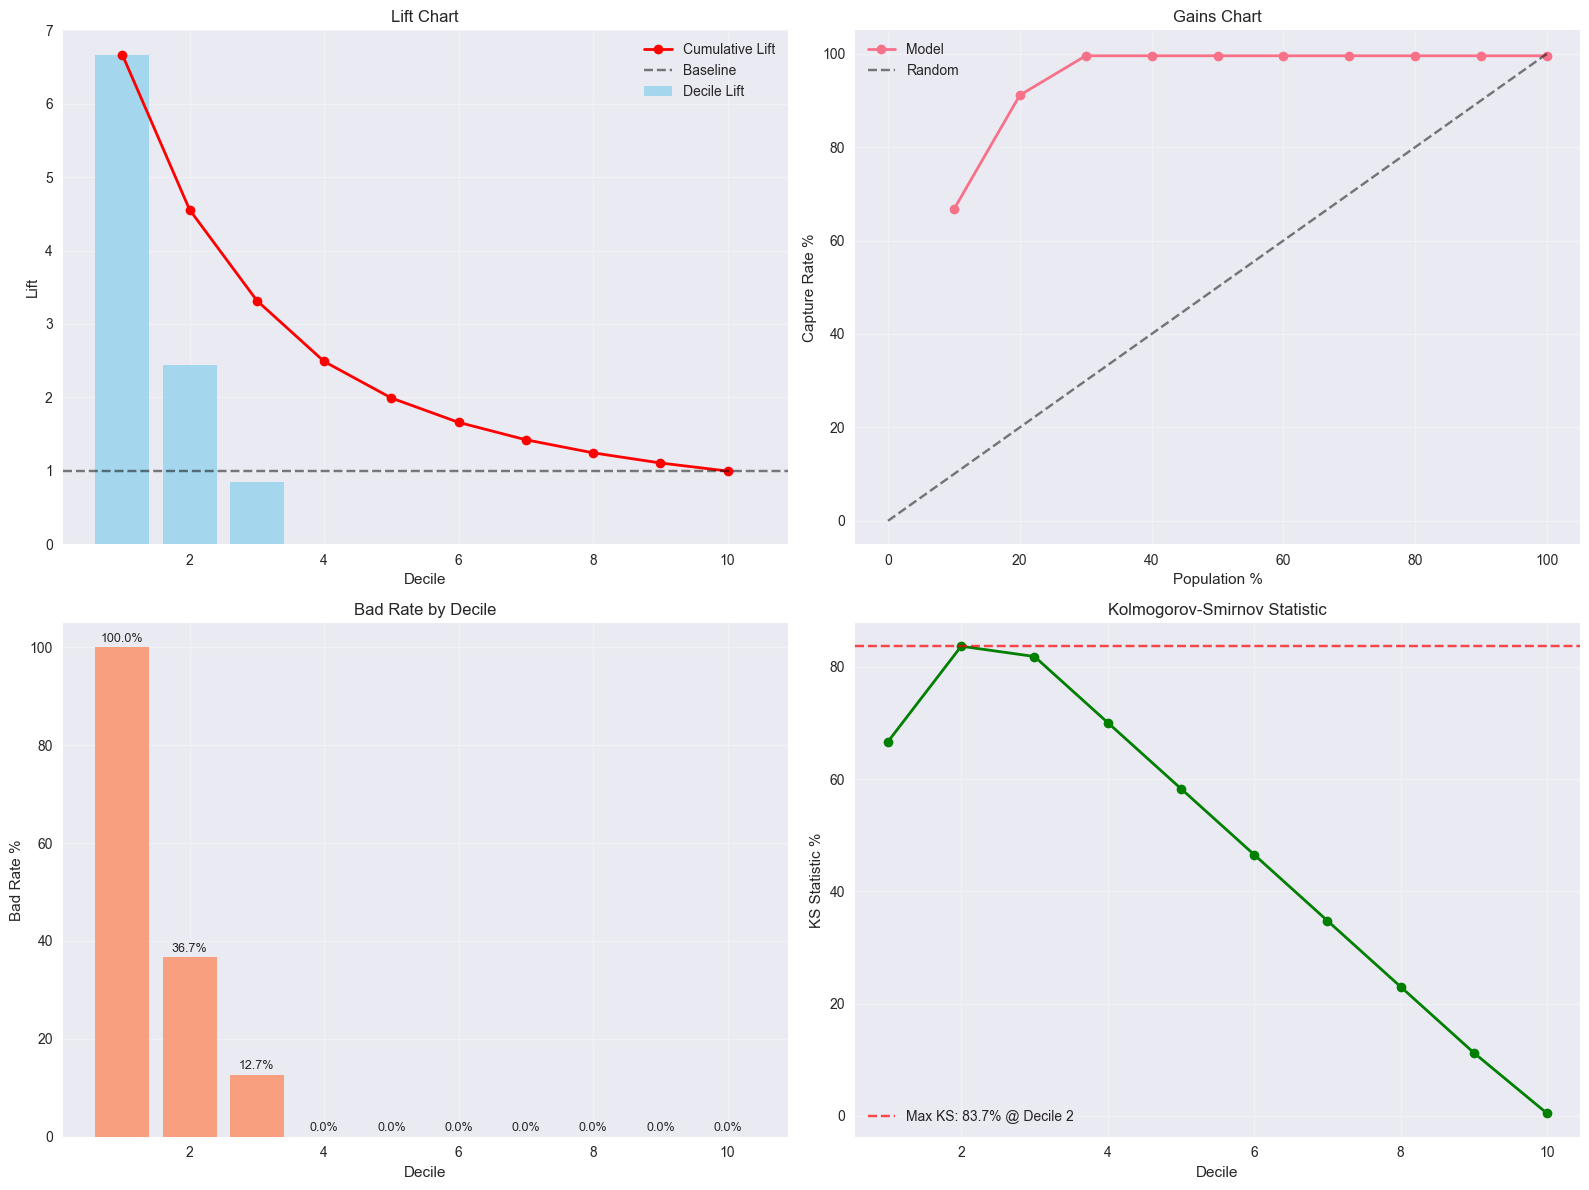

📊 KEY PERFORMANCE INSIGHTS
Maximum KS Statistic: 83.7% at Decile 2
Top Decile Lift: 6.67x
Top Decile Bad Rate: 100.0%
Top 30% Capture Rate: 99.6%

🔍 MODEL STABILITY ANALYSIS
Population Stability Index (PSI): 0.0053
Interpretation: No significant population shift


In [17]:
def create_gains_table(y_true, y_pred_proba, n_deciles=10):
    """
    Create a gains table for credit scoring analysis.
    
    Parameters:
    -----------
    y_true : np.array
        True binary labels
    y_pred_proba : np.array
        Predicted probabilities
    n_deciles : int
        Number of deciles to create
    
    Returns:
    --------
    pl.DataFrame
        Gains table with detailed metrics
    """
    
    # Create dataframe for analysis
    df_gains = pl.DataFrame({
        'actual': y_true,
        'predicted_prob': y_pred_proba
    }).sort('predicted_prob', descending=True)
    
    # Add decile ranks
    total_records = len(df_gains)
    df_gains = df_gains.with_row_count('rank')
    df_gains = df_gains.with_columns([
        (pl.col('rank') / total_records * n_deciles).ceil().cast(pl.Int32).alias('decile')
    ])
    
    # Calculate gains table metrics
    gains_data = []
    
    # Overall statistics
    total_bads = df_gains.select('actual').sum().item()
    total_goods = total_records - total_bads
    overall_bad_rate = total_bads / total_records
    
    cumulative_records = 0
    cumulative_bads = 0
    
    for decile in range(1, n_deciles + 1):
        decile_df = df_gains.filter(pl.col('decile') == decile)
        
        if decile_df.shape[0] == 0:
            continue
        
        # Decile statistics
        decile_records = decile_df.shape[0]
        decile_bads = decile_df.select('actual').sum().item()
        decile_goods = decile_records - decile_bads
        decile_bad_rate = decile_bads / decile_records if decile_records > 0 else 0
        
        # Cumulative statistics
        cumulative_records += decile_records
        cumulative_bads += decile_bads
        cumulative_bad_rate = cumulative_bads / cumulative_records if cumulative_records > 0 else 0
        
        # Performance metrics
        capture_rate = cumulative_bads / total_bads if total_bads > 0 else 0
        lift = decile_bad_rate / overall_bad_rate if overall_bad_rate > 0 else 0
        cumulative_lift = cumulative_bad_rate / overall_bad_rate if overall_bad_rate > 0 else 0
        
        # Gains and KS
        gains = capture_rate - (cumulative_records / total_records)
        
        # True Positive Rate and False Positive Rate for KS
        tpr = cumulative_bads / total_bads if total_bads > 0 else 0
        fpr = (cumulative_records - cumulative_bads) / total_goods if total_goods > 0 else 0
        ks = abs(tpr - fpr)
        # Average predicted probability in decile
        avg_pred_prob = decile_df.select('predicted_prob').mean().item()
        min_pred_prob = decile_df.select('predicted_prob').min().item()
        max_pred_prob = decile_df.select('predicted_prob').max().item()
        
        gains_data.append({
            'decile': decile,
            'records': decile_records,
            'goods': decile_goods,
            'bads': decile_bads,
            'bad_rate': decile_bad_rate,
            'cum_records': cumulative_records,
            'cum_bads': cumulative_bads,
            'cum_bad_rate': cumulative_bad_rate,
            'capture_rate': capture_rate,
            'lift': lift,
            'cum_lift': cumulative_lift,
            'gains': gains,
            'ks': ks,
            'avg_pred_prob': avg_pred_prob,
            'min_pred_prob': min_pred_prob,
            'max_pred_prob': max_pred_prob
        })
    
    gains_table = pl.DataFrame(gains_data)
    return gains_table

def visualize_gains_and_lift(gains_table):
    """Create comprehensive gains and lift visualizations."""
    
    if gains_table is None or gains_table.shape[0] == 0:
        print("No gains table data available for visualization.")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    deciles = gains_table.select('decile').to_series().to_list()
    
    # 1. Lift Chart
    lift_values = gains_table.select('lift').to_series().to_list()
    cum_lift_values = gains_table.select('cum_lift').to_series().to_list()
    
    axes[0, 0].bar(deciles, lift_values, alpha=0.7, label='Decile Lift', color='skyblue')
    axes[0, 0].plot(deciles, cum_lift_values, marker='o', color='red', 
                   linewidth=2, label='Cumulative Lift')
    axes[0, 0].axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Baseline')
    axes[0, 0].set_xlabel('Decile')
    axes[0, 0].set_ylabel('Lift')
    axes[0, 0].set_title('Lift Chart')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Gains Chart
    capture_rates = gains_table.select('capture_rate').to_series().to_list()
    population_pct = [decile * 10 for decile in deciles]
    
    axes[0, 1].plot(population_pct, [x * 100 for x in capture_rates], 
                   marker='o', linewidth=2, label='Model')
    axes[0, 1].plot([0, 100], [0, 100], 'k--', alpha=0.5, label='Random')
    axes[0, 1].set_xlabel('Population %')
    axes[0, 1].set_ylabel('Capture Rate %')
    axes[0, 1].set_title('Gains Chart')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Bad Rate by Decile
    bad_rates = gains_table.select('bad_rate').to_series().to_list()
    
    axes[1, 0].bar(deciles, [x * 100 for x in bad_rates], alpha=0.7, color='coral')
    axes[1, 0].set_xlabel('Decile')
    axes[1, 0].set_ylabel('Bad Rate %')
    axes[1, 0].set_title('Bad Rate by Decile')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Add values on bars
    for i, rate in enumerate(bad_rates):
        axes[1, 0].text(deciles[i], rate * 100 + 0.5, f'{rate:.1%}', 
                       ha='center', va='bottom', fontsize=9)
    
    # 4. KS Statistic
    ks_values = gains_table.select('ks').to_series().to_list()
    max_ks = max(ks_values)
    max_ks_decile = deciles[ks_values.index(max_ks)]
    
    axes[1, 1].plot(deciles, [x * 100 for x in ks_values], marker='o', 
                   linewidth=2, color='green')
    axes[1, 1].axhline(y=max_ks * 100, color='red', linestyle='--', alpha=0.7,
                      label=f'Max KS: {max_ks:.1%} @ Decile {max_ks_decile}')
    axes[1, 1].set_xlabel('Decile')
    axes[1, 1].set_ylabel('KS Statistic %')
    axes[1, 1].set_title('Kolmogorov-Smirnov Statistic')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print key insights
    print(f"📊 KEY PERFORMANCE INSIGHTS")
    print("=" * 50)
    print(f"Maximum KS Statistic: {max_ks:.1%} at Decile {max_ks_decile}")
    print(f"Top Decile Lift: {lift_values[0]:.2f}x")
    print(f"Top Decile Bad Rate: {bad_rates[0]:.1%}")
    print(f"Top 30% Capture Rate: {capture_rates[2]:.1%}")  # First 3 deciles

def calculate_model_stability(y_train_proba, y_test_proba, n_bins=10):
    """
    Calculate Population Stability Index (PSI) to measure model stability.
    
    Parameters:
    -----------
    y_train_proba : np.array
        Training set predicted probabilities
    y_test_proba : np.array
        Test set predicted probabilities
    n_bins : int
        Number of bins for PSI calculation
        
    Returns:
    --------
    dict
        PSI calculation results
    """
    
    # Create bins based on training data
    bin_edges = np.percentile(y_train_proba, np.linspace(0, 100, n_bins + 1))
    bin_edges[0] = 0  # Ensure first bin starts at 0
    bin_edges[-1] = 1  # Ensure last bin ends at 1
    
    # Calculate distribution for training and test sets
    train_counts, _ = np.histogram(y_train_proba, bins=bin_edges)
    test_counts, _ = np.histogram(y_test_proba, bins=bin_edges)
    
    # Convert to proportions
    train_props = train_counts / len(y_train_proba)
    test_props = test_counts / len(y_test_proba)
    
    # Calculate PSI
    psi_values = []
    total_psi = 0
    
    for i in range(len(train_props)):
        # Avoid division by zero
        if train_props[i] == 0:
            train_props[i] = 0.0001
        if test_props[i] == 0:
            test_props[i] = 0.0001
        
        psi_bin = (test_props[i] - train_props[i]) * np.log(test_props[i] / train_props[i])
        psi_values.append(psi_bin)
        total_psi += psi_bin
    
    # Interpret PSI
    if total_psi < 0.1:
        interpretation = "No significant population shift"
    elif total_psi < 0.2:
        interpretation = "Minor population shift"
    else:
        interpretation = "Major population shift - investigate"
    
    return {
        'total_psi': total_psi,
        'interpretation': interpretation,
        'bin_edges': bin_edges,
        'train_props': train_props,
        'test_props': test_props,
        'psi_by_bin': psi_values
    }

# Generate gains table and visualizations for best model
if BEST_MODEL_RESULTS is not None and MODELING_DATA is not None:
    
    print(f"📊 GAINS ANALYSIS FOR {BEST_MODEL_NAME}")
    print("=" * 60)
    
    # Create gains table
    gains_table = create_gains_table(
        MODELING_DATA['y_test'],
        BEST_MODEL_RESULTS['predictions']['y_test_pred_proba'],
        n_deciles=10
    )
    
    print("Gains Table:")
    print(gains_table.select([
        'decile', 'records', 'bads', 'bad_rate', 'cum_bad_rate', 
        'capture_rate', 'lift', 'ks'
    ]))
    
    # Create visualizations
    print(f"\n📈 GAINS AND LIFT VISUALIZATIONS")
    print("=" * 60)
    visualize_gains_and_lift(gains_table)
    
    # Model stability analysis
    print(f"\n🔍 MODEL STABILITY ANALYSIS")
    print("=" * 60)
    
    stability_results = calculate_model_stability(
        BEST_MODEL_RESULTS['predictions']['y_train_pred_proba'],
        BEST_MODEL_RESULTS['predictions']['y_test_pred_proba']
    )
    
    print(f"Population Stability Index (PSI): {stability_results['total_psi']:.4f}")
    print(f"Interpretation: {stability_results['interpretation']}")
    
    # Store gains table for PDO calculation
    GAINS_TABLE = gains_table
    
else:
    print("⚠️  No model results available for gains analysis.")
    GAINS_TABLE = None

## 14. PDO Score Creation

Implement Points Double the Odds (PDO) methodology to convert model probabilities into 3-digit credit scores.

🎯 CREATING PDO SCORECARD
📊 PDO SCORECARD CONFIGURATION
   PDO (Points to Double Odds): 20
   Base Score: 600
   Base Odds: 50:1
   Calculated Factor: 28.85
   Calculated Offset: 487.12

📊 SCORE GENERATION RESULTS
   Test set records: 1,500
   Score range: 221 - 753
   Mean score: 647
   Median score: 724

📋 SCORE DISTRIBUTION ANALYSIS


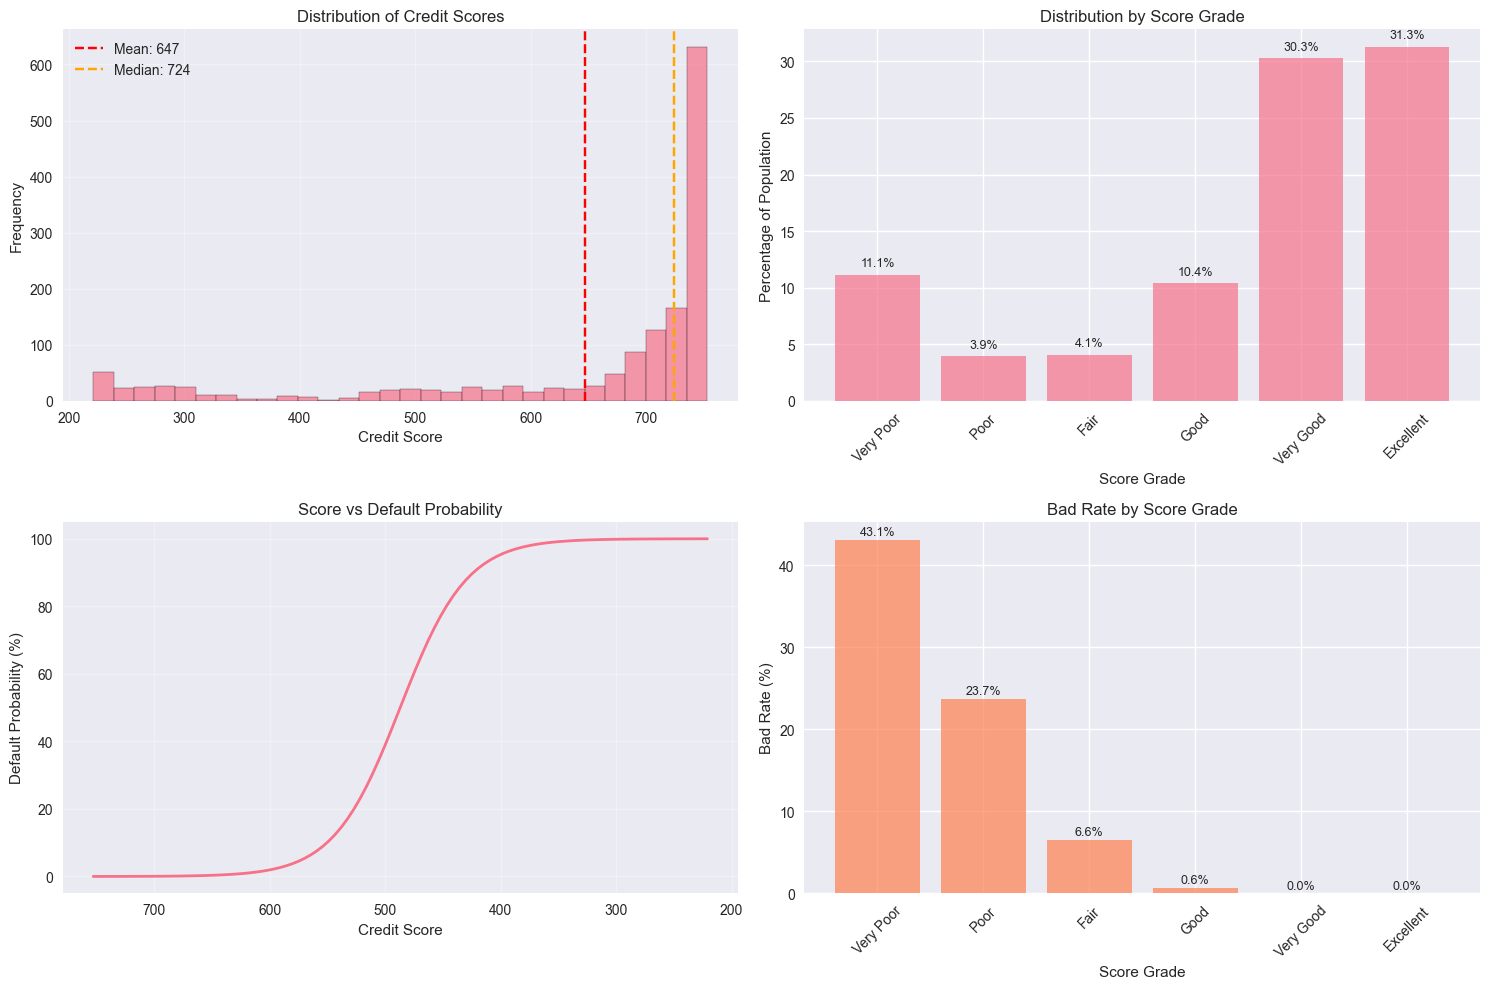

Score Distribution Table:
shape: (6, 9)
┌────────────┬───────────┬───────┬────────────┬───┬───────────┬───────────┬──────────┬─────────────┐
│ score_band ┆ grade     ┆ count ┆ percentage ┆ … ┆ min_score ┆ max_score ┆ bad_rate ┆ avg_probabi │
│ ---        ┆ ---       ┆ ---   ┆ ---        ┆   ┆ ---       ┆ ---       ┆ ---      ┆ lity        │
│ str        ┆ str       ┆ i64   ┆ f64        ┆   ┆ i64       ┆ i64       ┆ f64      ┆ ---         │
│            ┆           ┆       ┆            ┆   ┆           ┆           ┆          ┆ f64         │
╞════════════╪═══════════╪═══════╪════════════╪═══╪═══════════╪═══════════╪══════════╪═════════════╡
│ 300-549    ┆ Very Poor ┆ 167   ┆ 11.133333  ┆ … ┆ 300       ┆ 549       ┆ 0.431138 ┆ 0.60962     │
│ 550-599    ┆ Poor      ┆ 59    ┆ 3.933333   ┆ … ┆ 550       ┆ 598       ┆ 0.237288 ┆ 0.0507      │
│ 600-649    ┆ Fair      ┆ 61    ┆ 4.066667   ┆ … ┆ 600       ┆ 649       ┆ 0.065574 ┆ 0.009323    │
│ 650-699    ┆ Good      ┆ 156   ┆ 10.4       ┆ … ┆

In [18]:
class PDOScorecard:
    """
    Implementation of Points Double the Odds (PDO) scoring methodology.
    
    The PDO method converts probabilities to credit scores using the formula:
    Score = Offset + Factor * ln(odds)
    
    Where:
    - Offset and Factor are calculated based on PDO, base score, and base odds
    - PDO = Points to Double the Odds (typically 20)
    - Base Score = Score at base odds (typically 600)
    - Base Odds = Baseline odds ratio (typically 1:50 for 2% default rate)
    """
    
    def __init__(self, pdo=20, base_score=600, base_odds=50):
        """
        Initialize PDO scorecard parameters.
        
        Parameters:
        -----------
        pdo : int
            Points to Double the Odds
        base_score : int
            Score at base odds
        base_odds : float
            Base odds ratio (good:bad)
        """
        self.pdo = pdo
        self.base_score = base_score
        self.base_odds = base_odds
        
        # Calculate scaling parameters
        self.factor = pdo / np.log(2)
        self.offset = base_score - self.factor * np.log(base_odds)
        
        print(f"📊 PDO SCORECARD CONFIGURATION")
        print(f"   PDO (Points to Double Odds): {pdo}")
        print(f"   Base Score: {base_score}")
        print(f"   Base Odds: {base_odds}:1")
        print(f"   Calculated Factor: {self.factor:.2f}")
        print(f"   Calculated Offset: {self.offset:.2f}")
    
    def probability_to_score(self, probabilities):
        """
        Convert probabilities to PDO scores.
        
        Parameters:
        -----------
        probabilities : np.array
            Predicted probabilities (0-1)
        
        Returns:
        --------
        np.array
            PDO scores
        """
        # Convert probabilities to odds
        # Odds = (1 - probability) / probability (good:bad ratio)
        # Handle edge cases
        probabilities = np.clip(probabilities, 0.0001, 0.9999)
        odds = (1 - probabilities) / probabilities
        
        # Calculate scores
        scores = self.offset + self.factor * np.log(odds)
        
        # Round to integers for traditional credit scores
        scores = np.round(scores).astype(int)
        
        return scores
    
    def score_to_probability(self, scores):
        """
        Convert PDO scores back to probabilities.
        
        Parameters:
        -----------
        scores : np.array
            PDO scores
        
        Returns:
        --------
        np.array
            Probabilities
        """
        # Reverse the formula: probability = 1 / (1 + odds)
        # Where odds = exp((score - offset) / factor)
        odds = np.exp((scores - self.offset) / self.factor)
        probabilities = 1 / (1 + odds)
        
        return probabilities
    
    def create_score_distribution_table(self, scores, actual=None):
        """
        Create a score distribution table with performance metrics.
        
        Parameters:
        -----------
        scores : np.array
            PDO scores
        actual : np.array, optional
            Actual target values for performance calculation
            
        Returns:
        --------
        pl.DataFrame
            Score distribution table
        """
        # Define score bands (typical credit score ranges)
        score_bands = [
            (300, 549, 'Very Poor'),
            (550, 599, 'Poor'),
            (600, 649, 'Fair'),
            (650, 699, 'Good'),
            (700, 749, 'Very Good'),
            (750, 850, 'Excellent')
        ]
        
        distribution_data = []
        
        for min_score, max_score, grade in score_bands:
            mask = (scores >= min_score) & (scores <= max_score)
            count = np.sum(mask)
            percentage = (count / len(scores)) * 100
            
            if count > 0:
                avg_score = np.mean(scores[mask])
                min_actual = np.min(scores[mask])
                max_actual = np.max(scores[mask])
                
                # Calculate performance metrics if actual values provided
                if actual is not None:
                    band_actual = actual[mask]
                    if len(band_actual) > 0:
                        bad_rate = np.mean(band_actual)
                        avg_prob = np.mean(self.score_to_probability(scores[mask]))
                    else:
                        bad_rate = 0
                        avg_prob = 0
                else:
                    bad_rate = None
                    avg_prob = None
            else:
                avg_score = min_actual = max_actual = None
                bad_rate = avg_prob = None
            
            distribution_data.append({
                'score_band': f'{min_score}-{max_score}',
                'grade': grade,
                'count': count,
                'percentage': percentage,
                'avg_score': avg_score,
                'min_score': min_actual,
                'max_score': max_actual,
                'bad_rate': bad_rate,
                'avg_probability': avg_prob
            })
        
        return pl.DataFrame(distribution_data)
    
    def visualize_score_distribution(self, scores, actual=None):
        """Create visualizations for score distribution."""
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # 1. Score histogram
        axes[0, 0].hist(scores, bins=30, alpha=0.7, edgecolor='black')
        axes[0, 0].set_xlabel('Credit Score')
        axes[0, 0].set_ylabel('Frequency')
        axes[0, 0].set_title('Distribution of Credit Scores')
        axes[0, 0].grid(True, alpha=0.3)
        
        # Add statistics
        mean_score = np.mean(scores)
        median_score = np.median(scores)
        axes[0, 0].axvline(mean_score, color='red', linestyle='--', 
                          label=f'Mean: {mean_score:.0f}')
        axes[0, 0].axvline(median_score, color='orange', linestyle='--', 
                          label=f'Median: {median_score:.0f}')
        axes[0, 0].legend()
        
        # 2. Score bands distribution
        distribution_table = self.create_score_distribution_table(scores, actual)
        
        grades = distribution_table.select('grade').to_series().to_list()
        percentages = distribution_table.select('percentage').to_series().to_list()
        
        bars = axes[0, 1].bar(grades, percentages, alpha=0.7)
        axes[0, 1].set_xlabel('Score Grade')
        axes[0, 1].set_ylabel('Percentage of Population')
        axes[0, 1].set_title('Distribution by Score Grade')
        axes[0, 1].tick_params(axis='x', rotation=45)
        
        # Add percentage labels on bars
        for bar, pct in zip(bars, percentages):
            height = bar.get_height()
            axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                           f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
        
        # 3. Score vs Probability relationship
        unique_scores = np.linspace(scores.min(), scores.max(), 100)
        corresponding_probs = self.score_to_probability(unique_scores)
        
        axes[1, 0].plot(unique_scores, corresponding_probs * 100, linewidth=2)
        axes[1, 0].set_xlabel('Credit Score')
        axes[1, 0].set_ylabel('Default Probability (%)')
        axes[1, 0].set_title('Score vs Default Probability')
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].invert_xaxis()  # Higher scores = lower probability
        
        # 4. Performance by score band (if actual values provided)
        if actual is not None:
            bad_rates = distribution_table.select('bad_rate').to_series().to_list()
            bad_rates = [br for br in bad_rates if br is not None]
            valid_grades = [grades[i] for i, br in enumerate(distribution_table.select('bad_rate').to_series().to_list()) if br is not None]
            
            if bad_rates:
                axes[1, 1].bar(valid_grades, [br * 100 for br in bad_rates], 
                              alpha=0.7, color='coral')
                axes[1, 1].set_xlabel('Score Grade')
                axes[1, 1].set_ylabel('Bad Rate (%)')
                axes[1, 1].set_title('Bad Rate by Score Grade')
                axes[1, 1].tick_params(axis='x', rotation=45)
                
                # Add value labels
                for i, rate in enumerate(bad_rates):
                    axes[1, 1].text(i, rate * 100 + 0.2, f'{rate:.1%}', 
                                   ha='center', va='bottom', fontsize=9)
        else:
            axes[1, 1].text(0.5, 0.5, 'Bad Rate Analysis\nRequires Actual Values', 
                           ha='center', va='center', transform=axes[1, 1].transAxes)
            axes[1, 1].set_title('Bad Rate by Score Grade')
        
        plt.tight_layout()
        plt.show()
        
        return distribution_table

def validate_pdo_scorecard(scorecard, test_probabilities, test_actual):
    """
    Validate the PDO scorecard implementation.
    
    Parameters:
    -----------
    scorecard : PDOScorecard
        The scorecard object
    test_probabilities : np.array
        Test set probabilities
    test_actual : np.array
        Test set actual values
        
    Returns:
    --------
    dict
        Validation results
    """
    
    # Convert probabilities to scores
    test_scores = scorecard.probability_to_score(test_probabilities)
    
    # Convert scores back to probabilities
    reconstructed_probs = scorecard.score_to_probability(test_scores)
    
    # Calculate reconstruction error
    reconstruction_error = np.mean(np.abs(test_probabilities - reconstructed_probs))
    
    # Score range and statistics
    score_stats = {
        'min_score': int(np.min(test_scores)),
        'max_score': int(np.max(test_scores)),
        'mean_score': int(np.mean(test_scores)),
        'median_score': int(np.median(test_scores)),
        'std_score': np.std(test_scores)
    }
    
    # Rank ordering validation (higher scores should have lower probabilities)
    correlation = np.corrcoef(test_scores, test_probabilities)[0, 1]
    
    # Performance validation
    # Check if scores properly discriminate between good and bad customers
    good_scores = test_scores[test_actual == 0]
    bad_scores = test_scores[test_actual == 1]
    
    if len(good_scores) > 0 and len(bad_scores) > 0:
        good_mean_score = np.mean(good_scores)
        bad_mean_score = np.mean(bad_scores)
        discrimination = good_mean_score - bad_mean_score
    else:
        good_mean_score = bad_mean_score = discrimination = None
    
    validation_results = {
        'reconstruction_error': reconstruction_error,
        'score_probability_correlation': correlation,
        'score_statistics': score_stats,
        'good_customers_avg_score': good_mean_score,
        'bad_customers_avg_score': bad_mean_score,
        'discrimination_power': discrimination
    }
    
    return validation_results

# Create PDO Scorecard
if BEST_MODEL_RESULTS is not None and MODELING_DATA is not None:
    
    print("🎯 CREATING PDO SCORECARD")
    print("=" * 60)
    
    # Initialize scorecard with configured parameters
    pdo_scorecard = PDOScorecard(
        pdo=CONFIG['pdo'],
        base_score=CONFIG['base_score'],
        base_odds=CONFIG['base_odds']
    )
    
    # Convert test set probabilities to scores
    test_probabilities = BEST_MODEL_RESULTS['predictions']['y_test_pred_proba']
    test_scores = pdo_scorecard.probability_to_score(test_probabilities)
    
    print(f"\n📊 SCORE GENERATION RESULTS")
    print(f"   Test set records: {len(test_scores):,}")
    print(f"   Score range: {test_scores.min()} - {test_scores.max()}")
    print(f"   Mean score: {np.mean(test_scores):.0f}")
    print(f"   Median score: {np.median(test_scores):.0f}")
    
    # Create score distribution analysis
    print(f"\n📋 SCORE DISTRIBUTION ANALYSIS")
    print("=" * 60)
    
    distribution_table = pdo_scorecard.visualize_score_distribution(
        test_scores, 
        MODELING_DATA['y_test']
    )
    
    print("Score Distribution Table:")
    print(distribution_table)
    
    # Validate scorecard
    print(f"\n🔍 SCORECARD VALIDATION")
    print("=" * 60)
    
    validation_results = validate_pdo_scorecard(
        pdo_scorecard, 
        test_probabilities, 
        MODELING_DATA['y_test']
    )
    
    print(f"Reconstruction Error: {validation_results['reconstruction_error']:.6f}")
    print(f"Score-Probability Correlation: {validation_results['score_probability_correlation']:.4f}")
    print(f"Good Customers Avg Score: {validation_results['good_customers_avg_score']:.0f}")
    print(f"Bad Customers Avg Score: {validation_results['bad_customers_avg_score']:.0f}")
    print(f"Discrimination Power: {validation_results['discrimination_power']:.0f} points")
    
    # Create example scoring function
    def score_new_customer(model, scaler, scorecard, customer_features):
        """
        Score a new customer using the trained model and PDO scorecard.
        
        Parameters:
        -----------
        model : sklearn model
            Trained model
        scaler : sklearn scaler (if used)
            Feature scaler (for logistic regression)
        scorecard : PDOScorecard
            PDO scorecard object
        customer_features : np.array
            Customer feature values
            
        Returns:
        --------
        dict
            Scoring results
        """
        # Handle different model types
        if hasattr(model, 'predict_proba'):
            if scaler is not None:
                # Logistic regression with scaling
                scaled_features = scaler.transform(customer_features.reshape(1, -1))
                probability = model.predict_proba(scaled_features)[0, 1]
            else:
                # XGBoost without scaling
                probability = model.predict_proba(customer_features.reshape(1, -1))[0, 1]
        else:
            raise ValueError("Model must have predict_proba method")
        
        # Convert to score
        score = scorecard.probability_to_score(np.array([probability]))[0]
        
        # Determine grade
        if score >= 750:
            grade = "Excellent"
        elif score >= 700:
            grade = "Very Good"
        elif score >= 650:
            grade = "Good"
        elif score >= 600:
            grade = "Fair"
        elif score >= 550:
            grade = "Poor"
        else:
            grade = "Very Poor"
        
        return {
            'probability': probability,
            'score': score,
            'grade': grade
        }
    
    # Example scoring
    print(f"\n🎯 EXAMPLE CUSTOMER SCORING")
    print("=" * 60)
    
    # Score a few test customers as examples
    for i in range(min(3, len(MODELING_DATA['X_test']))):
        customer_features = MODELING_DATA['X_test'][i]
        actual_outcome = MODELING_DATA['y_test'][i]
        
        if BEST_MODEL_NAME == "Logistic Regression":
            scoring_result = score_new_customer(
                BEST_MODEL_RESULTS['model'],
                BEST_MODEL_RESULTS['scaler'],
                pdo_scorecard,
                customer_features
            )
        else:  # XGBoost
            scoring_result = score_new_customer(
                BEST_MODEL_RESULTS['model'],
                None,
                pdo_scorecard,
                customer_features
            )
        
        print(f"Customer {i+1}:")
        print(f"  Predicted Score: {scoring_result['score']}")
        print(f"  Grade: {scoring_result['grade']}")
        print(f"  Default Probability: {scoring_result['probability']:.1%}")
        print(f"  Actual Outcome: {'Default' if actual_outcome == 1 else 'Good'}")
        print()
    
    # Store final results
    PDO_SCORECARD = pdo_scorecard
    FINAL_SCORES = test_scores
    SCORE_DISTRIBUTION = distribution_table
    
    print(f"✅ PDO Scorecard creation completed successfully!")
    print(f"   Ready for production use with {BEST_MODEL_NAME} model")
    
else:
    print("⚠️  No model results available for PDO scorecard creation.")
    PDO_SCORECARD = None
    FINAL_SCORES = None
    SCORE_DISTRIBUTION = None